<div class="alert alert-info" role="alert" style="padding:20px; margin-bottom:16px;">
  <div style="text-align:center;">
    <h1 style="margin:0;">Exploratory Data Analysis</h1>
    <div style="font-size:18px; margin-top:4px;">Amazing International Airlines Inc.</div>
    <hr style="margin:12px auto; width:220px;">
    <div style="font-size:14px; color:#6c757d;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>


This Project was done by:


Student Name    -   Mehmet Karaca;
student id      -   20250344;
contact email   -   20250344@novaims.unl.pt

Student Name    -   Duarte Gomes;
student id      -   20250017;
contact email   -   20250017@novaims.unl.pt

Student Name    -   Esra Salhi
student id      -   20250537
contact email   -   20250537@novaims.unl.pt

## Table of Contents

- [Context and Metadata](#context-and-metadata)
- [1.1. Importing Libraries](#importing-libraries)
- [1.2. loading and Reading Data](#loading-and-reading-data)
- [1.3. Brief Preliminary Analysis](#brief-preliminary-analysis)

- [2.1. Missing Values](#missing-values)
- [2.2. Validity check](#validity-check)
  - [2.2.1 Categorical Features of customers](#categorical-features-of-customers)
  - [2.2.2 Numerical Features of customers](#numerical-features-of-customers)
  - [2.2.3 Numerical Features of flights](#numerical-features-of-flights)
  - [2.2.4 Datetime Features of Flights](#datetime-features-of-flights)
- [2.3 Logic Checks](#logic-checks)
  - [2.3.1 Logic Check - DistanceKM and NumFlights](#logic-distancekm-vs-numflights)
  - [2.3.2 Logic Check - NumFlights and FlightCompanions](#logic-numflights-vs-flightcompanions)

- [3.1 Active Customers](#active-customers)
- [3.2 Tenure Days](#tenure-days)
- [3.3 Flight Metrics per Customer](#flight-metrics-per-customer)
  - [3.3.1 Flights Aggregated Metrics](#flights-aggregated-metrics)
  - [3.3.2 Merge Flights Aggregated with Customers](#merge-flights-aggregated-with-customers)
- [3.4 Season to flights dataset](#season-to-flights-dataset)
- [3.5 Logic Checks of the new columns](#logic-checks-new-columns)
  - [3.5.1 Logic Check - Customer Lifetime Value and Zero Flights](#logic-clv-and-zero-flights)
  - [3.5.2 Logic Check - AverageDistanceKM > 13,000 KM](#logic-avg-distancekm-over-13000-km)
  - [3.5.3 Logic Check - Negative Customer Tenure Days](#logic-negative-tenure-days)

- [4.1 Customer EDA](#customer-eda)
  - [4.1.1 Customer EDA - Categorical Features](#customer-eda-categorical-features)
  - [4.1.2 Customer EDA - Numerical Features](#customer-eda-numerical-features)
  - [4.1.3 Customer EDA - Multivariate Analysis](#customer-eda-multivariate-analysis)
- [4.2 Flights EDA](#flights-eda)
  - [4.2.1 Flights EDA - Numerical Features](#flights-eda-numerical-features)
- [4.3 Zero income customers EDA](#zero-income-customers-eda)

- [5.1 Value based segmentation](#value-based-segmentation)
- [5.1.1 Income-Based Segmentation](#income-based-segmentation)
  - [Observations on Income Group Distribution](#observations-income-group-distribution)
  - [Feature Distributions by Income Group](#feature-distributions-by-income-group)
  - [Business-Ready Visualization Variant](#business-ready-visualization-variant)
  - [Education vs. Income: Initial Observation](#education-vs-income-initial-observation)
- [5.1.1 CLV-Based Segmentation](#clv-based-segmentation)
  - [Interpreting CLV-Grouped Distributions](#interpreting-clv-grouped-distributions)
  - [Loyalty Status by CLV Group — Key Observations](#loyalty-status-by-clv-group-key-observations)
- [5.1.3 Linking Income and CLV](#linking-income-and-clv)

- [5.2 Behavioral Segmentation](#behavioral-segmentation)
  - [Seasonal Analysis: Flights by Year and Month](#seasonal-analysis-flights-by-year-and-month)
  - [Business-Ready Visualization Variant](#business-ready-visualization-variant-2)
  - [Seasonal Aggregation](#seasonal-aggregation)
  - [Companion Type by Season](#companion-type-by-season)
  - [Companion Type by Loyalty Status — Grouped View](#companion-type-by-loyalty-status-grouped-view)
  - [Companion Type by Loyalty Status — Stacked View](#companion-type-by-loyalty-status-stacked-view)

- [5.3 Demographic Segmentation](#demographic-segmentation)
  - [5.3.1 Province Analysis](#province-analysis)
  - [5.3.2 City Analysis](#city-analysis)
  - [Top 20 Cities by Average Income](#top-20-cities-by-average-income)
  - [Geographic Distribution of Customers](#geographic-distribution-of-customers)


# 1 Introduction <a id="introduction"></a>


## Context and Metadata <a id="context-and-metadata"></a>


CustomerDB 

`Unnamed` - Column without a name or meaning <br>
`Loyalty#` - Loyalty program identifier for the customer <br>
`First Name` - Customer's first name <br>
`Last Name` - Customer's last name <br>
`Customer Name` - Full name of the customer <br>
`Country` - Country where the customer resides <br>
`Province or State` - Province or state of the customer's residence <br>
`City` - City of the customer's residence <br>
`Latitude` - Latitude coordinate of the customer's location <br>
`Longitude` - Longitude coordinate of the customer's location <br>
`Postal code` - Postal code of the customer's address <br>
`Gender` - Gender of the customer <br>
`Education` - Education level of the customer <br>
`Location Code` - Code representing the customer's location <br>
`Income` - Income level of the customer <br>
`Marital Status` - Marital status of the customer <br>
`LoyaltyStatus` - Status of the customer's loyalty program <br>
`EnrollmentDateOpening` - Date when the customer enrolled in the loyalty program <br>
`CancellationDate` - Date when the customer canceled their loyalty program <br>
`Customer Lifetime Value` - Total value of the customer over their lifetime <br>
`EnrollmentType` - Type of enrollment in the loyalty program <br>


FlightsDB

`Loyalty#` - Loyalty program identifier for the customer <br>
`Year` - Year of the flight activity <br>
`Month` - Month of the flight activity <br>
`YearMonthDate` - Date representing the year and month of the flight activity <br>
`NumFlights` - Number of flights taken by the customer <br>
`NumFlightsWithCompanions` - Number of flights taken with companions <br>
`DistanceKM` - Total distance traveled in kilometers <br>
`PointsAccumulated` - Points accumulated by the customer <br>
`PointsRedeemed` - Points redeemed by the customer <br>
`DollarCostPointsRedeemed` - Dollar cost of the points redeemed <br>


## 1.1. Importing Libraries <a class="anchor" id="importing-libraries"></a>

In [2]:
# --- Standard Imports
import os
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib
import math
import matplotlib as mpl
from cycler import cycler
import geopandas as gpd
from matplotlib.lines import Line2D



In [3]:
# Plot style configuration (unified look)
# Keeps logic intact; only global appearance defaults are set.

# Accessible, consistent palette
_palette = sns.color_palette("Set1", 10)
_palette_hex = _palette.as_hex()

# Seaborn / Matplotlib defaults
sns.set_theme(style="whitegrid", context="notebook", palette=_palette)
mpl.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.titleweight': 'semibold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.grid': True,
    'grid.color': '#EAEAEA',
    'grid.linestyle': '-',
    'grid.alpha': 0.6,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.borderpad': 0.4,
    'legend.loc': 'best',
    'lines.linewidth': 2.0,
    'axes.prop_cycle': cycler('color', _palette_hex),
})


def make_palette_map(categories, palette_name="Set1", n_colors=None, as_hex=False):
    """
    Simple: returns (palette_map, palette_list).
    - categories: iterable (keeps first-seen order, coerces to str)
    - palette_name: seaborn palette name
    - n_colors: optional override (defaults to max(len(categories), 3))
    - as_hex: if True, return palette_map with hex strings
    """
    cats = [str(c) for c in dict.fromkeys(categories)]          # unique keep-order
    n_colors = n_colors or max(len(cats), 3)
    palette = sns.color_palette(palette_name, n_colors)
    palette_map = {cat: palette[i % len(palette)] for i, cat in enumerate(cats)}
    if as_hex:
        return {k: matplotlib.colors.to_hex(v) for k, v in palette_map.items()}, palette
    return palette_map, palette



# Plotly defaults (to align with seaborn/matplotlib)
px.defaults.template = 'plotly_white'
px.defaults.color_discrete_sequence = _palette_hex
px.defaults.color_continuous_scale = 'Cividis'
px.defaults.width = 900
px.defaults.height = 500


## 1.2. loading and Reading Data <a class="anchor" id="loading-and-reading-data"></a>

In [4]:
# directory with raw CSV files
data_dir = Path("../data/raw")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['DM_AIAI_CustomerDB.csv', 'DM_AIAI_Metadata.csv', 'DM_AIAI_FlightsDB.csv']


In [5]:
# specify the files we want to load

customers_file = data_dir / "DM_AIAI_CustomerDB.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16921, 21)
Flights shape: (608436, 10)


## 1.3. Brief Preliminary Analysis <a class="anchor" id="brief-preliminary-analysis"></a>

In [6]:
customers.columns

Index(['Unnamed: 0', 'Loyalty#', 'First Name', 'Last Name', 'Customer Name',
       'Country', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Postal code', 'Gender', 'Education', 'Location Code', 'Income',
       'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening',
       'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType'],
      dtype='object')

In [7]:
customers.info

<bound method DataFrame.info of        Unnamed: 0  Loyalty# First Name    Last Name        Customer Name  \
0               0    480934    Cecilia  Householder  Cecilia Householder   
1               1    549612      Dayle        Menez          Dayle Menez   
2               2    429460     Necole       Hannon        Necole Hannon   
3               3    608370      Queen        Hagee          Queen Hagee   
4               4    530508     Claire      Latting       Claire Latting   
...           ...       ...        ...          ...                  ...   
16916          15    100012      Ethan     Thompson       Ethan Thompson   
16917          16    100013      Layla        Young          Layla Young   
16918          17    100014     Amelia      Bennett       Amelia Bennett   
16919          18    100015   Benjamin       Wilson      Benjamin Wilson   
16920          19    100016       Emma       Martin          Emma Martin   

      Country Province or State          City   Latitud

In [8]:
customers.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,16921.0,8440.023639,4884.775439,0.000000,4210.000000,8440.000000,12670.000000,16900.000000
Loyalty#,16921.0,550197.393771,259251.503597,100011.000000,326823.000000,550896.000000,772438.000000,999999.000000
Latitude,16921.0,47.174500,3.307971,42.984924,44.231171,46.087818,49.282730,60.721188
Longitude,16921.0,-91.814768,22.242429,-135.056840,-120.237660,-79.383186,-74.596184,-52.712578
Income,16901.0,37758.038400,30368.992499,0.000000,0.000000,34161.000000,62396.000000,99981.000000
Customer Lifetime Value,16901.0,7990.460188,6863.173093,1898.010000,3979.720000,5780.180000,8945.690000,83325.380000


In [9]:
customers.describe(include='object').T

,count,unique,top,freq
First Name,16921,4941,Deon,13
Last Name,16921,15404,Salberg,4
Customer Name,16921,16921,Cecilia Householder,1
Country,16921,1,Canada,16921
Province or State,16921,11,Ontario,5468
City,16921,29,Toronto,3390
Postal code,16921,75,V6E 3D9,917
Gender,16921,2,female,8497
Education,16921,5,Bachelor,10586
Location Code,16921,3,Suburban,5716


In [10]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed'],
      dtype='object')

In [11]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [12]:
flights.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty#,608436.0,550037.873084,258935.180575,100018.0,326961.00,550834.000,772194.0000,999986.0
Year,608436.0,2020.000000,0.816497,2019.0,2019.00,2020.000,2021.0000,2021.0
Month,608436.0,6.500000,3.452055,1.0,3.75,6.500,9.2500,12.0
NumFlights,608436.0,3.908107,5.057889,0.0,0.00,0.000,7.2000,21.0
NumFlightsWithCompanions,608436.0,0.983944,2.003785,0.0,0.00,0.000,0.9000,11.0
DistanceKM,608436.0,7939.341419,10260.421873,0.0,0.00,856.400,15338.1750,42040.0
PointsAccumulated,608436.0,793.777781,1025.918521,0.0,0.00,85.275,1533.7125,4204.0
PointsRedeemed,608436.0,235.251678,983.233374,0.0,0.00,0.000,0.0000,7496.0
DollarCostPointsRedeemed,608436.0,2.324835,9.725168,0.0,0.00,0.000,0.0000,74.0


In [13]:
flights.describe(include='object').T

,count,unique,top,freq
YearMonthDate,608436,36,12/1/2021,16901


Remove the column "Unnamed: 0" because it is not needed and has no context in the data.

In [ ]:
if "Unnamed: 0" in customers.columns:
	customers.drop(columns=["Unnamed: 0"])

# 2. Missing Values and Data Validity Checks  <a class="anchor" id="data-validity-checks"></a>

Some text to describe what we are doing here. Explanation of this section. We only check smissing values , because in the first deliverable. we are only allowed to notice them and do little cleaning .but we need to notice them .

In [15]:
# Converting the datatype of categorical features from object to category

flights['YearMonthDate'] = pd.to_datetime(flights['YearMonthDate'], format='%m/%d/%Y')


# Convert NumFlights and NumFlightsWithCompanions to integer type (they are float by default)
flights["NumFlights"] = flights["NumFlights"].astype(int)
flights["NumFlightsWithCompanions"] = flights["NumFlightsWithCompanions"].astype(int)

In [16]:
# Check the datatype of YearMonthDate column
flights['YearMonthDate'].dtype

dtype('<M8[ns]')

## 2.1. Missing Values <a class="anchor" id="missing-values"></a>

Some text to describe what we are doing here.

In [17]:
# Check for missing values
print("Missing values in CustomerDB:")
display(customers.isna().sum())

print("\nMissing values in FlightsDB:")
display(flights.isna().sum())


Missing values in CustomerDB:


Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14611
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64


Missing values in FlightsDB:


Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

In [18]:
missing_ratio = customers.isna().mean().sort_values(ascending=False)
print((missing_ratio * 100).round(2))

CancellationDate           86.35
Customer Lifetime Value     0.12
Income                      0.12
Loyalty#                    0.00
First Name                  0.00
EnrollmentDateOpening       0.00
LoyaltyStatus               0.00
Marital Status              0.00
Location Code               0.00
Education                   0.00
Gender                      0.00
Postal code                 0.00
Longitude                   0.00
Latitude                    0.00
City                        0.00
Province or State           0.00
Country                     0.00
Customer Name               0.00
Last Name                   0.00
EnrollmentType              0.00
dtype: float64


The flights dataset is clean. The customers dataset has missing values in the columns "CancellationDate", "Customer Lifetime Value" and "Income". We start with analyzing the CancellationDate column. We expect that, these missing values correspond to customers who have not cancelled their subscription. We will check this assumption by looking at some entries with missing CancellationDate values.

In [19]:
# select first 10 rows where CancellationDate is NaN
active_customers = customers[customers["CancellationDate"].isna()].head(10)
active_customers

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
5,193662,Leatrice,Hanlin,Leatrice Hanlin,Canada,Yukon,Whitehorse,60.721188,-135.056840,Y2K 6R0,male,Bachelor,Rural,26262.0,Married,Star,5/7/2015,NaN,3844.57,Standard
6,927943,Hue,Sellner,Hue Sellner,Canada,Ontario,Toronto,43.653225,-79.383186,P5S 6R4,female,College,Urban,0.0,Single,Star,6/9/2017,NaN,3857.95,Standard
7,188893,Nakia,Cash,Nakia Cash,Canada,Ontario,Trenton,44.101128,-77.576309,K8V 4B2,male,Bachelor,Suburban,93272.0,Married,Star,12/8/2019,NaN,3861.49,Standard
8,852392,Arlene,Conterras,Arlene Conterras,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 2W2,female,Bachelor,Suburban,93272.0,Married,Star,5/30/2018,NaN,3861.49,Standard
9,866307,Dustin,Recine,Dustin Recine,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,male,Bachelor,Suburban,93272.0,Married,Star,10/14/2019,NaN,3861.49,Standard
10,932823,Jeremy,Dickason,Jeremy Dickason,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,female,Bachelor,Suburban,47199.0,Married,Star,3/17/2018,NaN,3863.31,Standard


The Entries seem to look fine. The expectation seems to be correct. We will add a new column in the Data Engineering section to indicate whether a customer is active or not based on the CancellationDate column.

Next we check the missing values in the "Customer Lifetime Value" and "Income" columns. 

In [20]:
# rows where Income is missing
missing_income = customers[customers["Income"].isna()]
print("Rows with missing Income:", missing_income.shape[0])
display(missing_income.head(5))

Rows with missing Income: 20


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16901,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,R4H 2Y2,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,N6B 1N3,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,P8F 5C8,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,B6P 6D0,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,X3W 5N2,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard


In [21]:
# rows where Customer Lifetime Value is missing
missing_clv = customers[customers["Customer Lifetime Value"].isna()]
print("Rows with missing Customer Lifetime Value:", missing_clv.shape[0])
display(missing_clv.head(5))

Rows with missing Customer Lifetime Value: 20


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16901,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,R4H 2Y2,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,N6B 1N3,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,P8F 5C8,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,B6P 6D0,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,X3W 5N2,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard


In [22]:
# Check if the missing values in Income and Customer Lifetime Value overlap
missing_income_indices = set(missing_income.index)
missing_clv_indices = set(missing_clv.index)
overlapping_indices = missing_income_indices.intersection(missing_clv_indices)

print("Rows with missing values in both Income and Customer Lifetime Value:", len(overlapping_indices))

Rows with missing values in both Income and Customer Lifetime Value: 20


The missing values in Income and Customer Lifetime Value do overlap fully. This means that all rows with missing Income also have missing Customer Lifetime Value. This could indicate a correlation between the two columns, or it could be due to data collection issues. Only 20 rows are affected, which is a small fraction of the total dataset. Deleting these rows might be a reasonable approach for the second part of the project. But for now we will keep them as is.

## 2.2. Validity check <a class="anchor" id="validity-check"></a>

We check all the columns for validity of the values. 

### 2.2.1 Categorical Features of customers <a class="anchor" id="categorical-features"></a>

In [23]:
# List all categorical columns in customers
cat_columns_customers = customers.select_dtypes(include=['object']).columns.tolist()
cat_columns_customers

['First Name',
 'Last Name',
 'Customer Name',
 'Country',
 'Province or State',
 'City',
 'Postal code',
 'Gender',
 'Education',
 'Location Code',
 'Marital Status',
 'LoyaltyStatus',
 'EnrollmentDateOpening',
 'CancellationDate',
 'EnrollmentType']

In [24]:
# Check the categorical columns for unexpected values
for col in ["Gender","Country", "Education", "Marital Status","LoyaltyStatus", "Province or State", "City", "EnrollmentType"]:
    if col in customers.columns:
        print(f"\n{col} categories:")
        print(customers[col].value_counts(dropna=False))


Gender categories:
Gender
female    8497
male      8424
Name: count, dtype: int64

Country categories:
Country
Canada    16921
Name: count, dtype: int64

Education categories:
Education
Bachelor                10586
College                  4283
High School or Below      792
Doctor                    742
Master                    518
Name: count, dtype: int64

Marital Status categories:
Marital Status
Married     9842
Single      4539
Divorced    2540
Name: count, dtype: int64

LoyaltyStatus categories:
LoyaltyStatus
Star      7761
Nova      5722
Aurora    3438
Name: count, dtype: int64

Province or State categories:
Province or State
Ontario                 5468
British Columbia        4416
Quebec                  3311
Alberta                 1008
Manitoba                 676
New Brunswick            652
Nova Scotia              541
Saskatchewan             412
Newfoundland             258
Yukon                    112
Prince Edward Island      67
Name: count, dtype: int64

City categ

In [25]:
# Check for postal codes
print("Unique postal codes:", customers["Postal code"].nunique())
print(customers["Postal code"].value_counts().head(10))

#Check if Postal code has entries with more or less than 7 characters
long_postal_codes = customers[customers["Postal code"].astype(str).str.len() > 7]
print("Postal codes with more than 7 characters:", long_postal_codes.shape[0])
short_postal_codes = customers[customers["Postal code"].astype(str).str.len() < 7]
print("Postal codes with less than 7 characters:", short_postal_codes.shape[0])


Unique postal codes: 75
Postal code
V6E 3D9    917
V5R 1W3    699
V6T 1Y8    586
V6E 3Z3    538
M2M 7K8    538
P1J 8T7    508
H2T 9K8    503
K8V 4B2    490
G1B 3L5    481
H2T 2J6    449
Name: count, dtype: int64
Postal codes with more than 7 characters: 0
Postal codes with less than 7 characters: 0


Check of the unique values in categorical columns to see if they make sense.

- Gender: Only male and female --> valid
- Country: Only Canada --> valid
- Education: Only valid education levels --> valid
- Marital Status: Only valid marital statuses --> valid
- LoyaltyStatus: Only valid loyalty statuses --> valid
- Province or State: Only valid provinces or states in Canada --> valid
- City: Only valid cities in Canada --> valid
- EnrollmentType: Only valid enrollment types --> valid

### 2.2.2 Numerical Features of customers <a class="anchor" id="numerical-features-customers"></a>

In [26]:
# Min and Max Values of each column of customers db
numeric_cols = customers.select_dtypes(include=["number"]).columns

min_max = customers[numeric_cols].agg(["min", "max"]).T
min_max.transpose()


,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value
min,100011.0,42.984924,-135.056840,0.0,1898.01
max,999999.0,60.721188,-52.712578,99981.0,83325.38


- Loyalty#: Is the unique identifier for each customer. Check if unique
- Lattitude and Longitude make sense because it is only data from Canada (Longitutde: -52 to -141, Latitude: 41 to 83)
- Income has no negative values, but needs to be checked for outliers
- Customer Lifetime Value has no negative values, but needs to be checked for outliers
- IsActive makes sense because it is only 0 and 1


Next we check for unique loyalty# 

In [27]:
# Check uniqueness of Loyalty in customers
n_rows = customers.shape[0]
n_unique_ids = customers["Loyalty#"].nunique()

print("Rows in CustomerDB:", n_rows)
print("Unique Loyalty IDs:", n_unique_ids)

if n_rows == n_unique_ids:
    print("Loyalty is unique per row.")
else:
    print ("There are", n_rows - n_unique_ids - 1, "duplicated Loyalty values.")


Rows in CustomerDB: 16921
Unique Loyalty IDs: 16757
There are 163 duplicated Loyalty values.


- There are some duplicated Loyalty values in the customers dataset. We have to check if these are really duplicates or if there are different customers with the same loyalty id. If they are duplicates, we have to delete them.

In [28]:
# List of the inconsistent Loyalty IDs in customers dataset
duplicates_by_name = customers[customers.duplicated(subset=["Loyalty#"], keep=False)].sort_values(by=["Loyalty#"])
duplicates_by_name[['Loyalty#', 'First Name', 'Last Name']]

,Loyalty#,First Name,Last Name
1646,101902,Hans,Schlottmann
2668,101902,Yi,Nesti
15988,106001,Maudie,Hyland
700,106001,Ivette,Peifer
13053,106509,Stacy,Schwebke
...,...,...,...
5038,989528,Sharri,Boughman
9890,990512,Magda,Sopher
14478,990512,Ione,Snowden
6981,992168,Frederick,Samaha


- That means that different customers have the same loyalty id. This is a problem because we cannot identify the customers uniquely and can not map their flights correctly. We check how many entries in flights correspond to these inconsistent loyalty ids.
  

In [29]:
# Count the number of entries in flights corresponding to the inconsistent loyalty ids in total
inconsistent_loyalty_ids = duplicates_by_name['Loyalty#'].unique()
flights_inconsistent = flights[flights['Loyalty#'].isin(inconsistent_loyalty_ids)]
flights_inconsistent_count = flights_inconsistent['Loyalty#'].value_counts()
flights_inconsistent_count.sum()
print("Number of flight entries with inconsistent loyalty IDs:", flights_inconsistent_count.sum())

# Percentage of flights affected by inconsistent loyalty ids
total_flights = flights.shape[0]
affected_percentage = (flights_inconsistent_count.sum() / total_flights) * 100
print(f"Percentage of flights affected by inconsistent loyalty IDs: {affected_percentage:.2f}%")

Number of flight entries with inconsistent loyalty IDs: 11772
Percentage of flights affected by inconsistent loyalty IDs: 1.93%


- One Major problem of these duplicated loyalty ids is, that we cannot link the customers to their flights. There is no reasonable way to differentiate between the two customers with the same loyalty id. So that the even changing the loyalty id of one customer would not help, because we still do not know which flights belong to which customer. We would create a new customer with a new loyalty id, but this customer would have no flights linked to him. So we would loose all the information about the flights of these customers and the other customer would have all the flights linked to him. This would distort the data and make it unusable for analysis.
  
- So for this reason we have to delete all customers with duplicated loyalty ids and all their flights. This is the only way to ensure that the remaining data is valid and can be used for analysis.

- We may lose some customers, but there is no other way to ensure the validity of the data. The percentage of affected customers is 1.93%, which is relatively low compared to the total number of customers, so the impact on the analysis should be minimal.

In [30]:
# Clean the customers and flights datasets by removing entries with duplicated Loyalty IDs
loyalty_ids_to_remove = duplicates_by_name['Loyalty#'].unique()
customers = customers[~customers['Loyalty#'].isin(loyalty_ids_to_remove)]
flights = flights[~flights['Loyalty#'].isin(loyalty_ids_to_remove)]
print("Cleaned Customers shape:", customers.shape)
print("Cleaned Flights shape:", flights.shape)

Cleaned Customers shape: (16594, 20)
Cleaned Flights shape: (596664, 10)


### 2.2.3 Numerical Features of flights <a class="anchor" id="numerical-features-flights"></a>

In [31]:
# Min and Max Values of each column of flights db
numeric_cols = flights.select_dtypes(include=["number"]).columns

min_max = flights[numeric_cols].agg(["min", "max"]).T
min_max.transpose()

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
min,100018.0,2019.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
max,999986.0,2021.0,12.0,21.0,11.0,42040.0,4204.0,7496.0,74.0


Explanation of the validity check:

- Year is between 2019 and 2021 --> makes sense
- Month is between 1 and 12 --> makes sense
- Day is between 1 and 31 --> makes sense
- NumFlights is between 0 and 21 --> makes sense 
- NumFlightsWithCompanions is between 0 and 11 --> makes sense
- DistanceKM is between 0 and 42040 --> makes sense
- PointsAccumulated is between 0 and 42040 --> makes sense
- PointsRedeemed is between 0 and 7496 --> makes sense
- DollarCostPointsRedeemed is between 0 and 74 --> makes sense

Validity check of YearMonthDate column:

### 2.2.4 Datetime Features of Flights <a class="anchor" id="datetime-features-flights"></a>

In [32]:
# Print all the unique values of YearMonthDate column sorted by date and their freuquency
flights['YearMonthDate'].value_counts().sort_index()

YearMonthDate
2019-01-01    16574
2019-02-01    16574
2019-03-01    16574
2019-04-01    16574
2019-05-01    16574
2019-06-01    16574
2019-07-01    16574
2019-08-01    16574
2019-09-01    16574
2019-10-01    16574
2019-11-01    16574
2019-12-01    16574
2020-01-01    16574
2020-02-01    16574
2020-03-01    16574
2020-04-01    16574
2020-05-01    16574
2020-06-01    16574
2020-07-01    16574
2020-08-01    16574
2020-09-01    16574
2020-10-01    16574
2020-11-01    16574
2020-12-01    16574
2021-01-01    16574
2021-02-01    16574
2021-03-01    16574
2021-04-01    16574
2021-05-01    16574
2021-06-01    16574
2021-07-01    16574
2021-08-01    16574
2021-09-01    16574
2021-10-01    16574
2021-11-01    16574
2021-12-01    16574
Name: count, dtype: int64

Since the Dataset is from 2019 to 2021, the dates should be between 01/01/2019 and 12/31/2021. The unique values of the column confirm this.

## 2.3 Logic Checks <a class="anchor" id="logic-checks"></a>


In this Section we perform logic checks on the data to ensure that the values in the columns make sense in relation to each other. We check for inconsistencies and anomalies that could indicate errors in the data.

### 2.3.1 Logic Check - DistanceKM and NumFlights <a class="anchor" id="distancekm-and-numflights"></a>


We want to check if there are any entries where NumFlights is 0 but DistanceKM is greater than 0. This would be a logical inconsistency, as it would imply that the customer traveled a distance without taking any flights.

In [33]:
# Check flights for DistanceKM and NumFlights. If NumFlights is 0, DistanceKM should also be 0 and vice versa.
# Check first how many entries have NumFlights = 0 but DistanceKM > 0
inconsistent_distance = flights[(flights["NumFlights"] == 0) & (flights["DistanceKM"] > 0)]
print("Entries with NumFlights = 0 but DistanceKM > 0:", inconsistent_distance.shape[0])
display(inconsistent_distance.head(3))

# Check first how many entries have DistanceKM = 0 but NumFlights > 0
inconsistent_numflights = flights[(flights["DistanceKM"] == 0) & (flights["NumFlights"] > 0)]
print("Entries with DistanceKM = 0 but NumFlights > 0:", inconsistent_numflights.shape[0])
display(inconsistent_numflights.head(3))

Entries with NumFlights = 0 but DistanceKM > 0: 11575


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
19,261109,2021,12,2021-12-01,0,0,13736.0,1373.0,0.0,0.0
93,817609,2021,12,2021-12-01,0,0,23775.0,2377.0,0.0,0.0
96,192600,2021,12,2021-12-01,0,0,5119.0,511.0,0.0,0.0


Entries with DistanceKM = 0 but NumFlights > 0: 0


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed


### 2.3.2 Logic Check - NumFlights and FlightCompanions <a class="anchor" id="numflights-vs-companions"></a>


Customers who have companions on flights should have at least one flight. And the number of flights with companions should not exceed the total number of flights. We want to check if there are any entries where NumFlightsWithCompanions is greater than 0 but NumFlights is 0. Furthermore we check if there are any entries where NumFlightsWithCompanions is greater than NumFlights. If we check for the second Condition, then this would include the first condition This would be a logical inconsistency, as it would imply that the customer has companions on flights without taking any flights themselves. 

In [34]:
# Check for entries where NumFlightsWithCompanions > NumFlights
inconsistent_companions = flights[(flights["NumFlightsWithCompanions"] > flights["NumFlights"])]
print("Entries with NumFlightsWithCompanions > NumFlights:", inconsistent_companions.shape[0])
display(inconsistent_companions.head(3))


Entries with NumFlightsWithCompanions > NumFlights: 0


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed


We have found some inconsistent entries. We notice them here. We will try to fix them with imputation in the second part of the project. For now we just identify them. We will do some additional logic checks after feature engineering in the next section.

# 3. Feature Engineering  <a class="anchor" id="feature-engineering"></a>

In this section, we will perform feature engineering to enhance our dataset for better analysis. This includes adding new features based on existing data.

## 3.1 Active Customers <a class="anchor" id="active-customers"></a>

We create a new column "is_active" in the customers dataframe to indicate whether a customer is active or not based on the CancellationDate column. If the CancellationDate is missing (NaT), we assume the customer is still active and set is_active to 1. Otherwise, we set it to 0. We look at the distribution of the newly created column to see how many active and inactive customers we have.

In [35]:
customers = customers.copy()   # <-- crucial to avoid SettingWithCopyWarning

# New column "IsActive": 1 if CancellationDate is NaN, else 0
customers["IsActive"] = customers["CancellationDate"].isna().astype(int)
# percentage distribution
customers["IsActive"].value_counts(normalize=True).round(3) * 100

IsActive
1    86.3
0    13.7
Name: proportion, dtype: float64

## 3.2 Tenure Days  <a class="anchor" id="tenure-days"></a>

Tenure Days is calculated by the difference between EnrollmentDate and CancellationDate. If the CancellationDate is missing, we assume the customer is still active and use the last date in the dataset (31/12/2021) for the calculation.

In [36]:
customers = customers.copy()   # <-- crucial to avoid SettingWithCopyWarning

today = pd.Timestamp('2021-12-31').normalize()

# Safe conversions
customers['EnrollmentDateOpening'] = pd.to_datetime(customers['EnrollmentDateOpening'], errors='coerce')
customers['CancellationDate']      = pd.to_datetime(customers['CancellationDate'], errors='coerce')

# EndDate: CancellationDate or today
customers['EndDate'] = customers['CancellationDate'].fillna(today)

# Tenure in days
customers['CustomerTenureDays'] = (customers['EndDate'] - customers['EnrollmentDateOpening']).dt.days

# Drop temp column (avoid inplace on possible views)
customers = customers.drop(columns=['EndDate'])

# Head of the updated customers dataframe with the columns related to tenure
customers[['EnrollmentDateOpening', 'CancellationDate', 'CustomerTenureDays']].head()


,EnrollmentDateOpening,CancellationDate,CustomerTenureDays
0,2019-02-15,NaT,1050
1,2019-03-09,NaT,1028
2,2017-07-14,2021-01-08,1274
3,2016-02-17,NaT,2144
4,2017-10-25,NaT,1528


## 3.3 Flight Metrics per Customer  <a class="anchor" id="flight-metrics-per-customer"></a>


- We will add some flight metrics grouped by customer into the customers dataframe. First we calculate them in a new dataframe and then we merge them into the customers dataframe.

### 3.3.1 Flights Aggregated Metrics  <a class="anchor" id="flights-aggregated-metrics"></a>



In [37]:
# Basic flight metrics per customer
flight_aggs = flights.groupby('Loyalty#').agg(
    # Aggregated Values
    total_flights=('NumFlights', 'sum'),
    total_flights_with_companions=('NumFlightsWithCompanions', 'sum'), 
    total_distance=('DistanceKM', 'sum'),
    total_points_accumulated=('PointsAccumulated', 'sum'),
    total_points_redeemed=('PointsRedeemed', 'sum'),
    total_cost_redeemed=('DollarCostPointsRedeemed', 'sum'),
    average_distance_per_flight=('DistanceKM', lambda x: round(x.sum() / x.count(), 2) if x.count() > 0 else 0)
).reset_index()

print("Flight aggregations summary:")

# Add derived metrics
flight_aggs['points_redemption_ratio'] = (
    flight_aggs['total_points_redeemed'] / 
    flight_aggs['total_points_accumulated'].replace(0, np.nan)
).fillna(0)

flight_aggs['companion_flight_ratio'] = (
    flight_aggs['total_flights_with_companions'] / 
    flight_aggs['total_flights']
).fillna(0)

display(flight_aggs.head())


Flight aggregations summary:


,Loyalty#,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio
0,100018,225,45,530230.0,53014.30,20562.8,201.9,14728.61,0.387873,0.200000
1,100102,245,55,339114.6,33903.96,18760.6,186.2,9419.85,0.553345,0.224490
2,100140,211,51,432030.8,43192.58,4896.0,48.0,12000.86,0.113353,0.241706
3,100214,108,17,364601.7,36453.77,12908.6,127.3,10127.83,0.354109,0.157407
4,100272,181,50,429630.5,42953.25,10891.4,107.0,11934.18,0.253564,0.276243


### 3.3.2 Merge Flights Aggregated with Customers  <a class="anchor" id="merge-flights-aggregated-with-customers"></a>



In [38]:
# Add the aggregated data from flights to the customer data
customers = customers.merge(flight_aggs, on='Loyalty#', how='left')

# Show the first 5 rows of the updated customers dataframe
display(customers.head())

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,...,1050,184.0,53.0,507054.9,50699.39,13517.9,134.6,14084.86,0.266628,0.288043
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,...,1028,275.0,30.0,426827.4,42672.54,22457.8,221.4,11856.32,0.526282,0.109091
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,...,1274,116.0,37.0,238376.1,23832.41,5479.6,53.2,6621.56,0.229922,0.318966
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,...,2144,191.0,55.0,386029.3,38595.63,16331.5,162.2,10723.04,0.423144,0.287958
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,...,1528,167.0,59.0,369242.6,36916.56,0.0,0.0,10256.74,0.000000,0.353293


## 3.4 Season to flights dataset <a class="anchor" id="flight-metrics-per-customer"></a>


In this Section we add the Column "Season" to the flights dataset based on the Month column. We define the seasons as follows:
- Winter: December, January, February
- Spring: March, April, May
- Summer: June, July, August
- Autumn: September, October, November


We will use this in our Behavioral Segmentation analysis later.

In [39]:
# Add Column "Season" to flights dataset based on the Month column
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return np.nan
    
flights['Month'] = flights['YearMonthDate'].dt.month
flights['Season'] = flights['Month'].apply(month_to_season) 
flights[['YearMonthDate', 'Month', 'Season']].head()

# Show the first 5 rows of the updated flights dataframe
display(flights.head())

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,Season
0,413052,2021,12,2021-12-01,2,2,9384.0,938.0,0.0,0.0,Winter
1,464105,2021,12,2021-12-01,0,0,0.0,0.0,0.0,0.0,Winter
2,681785,2021,12,2021-12-01,10,3,14745.0,1474.0,0.0,0.0,Winter
3,185013,2021,12,2021-12-01,16,4,26311.0,2631.0,3213.0,32.0,Winter
4,216596,2021,12,2021-12-01,9,0,19275.0,1927.0,0.0,0.0,Winter


## 3.5 Logic Checks of the new columns <a class="anchor" id="logic-checks-new-columns"></a>


After Feature Engineering, we perform logic checks on the newly created columns to ensure their validity. We already did that in Section 2.3, but we will repeat the checks here to confirm that the new features are consistent with the existing data.

### 3.5.1 Logic Check - Customer Lifetime Value and Zero Flights <a class="anchor" id="clv-zero-flights"></a>



We should check if there are any entries where Customer Lifetime Value is greater than 0 but NumFlights is 0. This would be a logical inconsistency, as it would imply that the customer has a lifetime value without taking any flights. So far we dont have a lot of information, how the Customer Lifetime Value is calculated. But it is reasonable to assume, that a customer who has not taken any flights should not have any lifetime value.

In [40]:
# Check for entries where Customer Lifetime Value > 0 but NumFlights = 0
inconsistent_clv = customers[(customers["Customer Lifetime Value"] > 0) & (customers["total_flights"] == 0)]
print("Entries with Customer Lifetime Value > 0 but NumFlights = 0:", inconsistent_clv.shape[0])
display(inconsistent_clv.head(3))

Entries with Customer Lifetime Value > 0 but NumFlights = 0: 1473


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio
30,201574,Trudy,Roscoe,Trudy Roscoe,Canada,Ontario,Ottawa,45.421532,-75.697189,K1F 2R2,...,244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38,834891,Wendell,Besley,Wendell Besley,Canada,British Columbia,Vancouver,49.282730,-123.120740,V5R 1W3,...,41,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66,329382,Ngoc,Dubuisson,Ngoc Dubuisson,Canada,Quebec,Montreal,45.501690,-73.567253,H2T 9K8,...,2318,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 3.5.2 Logic Check - AverageDistanceKM > 13,000 KM <a class="anchor" id="avg-distancekm-over-13000km"></a>

We want to check if there are any entries where a single flight is greater than 13,000 KM. DistanceKM is accumulated, but the average distance per flight should not exceed this value. The maximum distance between any two points in Canada is approximately 13,000 KM. If there are entries with AverageDistanceKM greater than this value, it would indicate a potential data error.

In [41]:
# Maximum possible distance for a single flight (approx. Vancouver → Singapore)
max_km_per_flight = 13000  

# Check for entries where average_distance_per_flight > 13,000 KM
inconsistent_distance = customers[customers["average_distance_per_flight"] > max_km_per_flight]
print("Entries with average_distance_per_flight > 13,000 KM:", inconsistent_distance.shape[0])
display(inconsistent_distance.head(3))

Entries with average_distance_per_flight > 13,000 KM: 1773


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,...,1050,184.0,53.0,507054.9,50699.39,13517.9,134.6,14084.86,0.266628,0.288043
5,927943,Hue,Sellner,Hue Sellner,Canada,Ontario,Toronto,43.653225,-79.383186,P5S 6R4,...,1666,192.0,32.0,519316.7,51924.87,21597.7,214.4,14425.46,0.415941,0.166667
12,988178,Andre,Cotugno,Andre Cotugno,Canada,Quebec,Montreal,45.501690,-73.567253,H4G 3T4,...,1905,309.0,86.0,557976.5,55788.05,14951.1,147.4,15499.35,0.267998,0.278317


### 3.5.3 Logic Check - Negative Customer Tenure Days <a class="anchor" id="negative-tenure-days"></a>

We want to check if there are entries, where the Customer Tenure Days is negative. This would indicate a data error, as the CancellationDate should always be after the EnrollmentDate.

In [42]:
# Check for entries where the Customer Tenure Days is negative
inconsistent_tenure = customers[customers["CustomerTenureDays"] < 0]
print("Entries with negative Customer Tenure Days:", inconsistent_tenure.shape[0])
display(inconsistent_tenure.head(3))

Entries with negative Customer Tenure Days: 199


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio
71,357549,Elisha,Furna,Elisha Furna,Canada,British Columbia,Whistler,50.116322,-122.957360,V6T 1Y8,...,-854,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.000000
76,265297,Ebonie,Radde,Ebonie Radde,Canada,Manitoba,Winnipeg,49.895138,-97.138374,R2C 0M5,...,-853,38.0,3.0,46838.0,4683.0,0.0,0.0,1301.06,0.000000,0.078947
172,845613,Jerald,Shiring,Jerald Shiring,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,...,-853,12.0,4.0,31562.0,3155.0,5754.0,57.0,876.72,1.823772,0.333333


# 4. Exploratory Data Analysis (EDA)  <a class="anchor" id="eda"></a>

We now will analyze the two dataset. We will split the notebook into 4.1 for customers and 4.2 for flights.

## 4.1 Customer EDA  <a class="anchor" id="Customers-EDA"></a>


We split the Customer EDA into categorical and numerical features for better analysis.

- Integer and Float - Histogram, Box Plot, Histogram related with the target variable.
- Categories - Histogram

### 4.1.1 Customer EDA - Categorical Features  <a class="anchor" id="Customers-EDA-Categorical"></a>


In [43]:
# Filter for only categorical features
cat_columns = customers.select_dtypes(include=['object', 'category']).columns.tolist()
customers_cat = customers[cat_columns]

# Remove First Name, Last Name and Customer Name from the list --> they are not useful for EDA
customers_cat = customers_cat.drop(columns=['First Name', 'Last Name', 'Customer Name'], errors='ignore')


/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_83968/2221819766.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, order=order, ax=ax, palette='Set1')
/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_83968/2221819766.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, order=order, ax=ax, palette='Set1')
/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_83968/2221819766.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, order=order, ax=ax, palette=

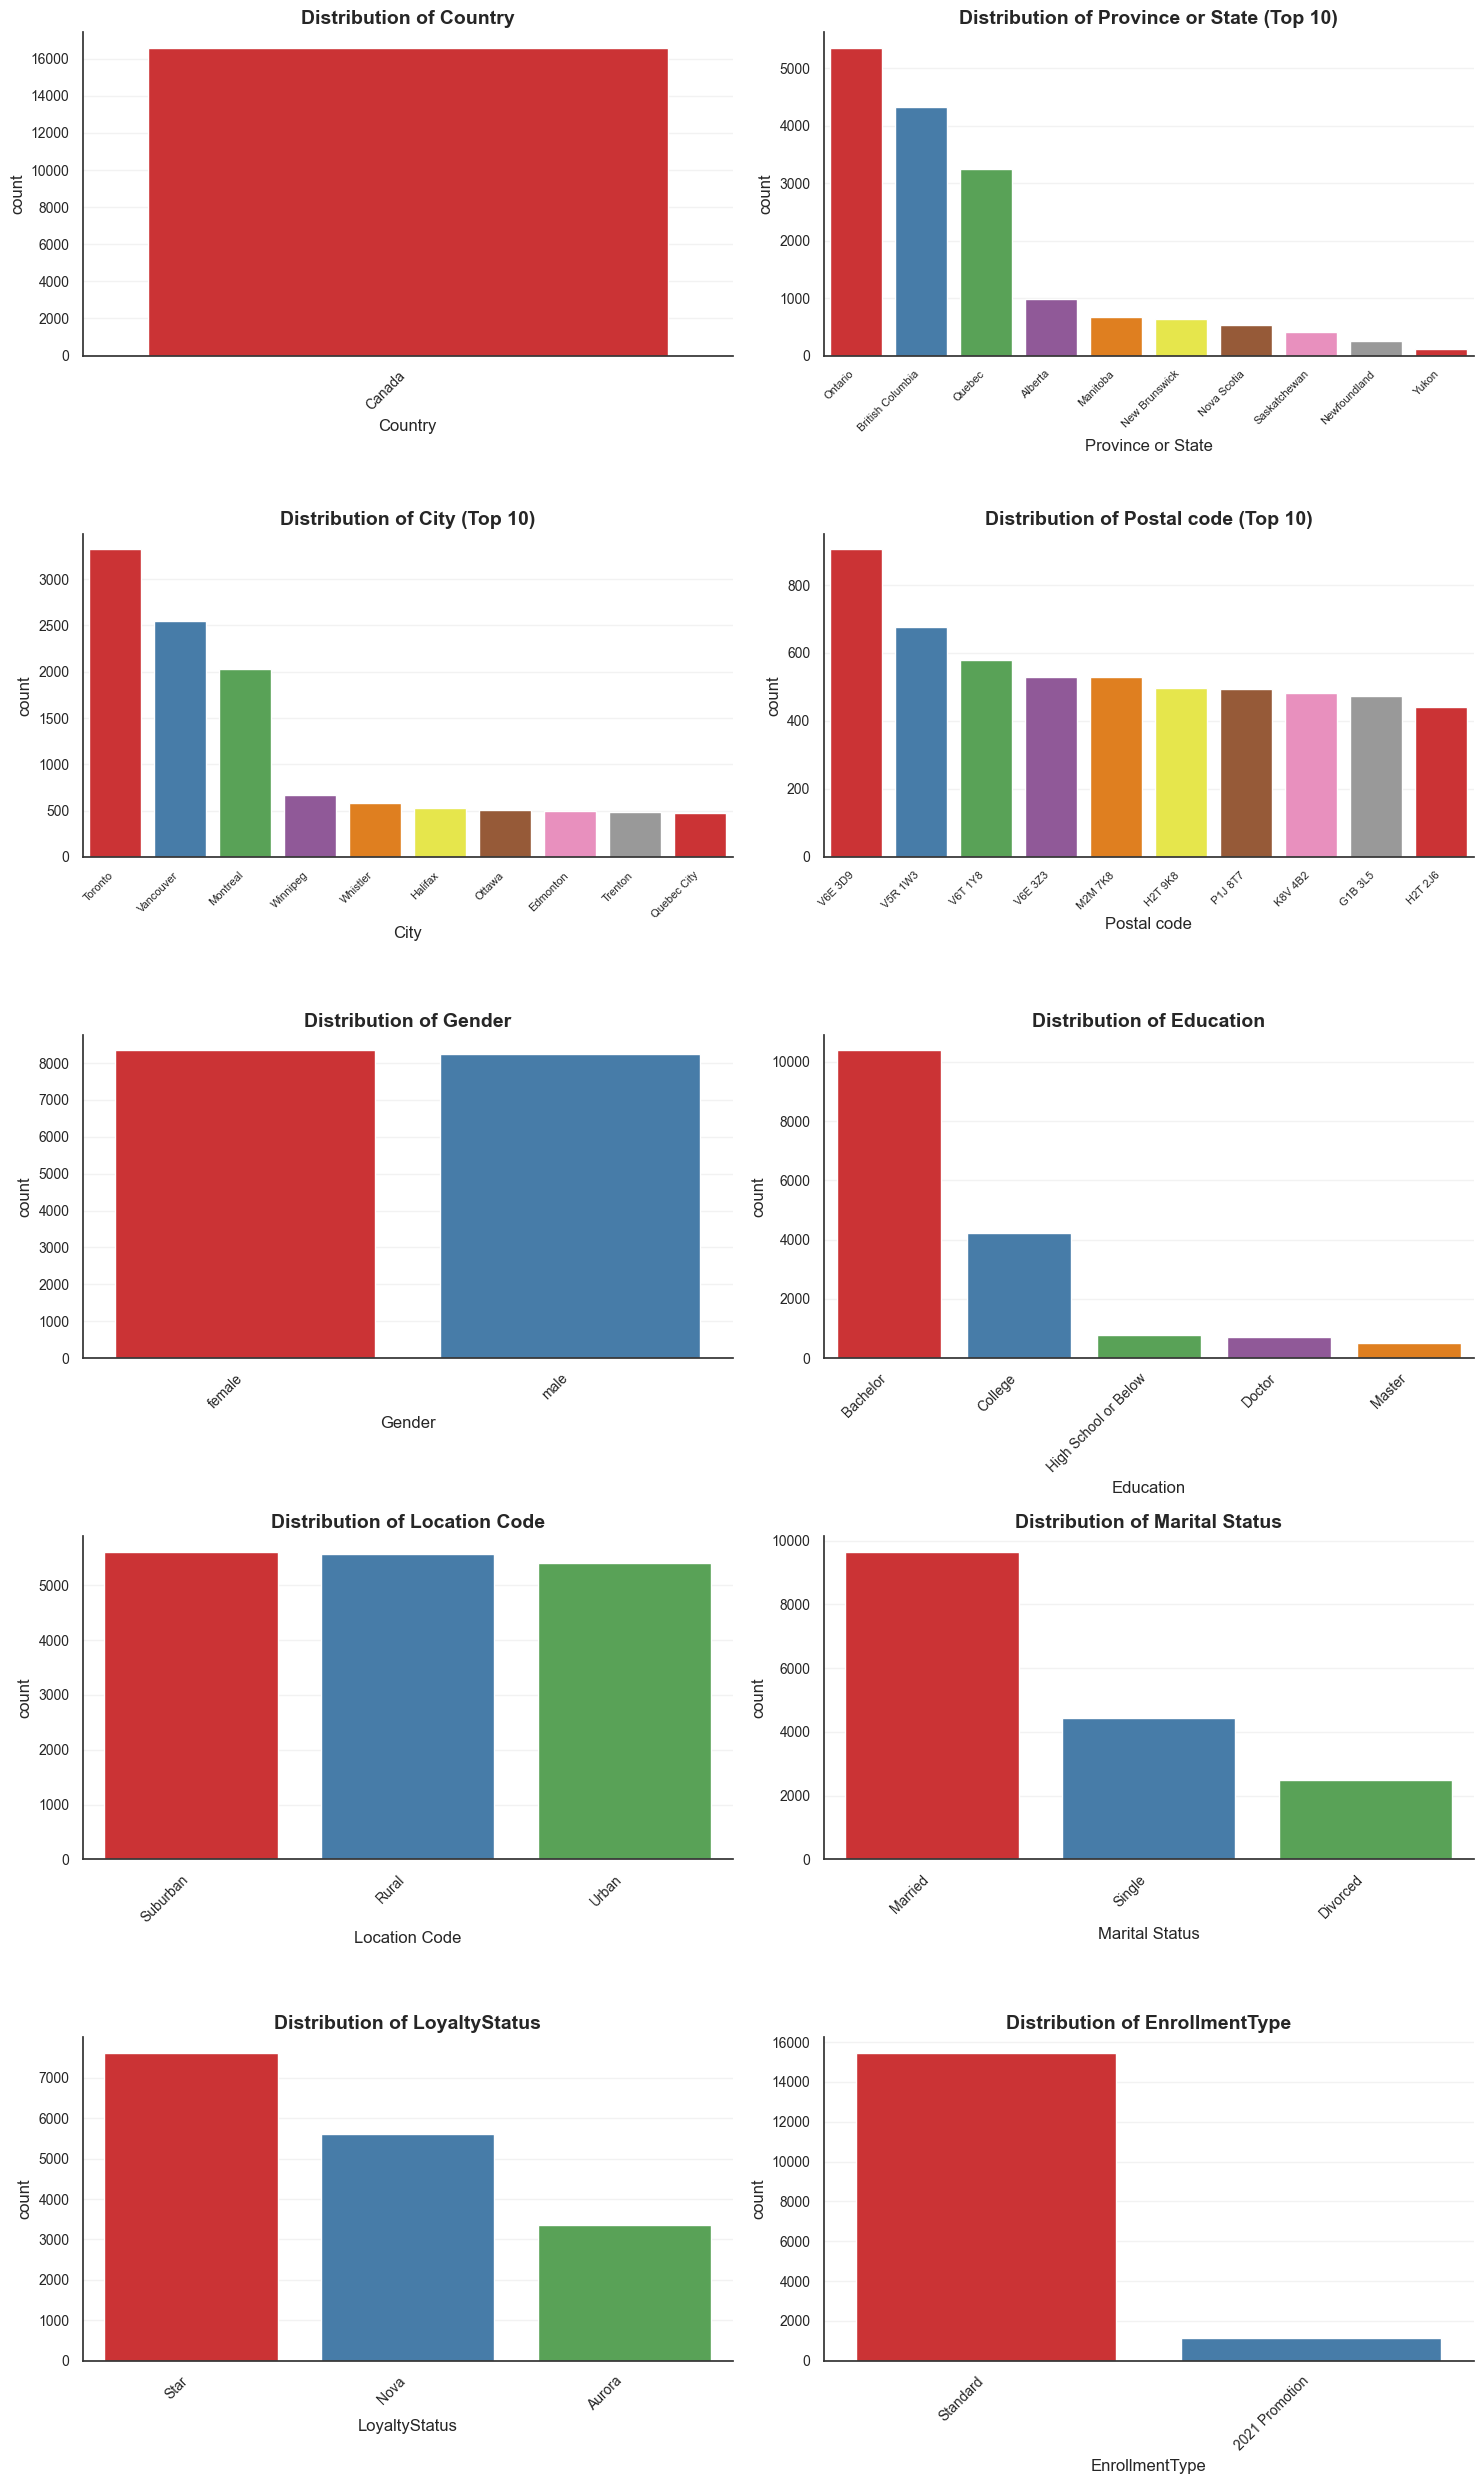

In [44]:
# Grid Layout for Categorical Features
n_cols = 2
n_rows = math.ceil(len(customers_cat.columns) / n_cols)



fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

for i, col in enumerate(customers_cat.columns):
    ax = axes[i]
    value_counts = customers_cat[col].value_counts(dropna=False)

    # Limit number of categories for readability
    max_categories = 10
    if len(value_counts) > max_categories:
        top_cats = value_counts.head(max_categories)
        data = customers_cat[customers_cat[col].isin(top_cats.index)]
        order = top_cats.index
        ax.set_title(f'Distribution of {col} (Top {max_categories})')
    else:
        data = customers_cat
        order = value_counts.index
        ax.set_title(f'Distribution of {col}')

    sns.countplot(data=data, x=col, order=order, ax=ax, palette='Set1')

    # Rotate and shrink if necessary
    label_count = len(order)
    label_size = 10 if label_count <= 6 else 8 if label_count <= 10 else 6
    ax.tick_params(axis='x', labelrotation=45, labelsize=label_size)

    # Right-align for readability
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

# Hide empty axes
for j in range(len(customers_cat.columns), len(axes)):
    fig.delaxes(axes[j])

sns.despine(fig)
plt.tight_layout()
plt.show()


### 4.1.2 Customer EDA - Numerical Features  <a class="anchor" id="Customers-EDA-Numerical"></a>


In [45]:
# Filter for only numerical features
num_columns = customers.select_dtypes(include=np.number).columns.tolist()
customers_num = customers[num_columns]

# Remove Loyalty#, Latitude, Longitude from the list --> they are not useful for EDA
customers_num = customers_num.drop(columns=['Loyalty#', 'Latitude', 'Longitude'], errors='ignore')


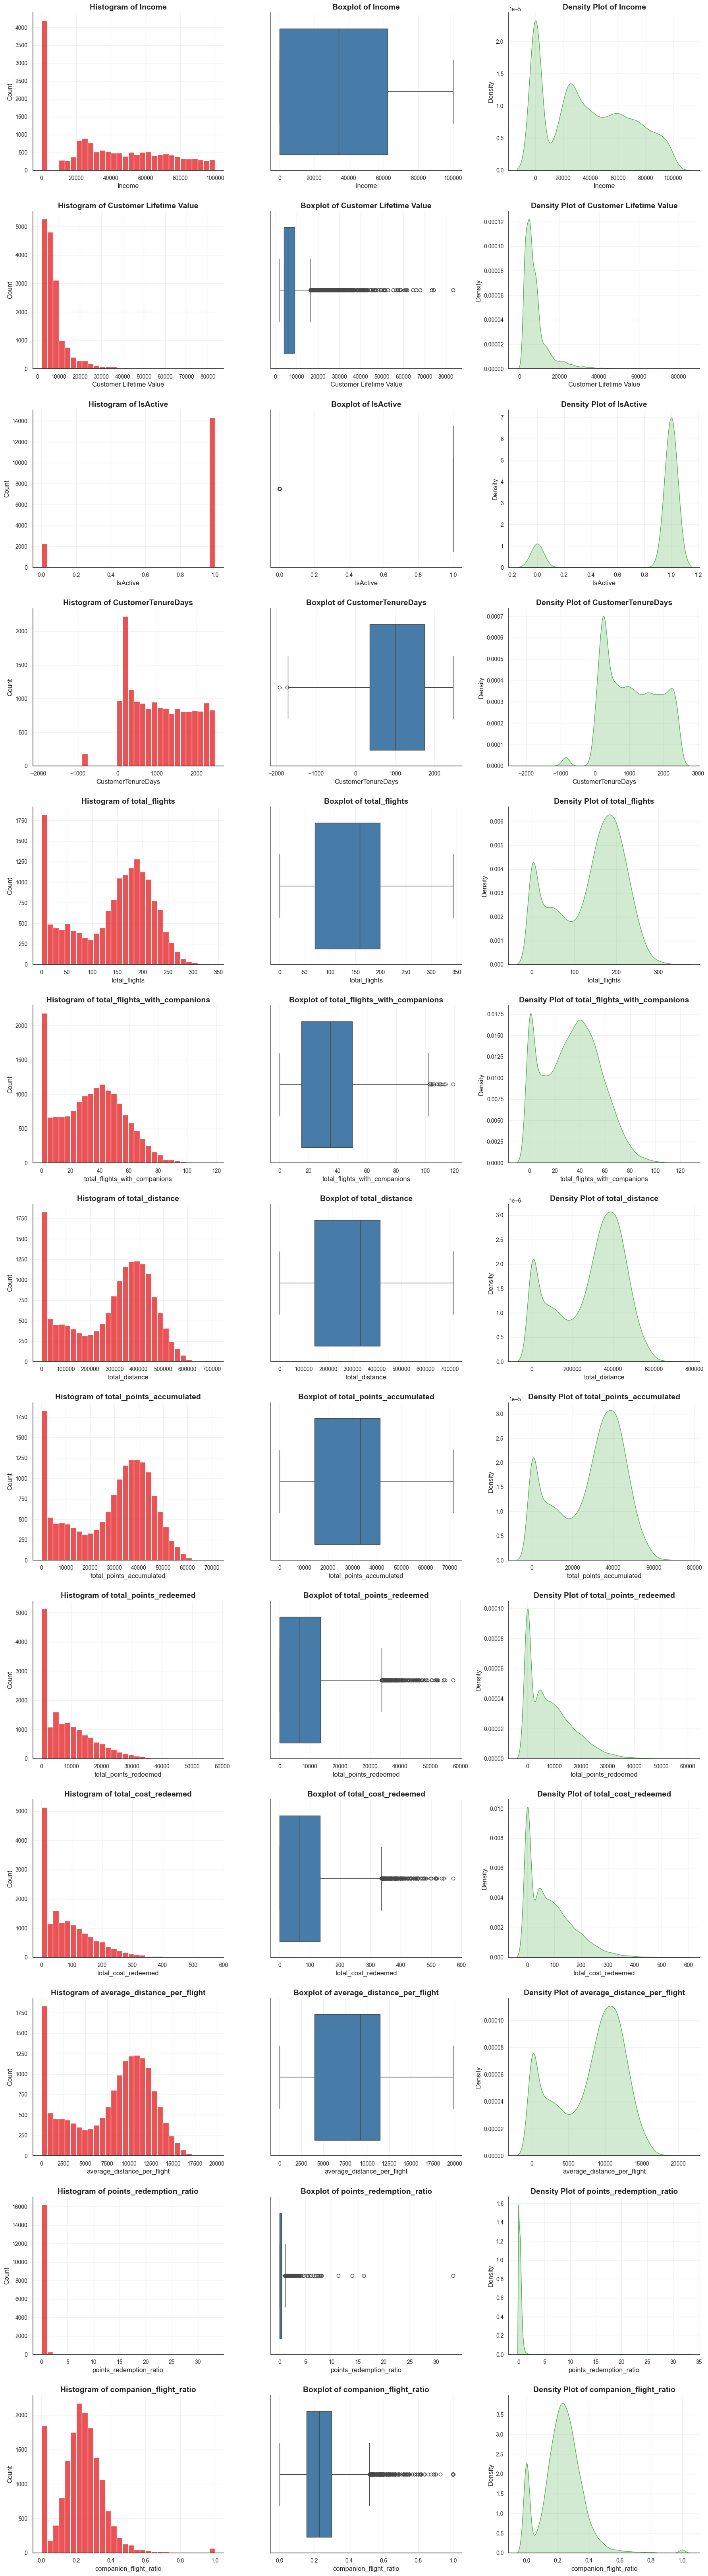

In [46]:
# Create a figure with 3 columns (hist, box, kde)
n_features = len(customers_num.columns)
n_cols = 3
n_rows = n_features

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))

# If there’s only one feature, make axes 2D
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i, col in enumerate(customers_num.columns):
    # Histogram
    sns.histplot(customers_num[col], bins=30, kde=False, ax=axes[i, 0], color=sns.color_palette("Set1")[0])
    axes[i, 0].set_title(f'Histogram of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    # Boxplot
    sns.boxplot(x=customers_num[col], ax=axes[i, 1], color=sns.color_palette("Set1")[1])
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('')

    # Density plot (KDE)
    sns.kdeplot(customers_num[col].dropna(), ax=axes[i, 2], fill=True, color=sns.color_palette("Set1")[2])
    axes[i, 2].set_title(f'Density Plot of {col}')
    axes[i, 2].set_xlabel(col)
    axes[i, 2].set_ylabel('Density')

plt.tight_layout()
sns.despine(fig)
plt.show()


### 4.1.3 Customer EDA - Multivariate Analysis  <a class="anchor" id="customers-eda-multi-variate"></a>




We begin with a correlation heatmap to assess linear relationships among numerical variables. This provides a quick overview of where strong positive or negative associations exist, helping to:

Identify potential multicollinearity (important for model stability and feature selection),

Spot redundant features that may be candidates for removal or transformation,

Guide follow-up analyses (e.g., scatterplots or non-linear measures) where relationships appear substantial.

Correlation coefficients are visualized with a diverging color scale and upper-triangle masking to emphasize the most informative patterns and reduce visual clutter.

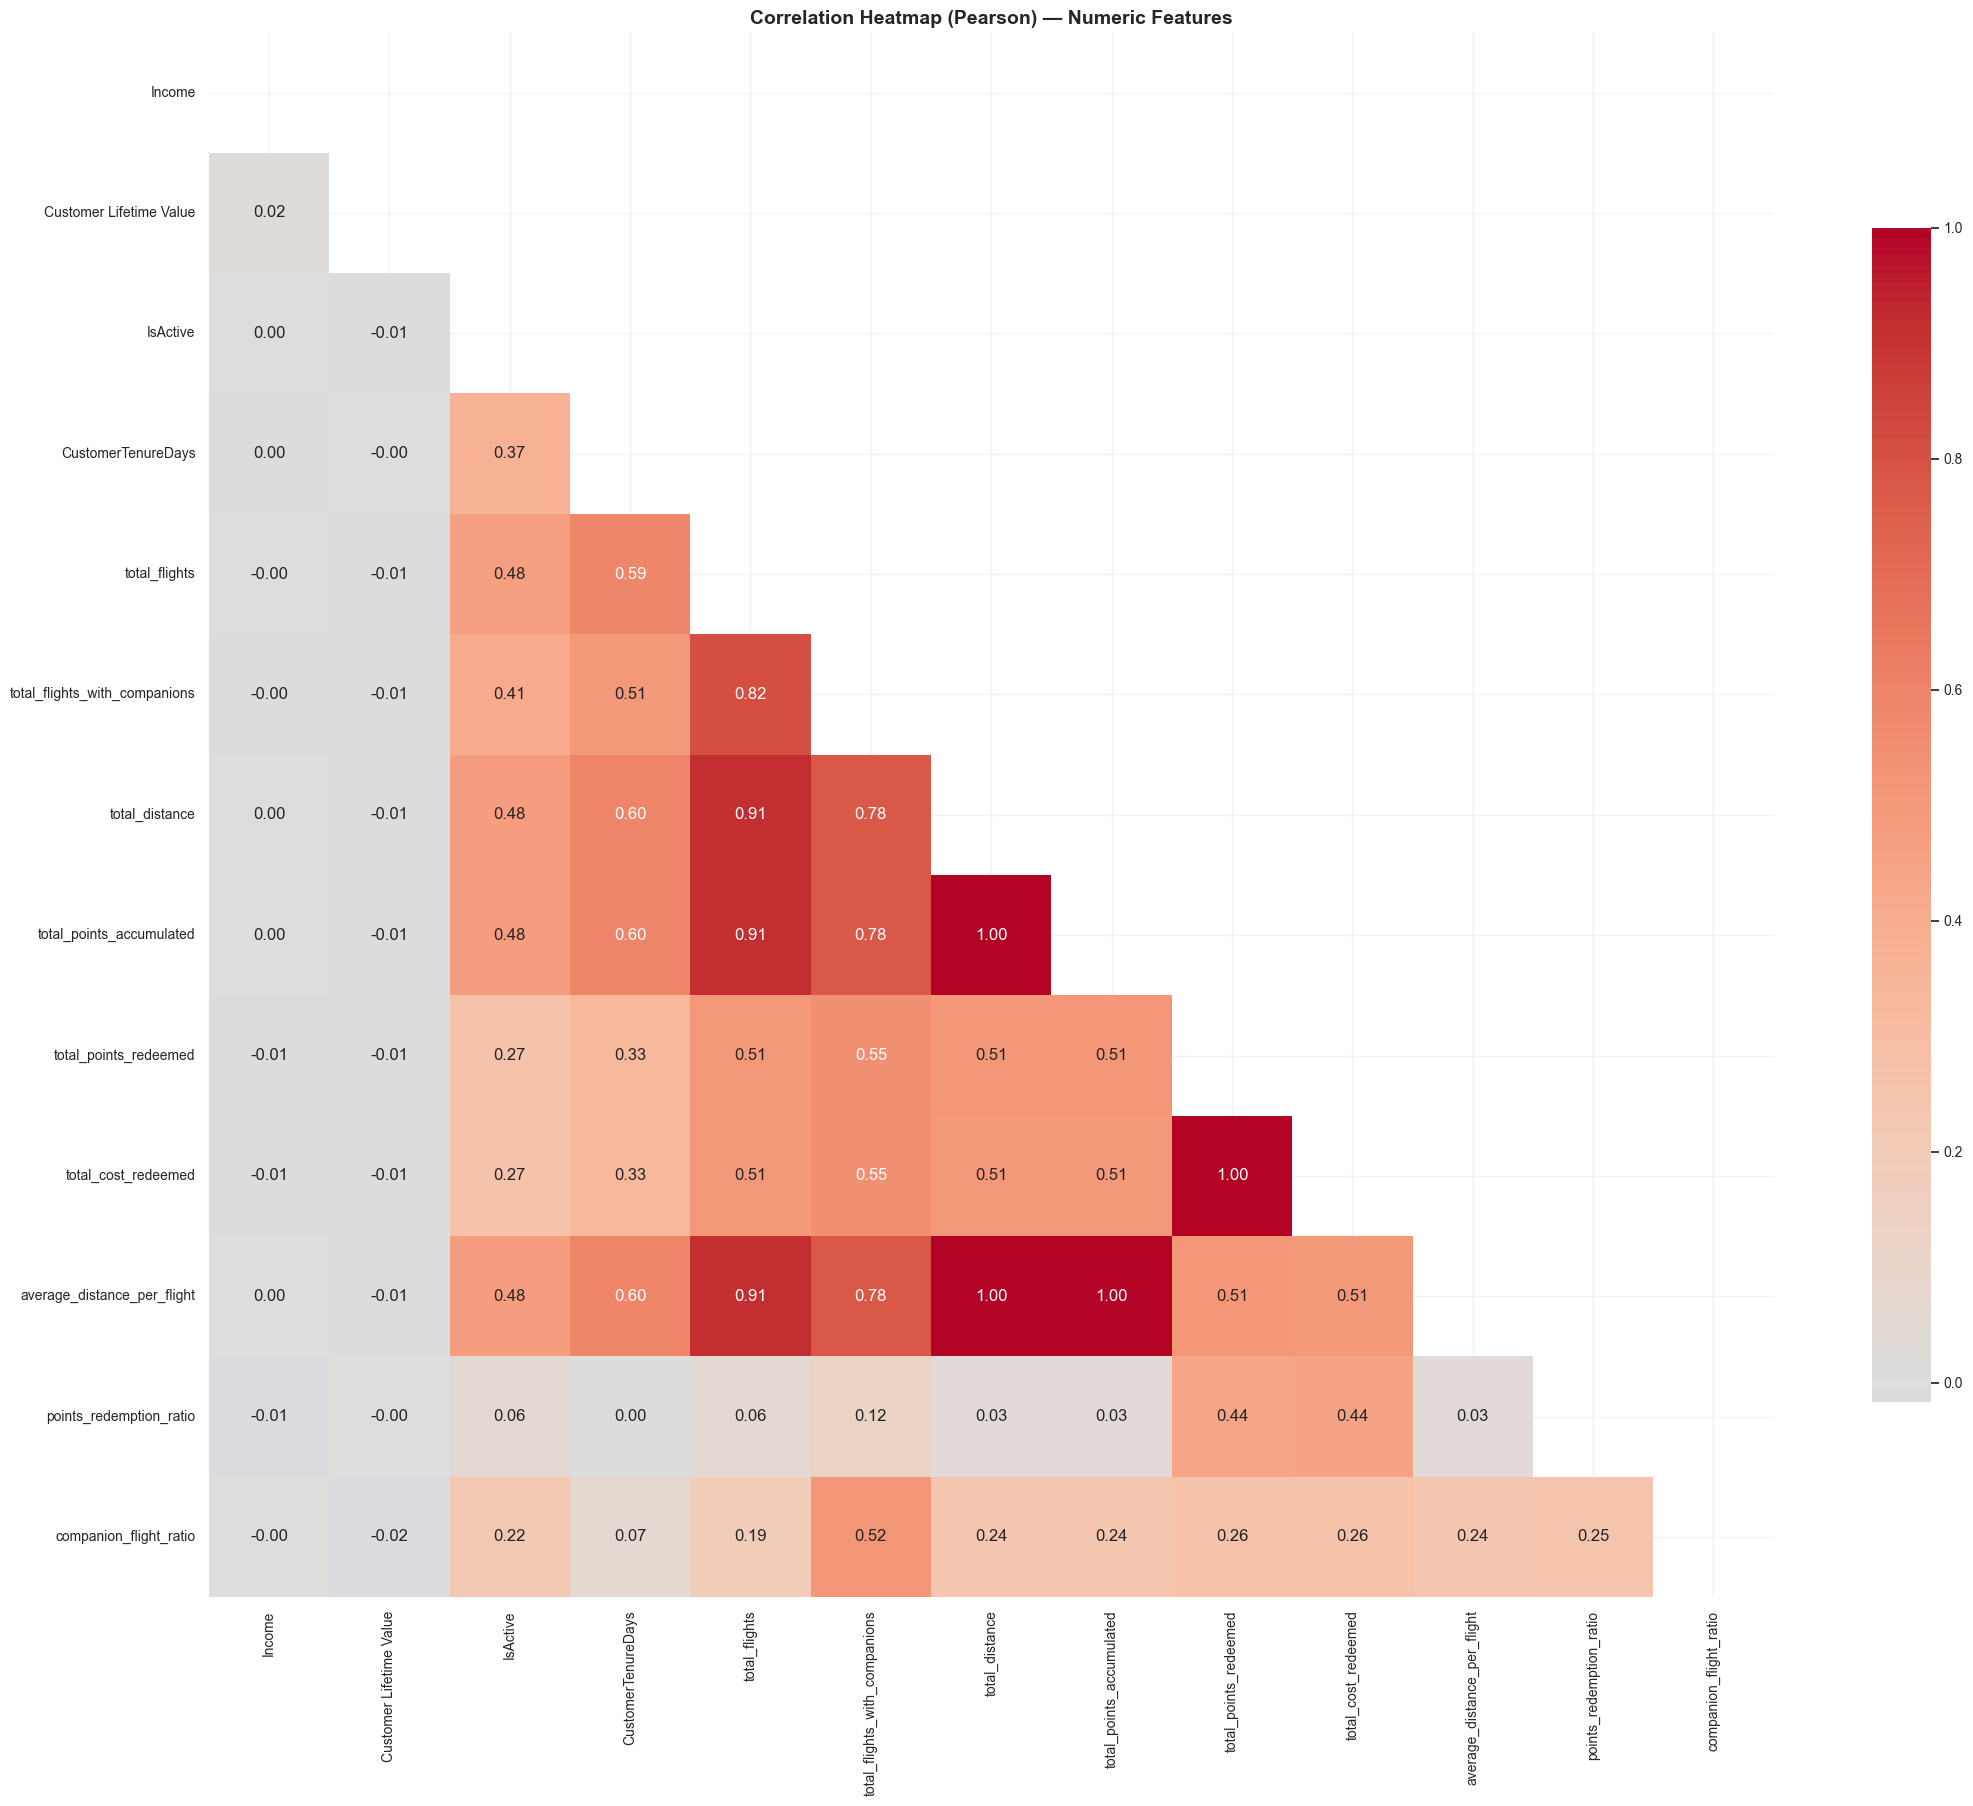

In [47]:
corr = customers_num.corr(method="pearson")

# mask upper triangle for readability
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(min(1.2*len(customers_num), 22), min(1.0*len(customers_num), 18)))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,         
    fmt=".2f",           # show 2 decimal places
    square=True,
    cbar_kws={"shrink": 0.75},
)
plt.title("Correlation Heatmap (Pearson) — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


#### Visualization of Numerical Distributions Across Categories

To explore the relationship between categorical and numerical variables, we pair each categorical feature with a selected numerical feature. Plotting all numerical variables simultaneously would be excessive and potentially obscure meaningful insights.

We employ violin plots with embedded boxplots, as they provide a comprehensive view of the data distribution — illustrating both the underlying density and key summary statistics (median, quartiles, and potential outliers) — for each category within the chosen feature.

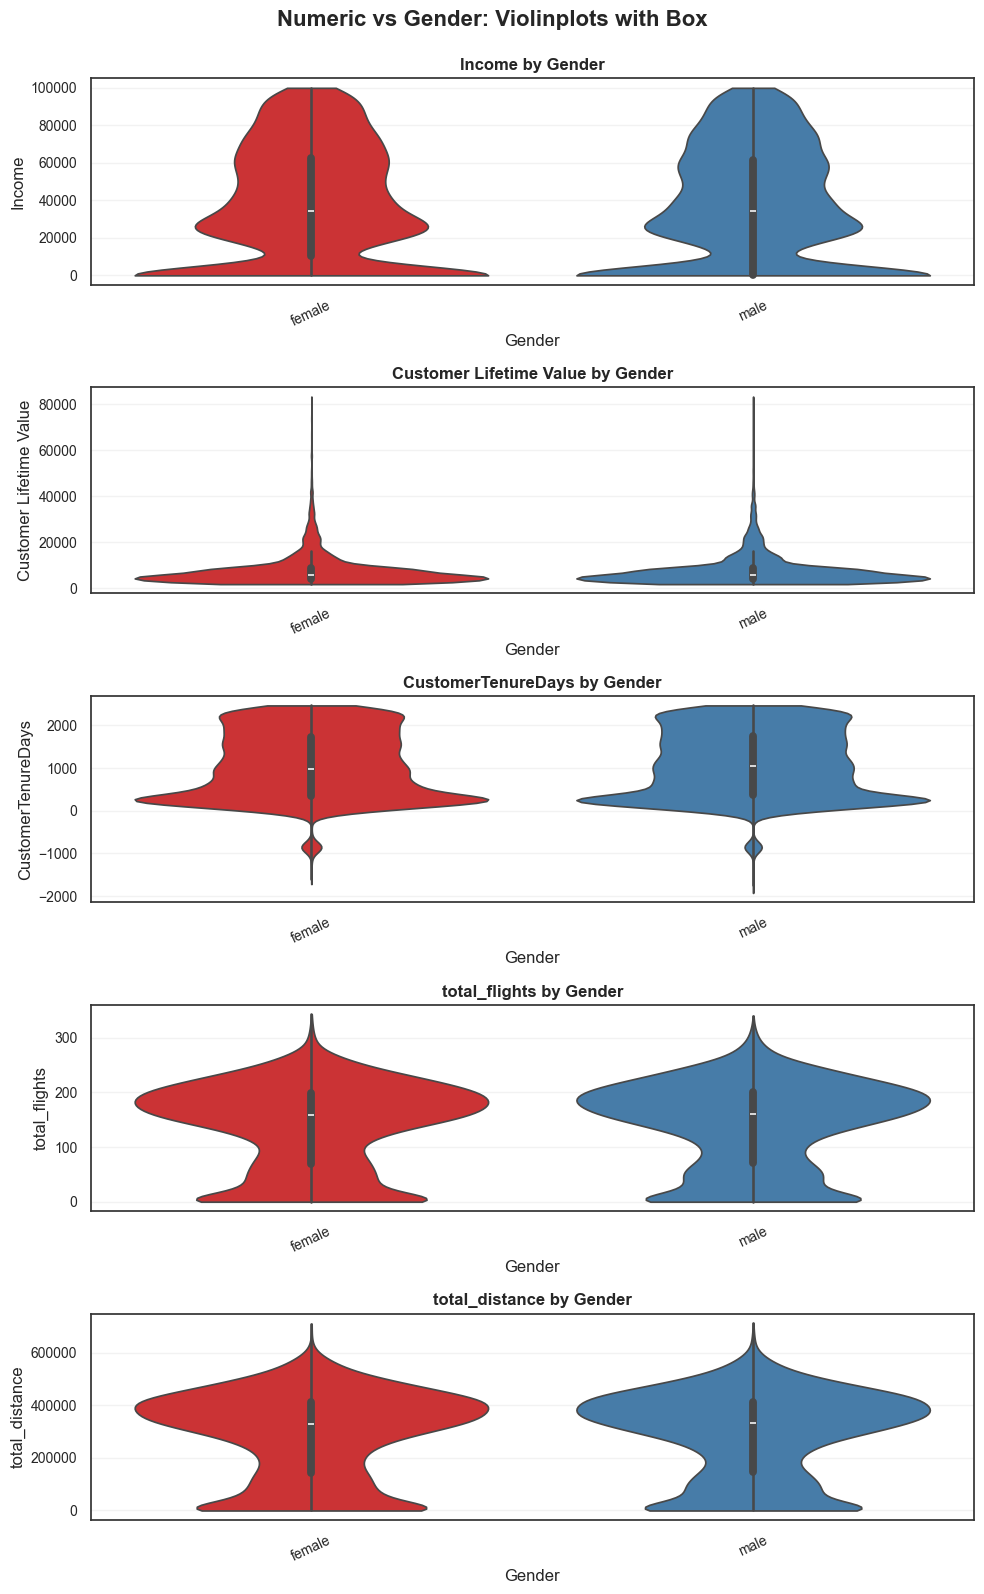

In [48]:
# Gender vs Numeric Features: Violinplots (with internal box)
cat_for_group = "Gender"

#Color Palette
cat_order = customers["Gender"].value_counts().index.tolist()
palette_map, Set1 = make_palette_map(cat_order, palette_name="Set1", as_hex=False)

# List of numeric columns 
num_cols = ('Income', 'Customer Lifetime Value', 'CustomerTenureDays', 'total_flights', 'total_distance')


if cat_for_group in customers.columns and len(num_cols) > 0:
    # Order categories by frequency for consistent x-axis across rows
    cat_order = customers[cat_for_group].value_counts().index.tolist()

    n_rows = len(num_cols)
    fig_height = max(3.2 * n_rows, 4)
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, fig_height), squeeze=False)

    for i, col in enumerate(num_cols):
        ax = axes[i, 0]
        sns.violinplot(
            data=customers,
            x=cat_for_group,
            y=col,
            order=cat_order,
            inner="box",   
            cut=0,
            ax=ax,
            palette=palette_map,
            hue=cat_for_group
        )
        ax.set_title(f"{col} by {cat_for_group}", fontsize=12)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)
        ax.tick_params(axis='x', labelrotation=25)

    fig.suptitle(f"Numeric vs {cat_for_group}: Violinplots with Box", fontsize=16, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found in customers or no numeric columns detected.")


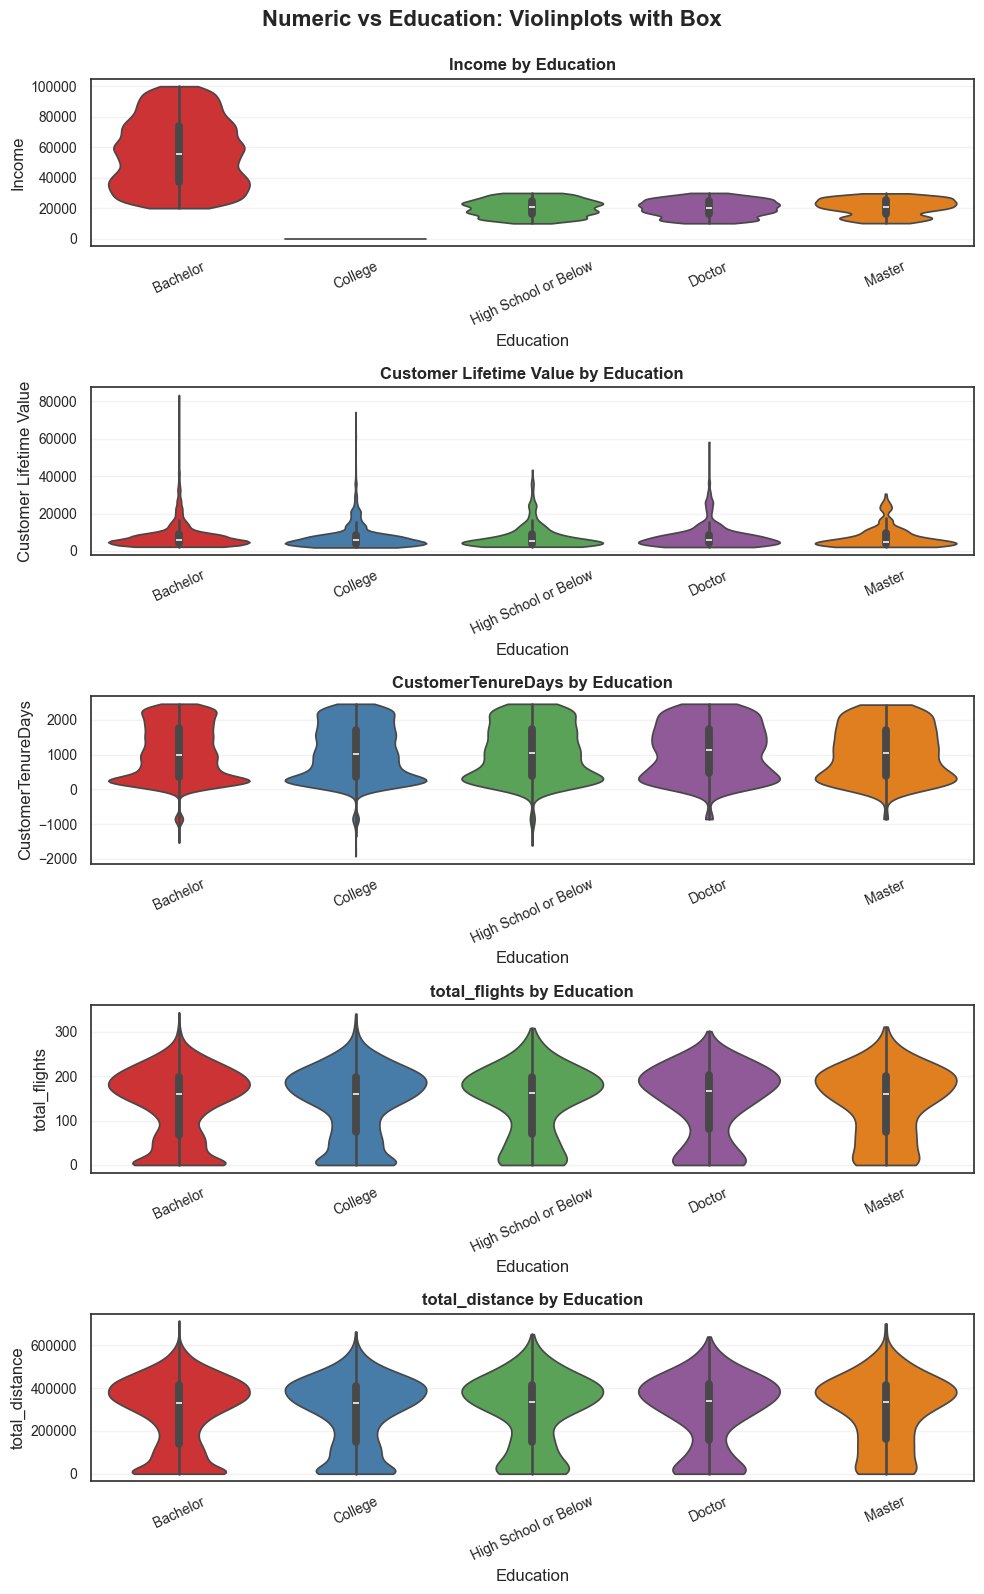

In [49]:
# Education vs Numeric Features: Violinplots (with internal box)
cat_for_group = "Education"

# List of numeric columns 
num_cols = ('Income', 'Customer Lifetime Value', 'CustomerTenureDays', 'total_flights', 'total_distance')

#Color Palette
cat_order = customers["Education"].value_counts().index.tolist()
palette_map, Set1 = make_palette_map(cat_order, palette_name="Set1", as_hex=False)

if cat_for_group in customers.columns and len(num_cols) > 0:
    # Order categories by frequency for consistent x-axis across rows
    cat_order = customers[cat_for_group].value_counts().index.tolist()

    n_rows = len(num_cols)
    fig_height = max(3.2 * n_rows, 4)
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, fig_height), squeeze=False)

    for i, col in enumerate(num_cols):
        ax = axes[i, 0]
        sns.violinplot(
            data=customers,
            x=cat_for_group,
            y=col,
            order=cat_order,
            inner="box",   
            cut=0,
            ax=ax,
            palette=palette_map,
            hue=cat_for_group,
            dodge=False
        )
        ax.set_title(f"{col} by {cat_for_group}", fontsize=12)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)
        ax.tick_params(axis='x', labelrotation=25)

    fig.suptitle(f"Numeric vs {cat_for_group}: Violinplots with Box", fontsize=16, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found in customers or no numeric columns detected.")


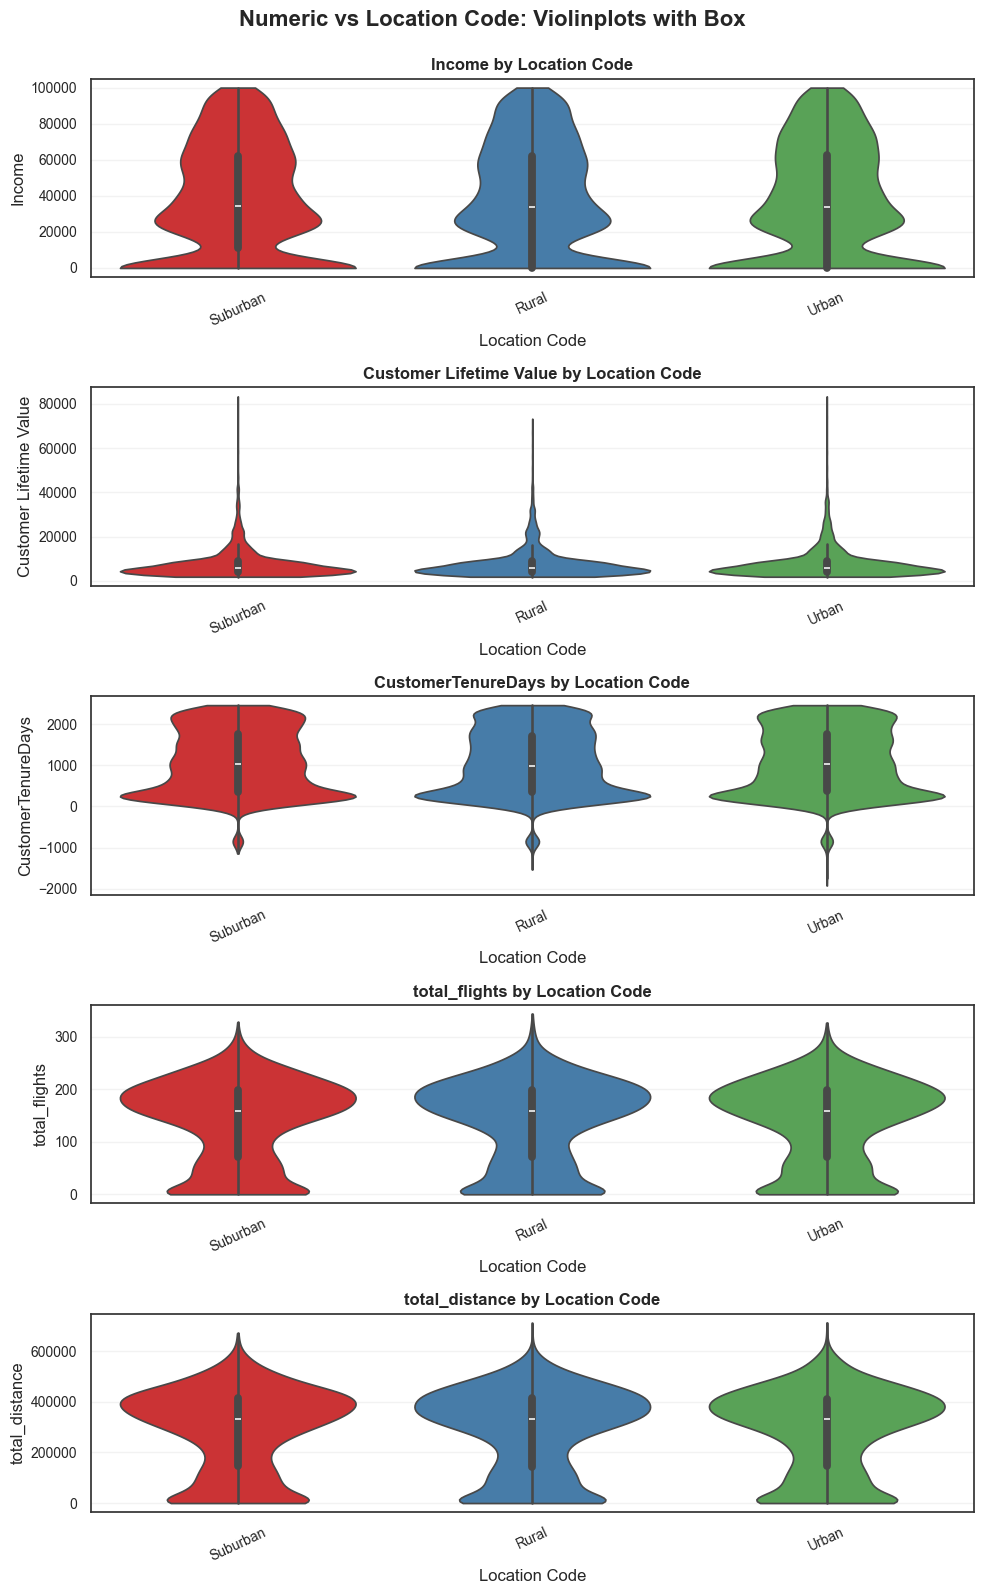

In [50]:
# Location Code vs Numeric Features: Violinplots (with internal box)
cat_for_group = "Location Code"

# List of numeric columns 
num_cols = ('Income', 'Customer Lifetime Value', 'CustomerTenureDays', 'total_flights', 'total_distance')

#Color Palette
cat_order = customers["Location Code"].value_counts().index.tolist()
palette_map, Set1 = make_palette_map(cat_order, palette_name="Set1", as_hex=False)

if cat_for_group in customers.columns and len(num_cols) > 0:
    # Order categories by frequency for consistent x-axis across rows
    cat_order = customers[cat_for_group].value_counts().index.tolist()

    n_rows = len(num_cols)
    fig_height = max(3.2 * n_rows, 4)
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, fig_height), squeeze=False)

    for i, col in enumerate(num_cols):
        ax = axes[i, 0]
        sns.violinplot(
            data=customers,
            x=cat_for_group,
            y=col,
            order=cat_order,
            inner="box",   
            cut=0,
            ax=ax,
            palette=palette_map,
            hue=cat_for_group,
            dodge=False
        )
        ax.set_title(f"{col} by {cat_for_group}", fontsize=12)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)
        ax.tick_params(axis='x', labelrotation=25)

    fig.suptitle(f"Numeric vs {cat_for_group}: Violinplots with Box", fontsize=16, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found in customers or no numeric columns detected.")


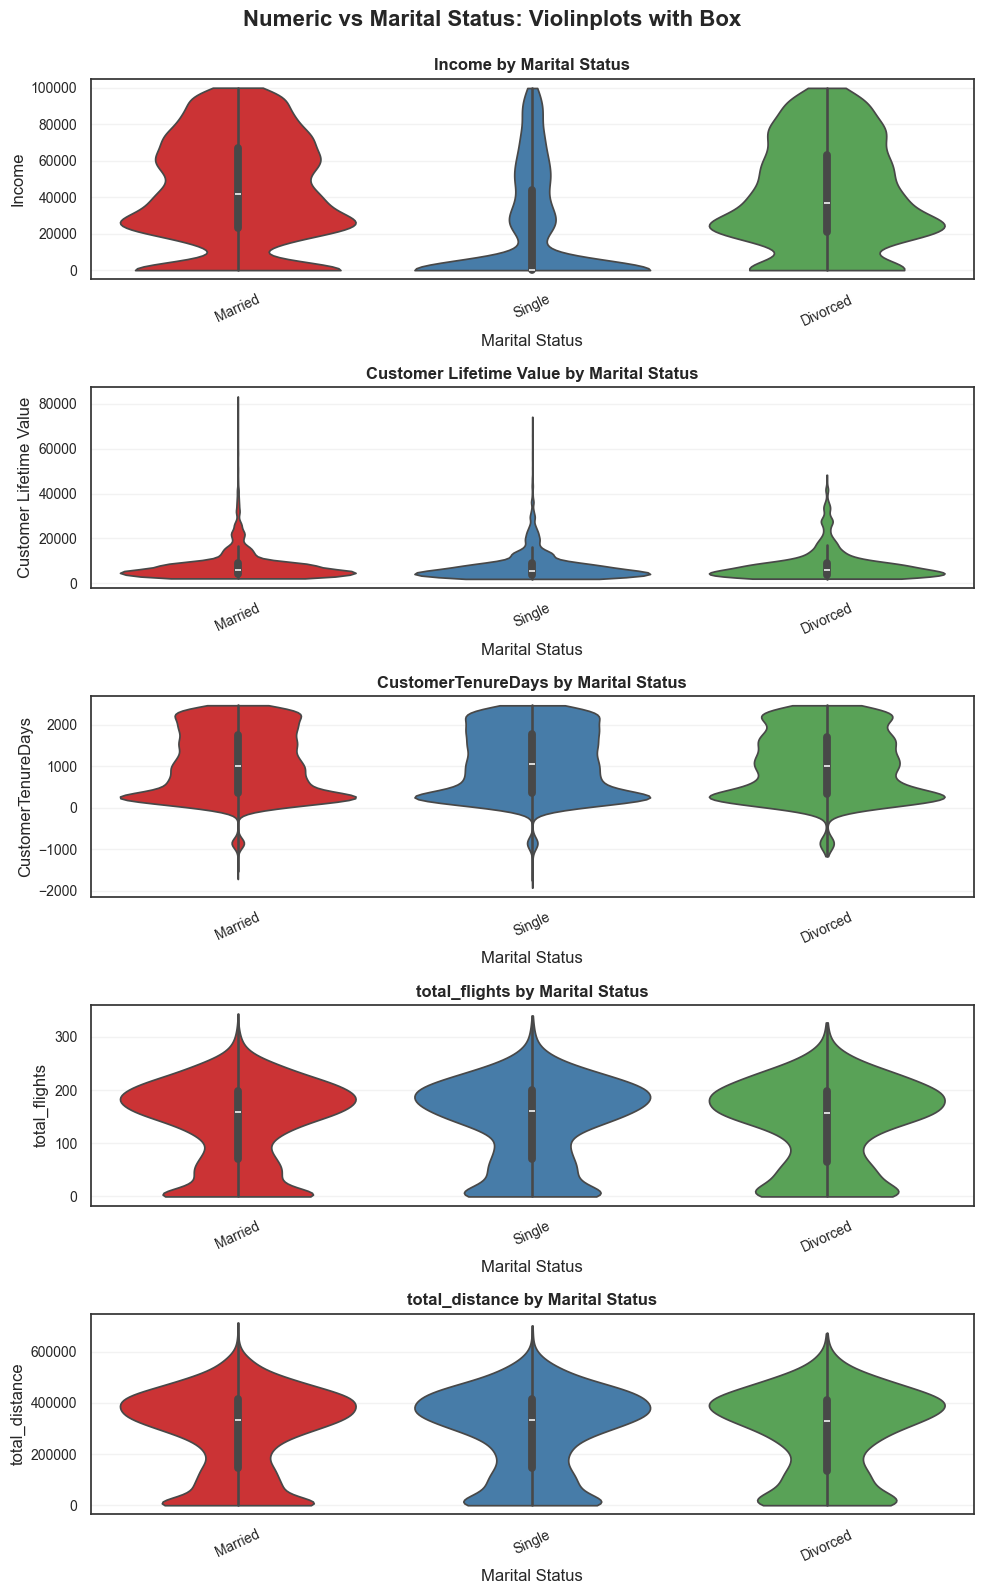

In [51]:
# Marital Status vs Numeric Features: Violinplots (with internal box)
cat_for_group = "Marital Status"

# List of numeric columns 
num_cols = ('Income', 'Customer Lifetime Value', 'CustomerTenureDays', 'total_flights', 'total_distance')

#Color Palette
cat_order = customers["Marital Status"].value_counts().index.tolist()
palette_map, Set1 = make_palette_map(cat_order, palette_name="Set1", as_hex=False)

if cat_for_group in customers.columns and len(num_cols) > 0:
    # Order categories by frequency for consistent x-axis across rows
    cat_order = customers[cat_for_group].value_counts().index.tolist()

    n_rows = len(num_cols)
    fig_height = max(3.2 * n_rows, 4)
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, fig_height), squeeze=False)

    for i, col in enumerate(num_cols):
        ax = axes[i, 0]
        sns.violinplot(
            data=customers,
            x=cat_for_group,
            y=col,
            order=cat_order,
            inner="box",   
            cut=0,
            ax=ax,
            palette=palette_map,
            hue=cat_for_group,
            dodge=False
        )
        ax.set_title(f"{col} by {cat_for_group}", fontsize=12)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)
        ax.tick_params(axis='x', labelrotation=25)

    fig.suptitle(f"Numeric vs {cat_for_group}: Violinplots with Box", fontsize=16, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found in customers or no numeric columns detected.")


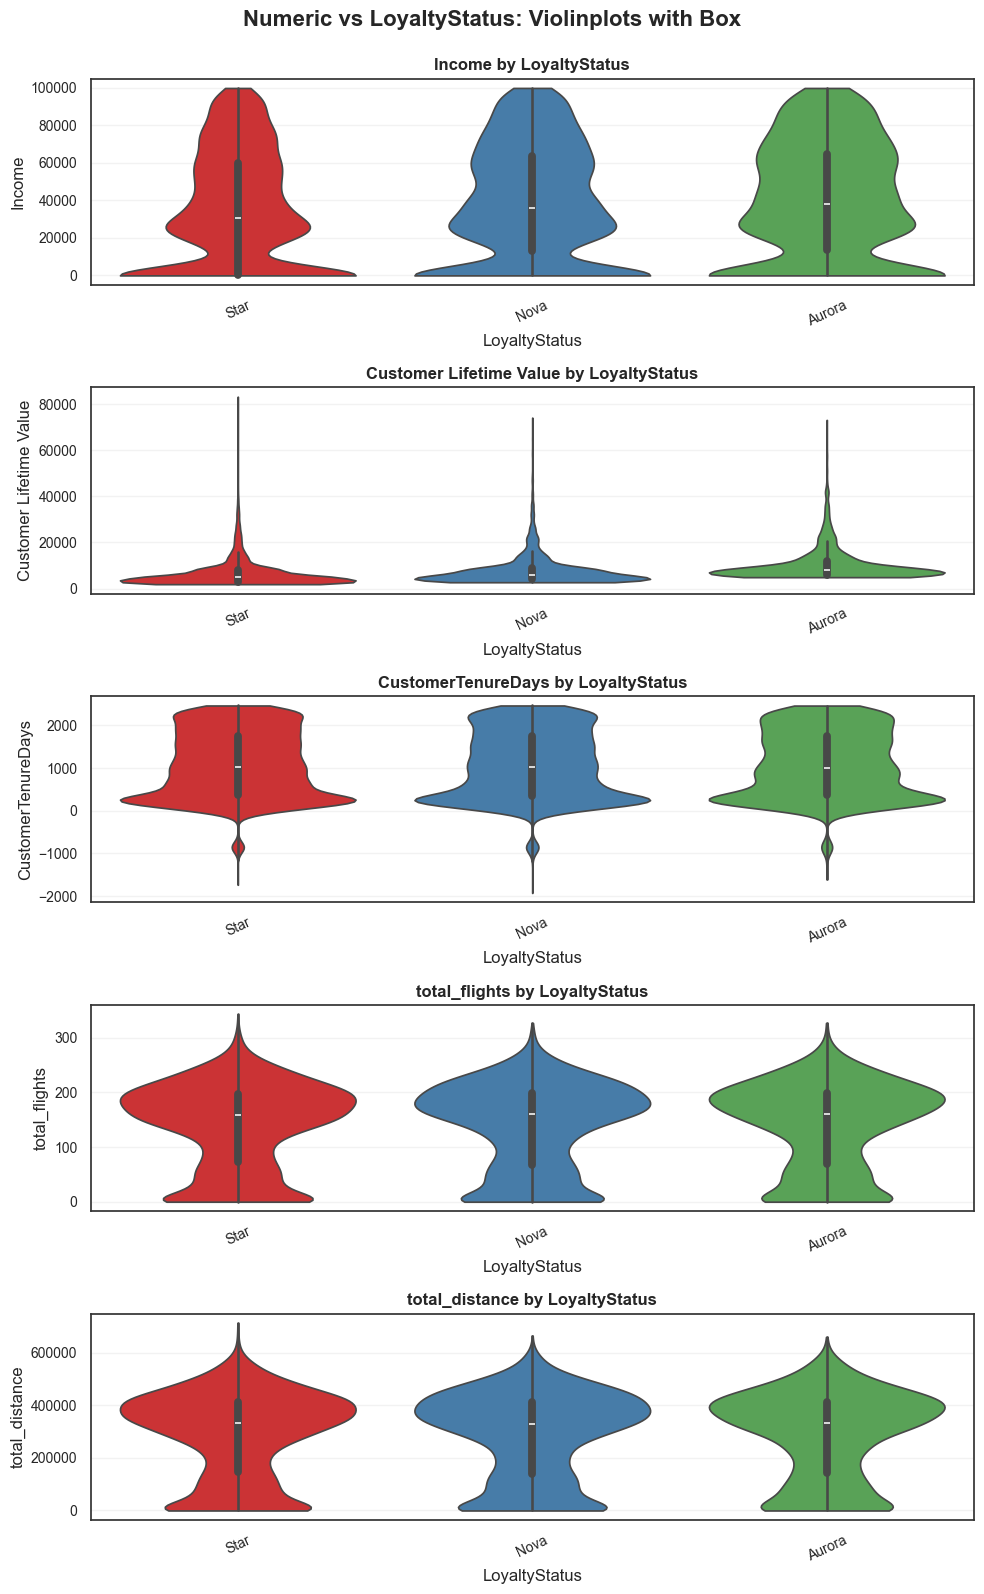

In [52]:
# Loyalty Status vs Numeric Features: Violinplots (with internal box)
cat_for_group = "LoyaltyStatus"

# List of numeric columns 
num_cols = ('Income', 'Customer Lifetime Value', 'CustomerTenureDays', 'total_flights', 'total_distance')

#Color Palette
cat_order = customers["LoyaltyStatus"].value_counts().index.tolist()
palette_map, Set1 = make_palette_map(cat_order, palette_name="Set1", as_hex=False)


if cat_for_group in customers.columns and len(num_cols) > 0:
    # Order categories by frequency for consistent x-axis across rows
    cat_order = customers[cat_for_group].value_counts().index.tolist()

    n_rows = len(num_cols)
    fig_height = max(3.2 * n_rows, 4)
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, fig_height), squeeze=False)

    for i, col in enumerate(num_cols):
        ax = axes[i, 0]
        sns.violinplot(
            data=customers,
            x=cat_for_group,
            y=col,
            order=cat_order,
            inner="box",   
            cut=0,
            ax=ax,
            palette=palette_map,
            hue=cat_for_group,
            dodge=False
        )
        ax.set_title(f"{col} by {cat_for_group}", fontsize=12)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)
        ax.tick_params(axis='x', labelrotation=25)

    fig.suptitle(f"Numeric vs {cat_for_group}: Violinplots with Box", fontsize=16, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found in customers or no numeric columns detected.")


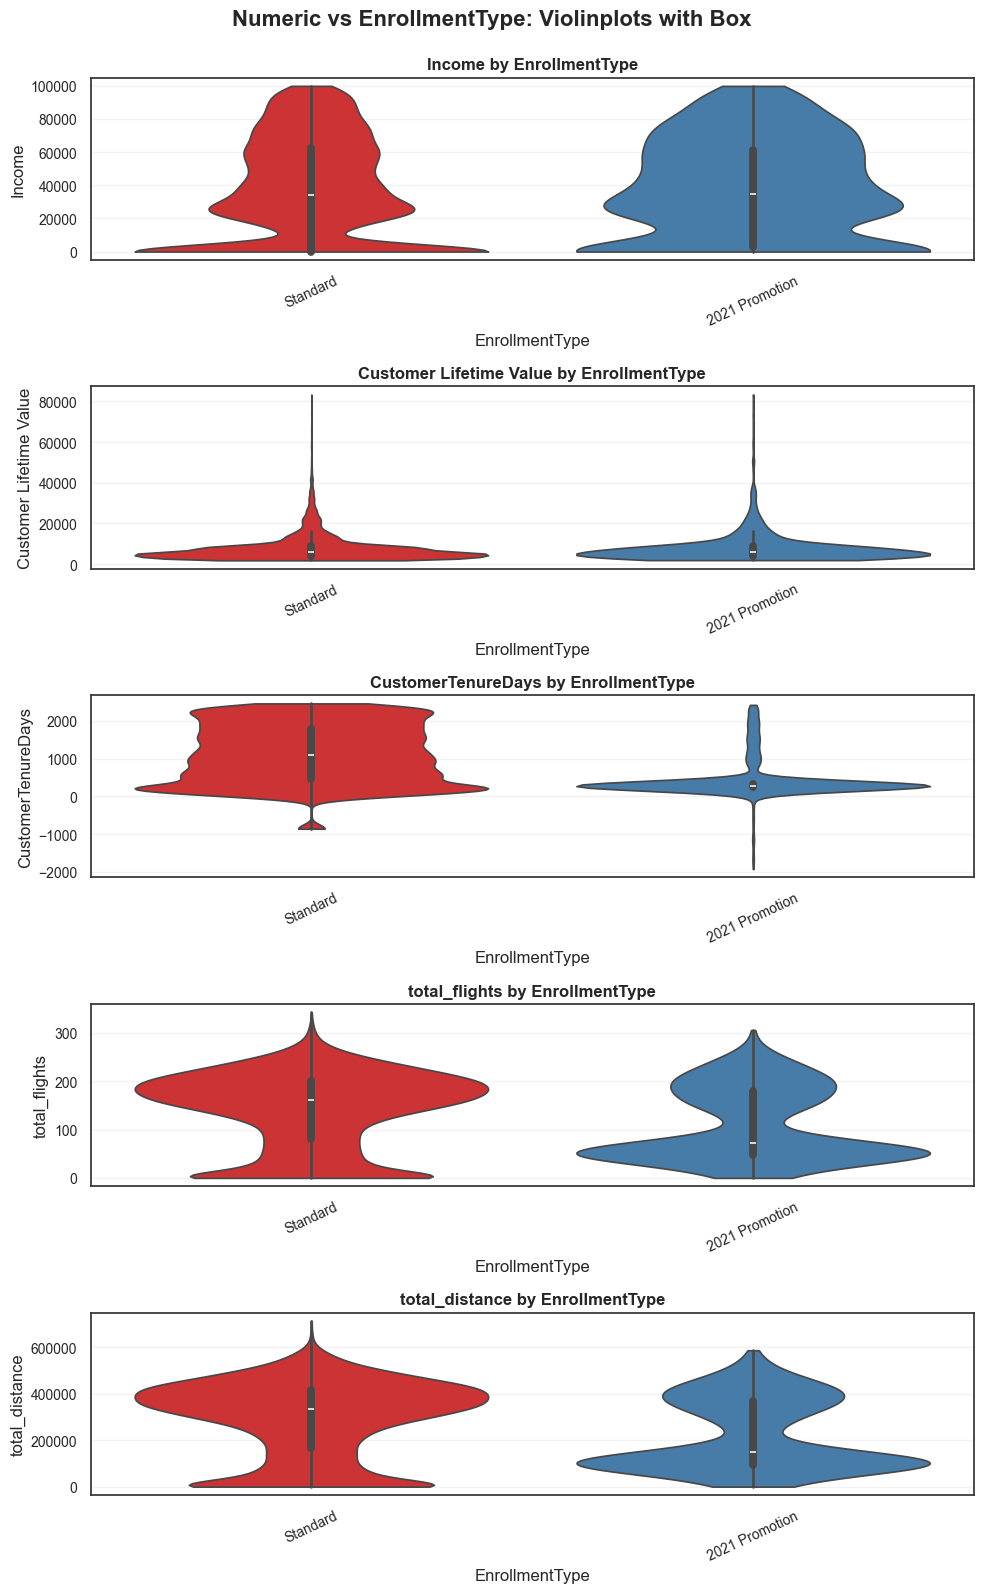

In [53]:
# Enrollment Type vs Numeric Features: Violinplots (with internal box)
cat_for_group = "EnrollmentType"

# List of numeric columns 
num_cols = ('Income', 'Customer Lifetime Value', 'CustomerTenureDays', 'total_flights', 'total_distance')

#Color Palette
cat_order = customers["EnrollmentType"].value_counts().index.tolist()
palette_map, Set1 = make_palette_map(cat_order, palette_name="Set1", as_hex=False)


if cat_for_group in customers.columns and len(num_cols) > 0:
    # Order categories by frequency for consistent x-axis across rows
    cat_order = customers[cat_for_group].value_counts().index.tolist()

    n_rows = len(num_cols)
    fig_height = max(3.2 * n_rows, 4)
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, fig_height), squeeze=False)

    for i, col in enumerate(num_cols):
        ax = axes[i, 0]
        sns.violinplot(
            data=customers,
            x=cat_for_group,
            y=col,
            order=cat_order,
            inner="box",   
            cut=0,
            ax=ax,
            palette=palette_map,
            hue=cat_for_group,
            dodge=False
        )
        ax.set_title(f"{col} by {cat_for_group}", fontsize=12)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)
        ax.tick_params(axis='x', labelrotation=25)

    fig.suptitle(f"Numeric vs {cat_for_group}: Violinplots with Box", fontsize=16, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found in customers or no numeric columns detected.")


We can see that the Income Distribution is different: The highest income levels are achieved by Bachelor Degree holders, while Master, Doctor or High school degrees holders tend to be in lower but similar income levels. The College Degree holders all have an income of 0. 

## 4.2 Flights EDA  <a class="anchor" id="flights-eda"></a>




For the Flights EDA most of the features are numerical. Only one pandas datetime feature is present. We will do univariate analysis to see the distributions of the numerical features.

### 4.2.1 Flights EDA - Numerical Features  <a class="anchor" id="flights-eda-numerical"></a>

Univariate Analysis of Numerical Features

To better understand the distribution and variability of each numerical variable, we conduct a univariate analysis combining three complementary visual perspectives:

Histogram: displays the frequency distribution, providing insight into the shape, spread, and potential skewness of the data.

Boxplot: highlights the median, quartiles, and outliers, enabling a quick assessment of central tendency and variability.

Kernel Density Estimate (KDE) plot: shows a smoothed version of the distribution, offering a continuous perspective on data density.

In [54]:
# Filter for numerical features
num_columns_flights = flights.select_dtypes(include=np.number).columns.tolist()
flights_num = flights[num_columns_flights]

# Remove Loyalty#, Month and Year --> they are not useful for EDA, Month and Year have the same value for all rows
flights_num = flights_num.drop(columns=['Loyalty#', 'Month', 'Year'], errors='ignore')

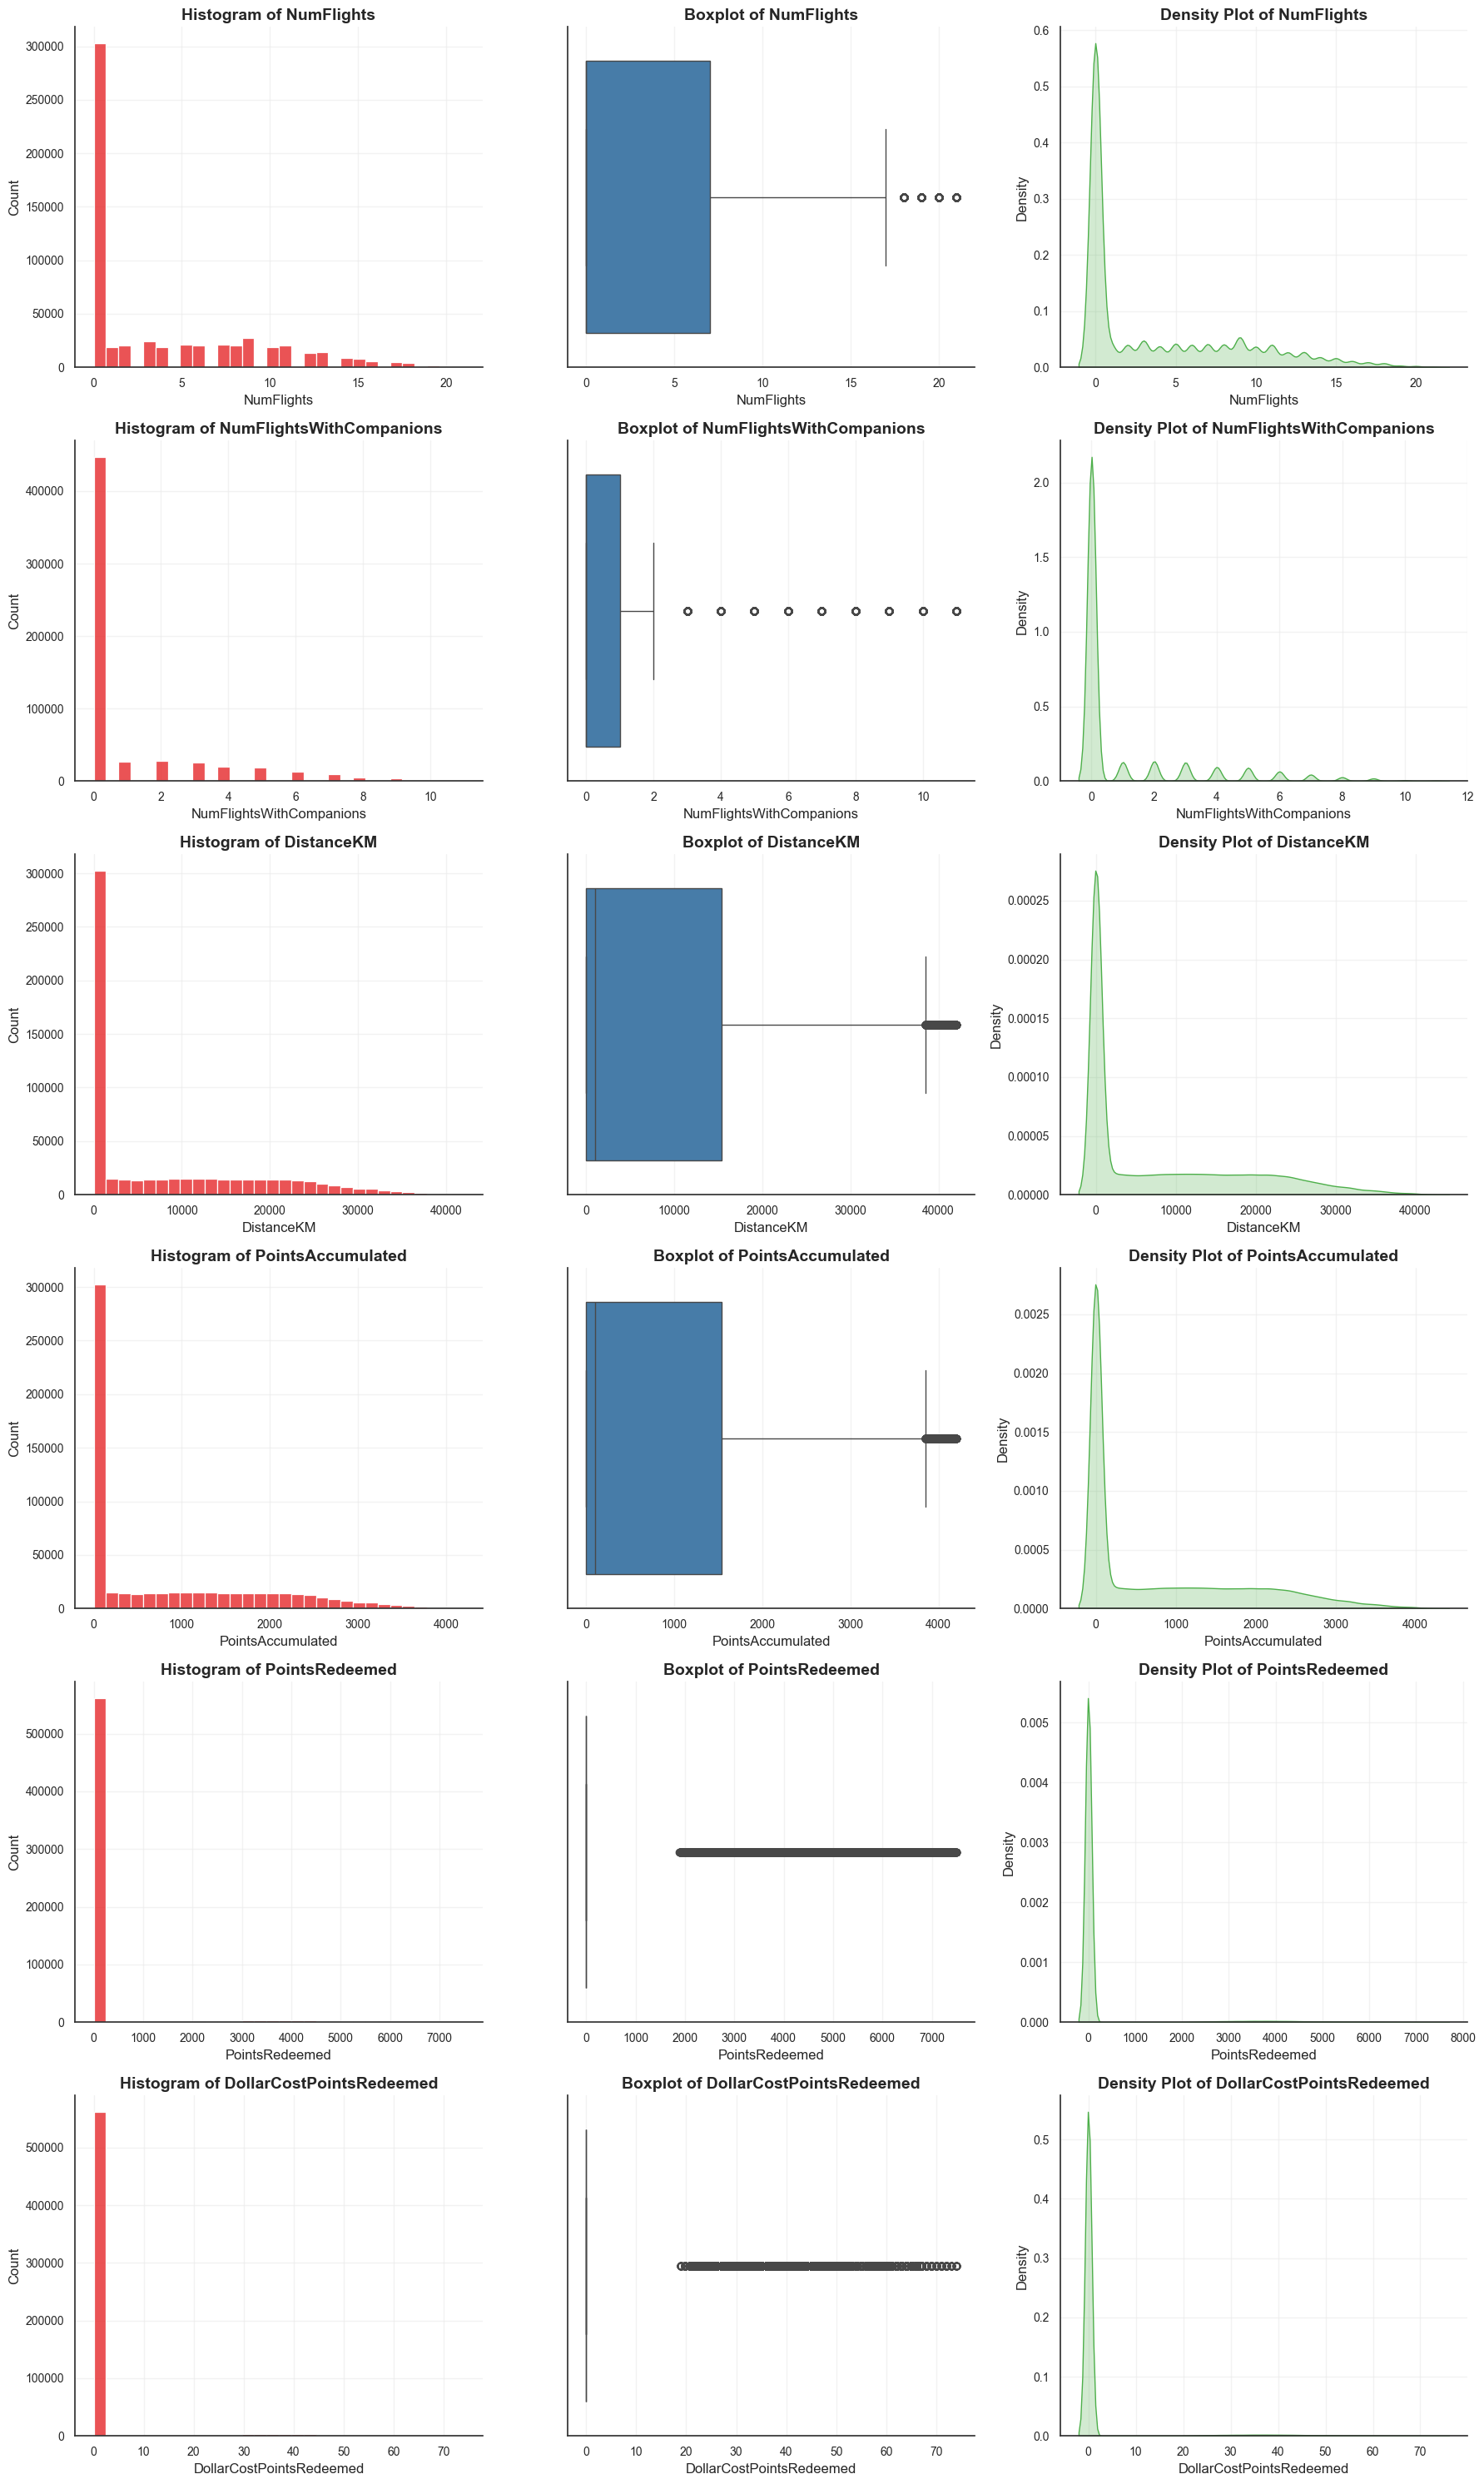

In [55]:
# Create a figure with 3 columns (hist, box, kde)
n_features = len(flights_num.columns)
n_cols = 3
n_rows = n_features

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))

# If there’s only one feature, make axes 2D
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i, col in enumerate(flights_num.columns):
    # Histogram
    sns.histplot(flights_num[col], bins=30, kde=False, ax=axes[i, 0], color=sns.color_palette("Set1")[0])
    axes[i, 0].set_title(f'Histogram of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    # Boxplot
    sns.boxplot(x=flights_num[col], ax=axes[i, 1], color=sns.color_palette("Set1")[1])
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('')

    # Density plot (KDE)
    sns.kdeplot(flights_num[col].dropna(), ax=axes[i, 2], fill=True, color=sns.color_palette("Set1")[2])
    axes[i, 2].set_title(f'Density Plot of {col}')
    axes[i, 2].set_xlabel(col)
    axes[i, 2].set_ylabel('Density')

plt.tight_layout()
sns.despine(fig)
plt.show()


## 4.3 Zero income customers EDA  <a class="anchor" id="flights-eda"></a>


Given the substantial number of customers with no recorded flights, we conduct a focused exploratory analysis of this subgroup to assess whether they differ meaningfully from customers who have flown—across demographic, behavioral, and loyalty-related dimensions. This helps reveal patterns associated with inactive or low-engagement members, informing segmentation and targeted interventions. To operationalize this, we visualize distributions of selected categorical and numerical features.

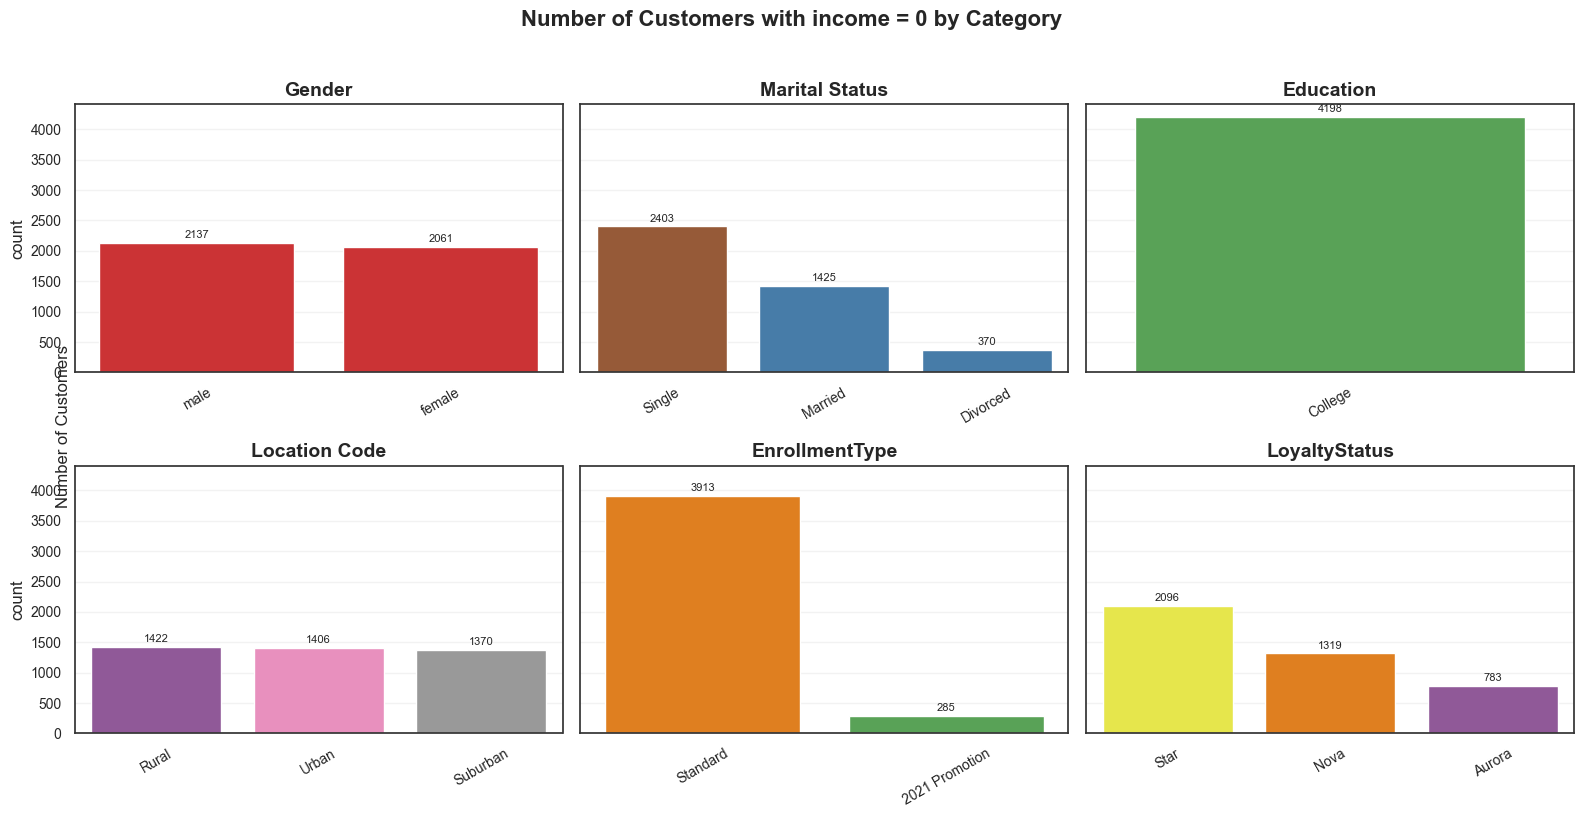

In [56]:
zero_income = customers[customers["Income"] == 0]


cols = ["Gender", "Marital Status", "Education",
        "Location Code", "EnrollmentType", "LoyaltyStatus"]

# Color Palette
all_cats = pd.unique(zero_income[cols].astype(str).values.ravel())
palette_map, Set1 = make_palette_map(all_cats, palette_name="Set1", n_colors=None, as_hex=False)


fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for ax, c in zip(axes, cols):
    order = zero_income[c].value_counts().index
    sns.countplot(data=zero_income, x=c, order=order, ax=ax, palette=palette_map, hue=c)
    ax.set_title(c)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f"{int(h)}",
                        (p.get_x() + p.get_width()/2, h),
                        ha="center", va="bottom", fontsize=8,
                        xytext=(0, 2), textcoords="offset points")

# Common y-label on the leftmost plots; or use a figure-level label:
fig.suptitle("Number of Customers with income = 0 by Category", fontsize=16, fontweight="bold", y=1.02)
fig.text(0.04, 0.5, "Number of Customers", va="center", rotation="vertical")
plt.tight_layout()
plt.show()


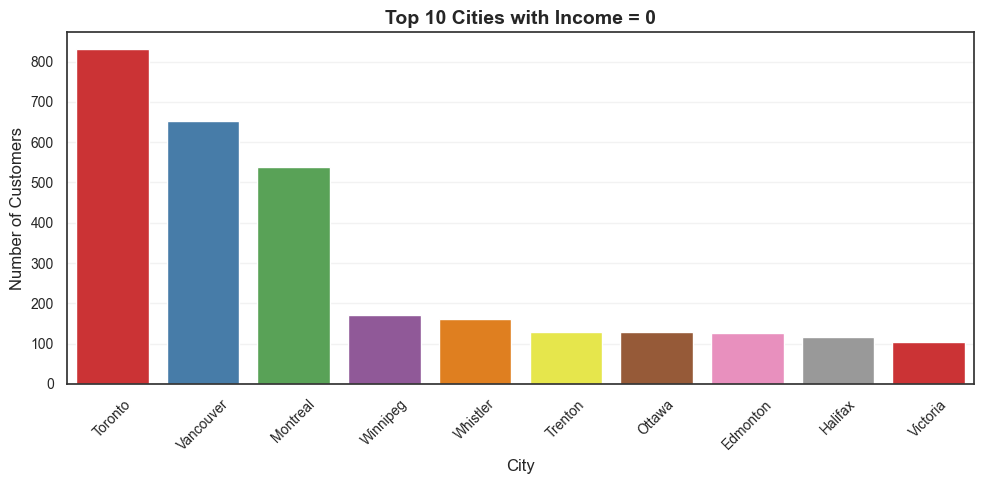

In [57]:
# Calculate counts per city and sort descending
city_counts = zero_income["City"].value_counts().reset_index()
city_counts.columns = ["City", "Count"]

# Keep only Top 10
city_counts = city_counts.head(10)

# Create figure
plt.figure(figsize=(10, 5))

# Bar chart: Number of customers by City (Top 10)
sns.barplot(data=city_counts, x="City", y="Count", palette="Set1", hue="City", dodge=False)

plt.title("Top 10 Cities with Income = 0")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5. Framing the Segmentation Analysis <a class="anchor" id="segmentation-analyses"></a>




In this section, we **delve deeper** into the data. While we do not perform customer segmentation yet, we surface preliminary insights aligned with three segmentation lenses:

- **Value-Based Segmentation**
- **Behavioral Segmentation**
- **Demographic Segmentation**

These observations will inform the subsequent, formal segmentation work.


## 5.1 Value based segmentation   <a class="anchor" id="Flights-EDA"></a>


In this section, we examine the data through the lens of **Value-Based Segmentation**.  
The analysis focuses on customers’ **income** and **Customer Lifetime Value (CLV)** to identify patterns that may indicate different levels of economic contribution and overall value to the airline.


## 5.1.1 Income-Based Segmentation <a class="anchor" id="Flights-EDA"></a>


We begin with **income-based segmentation** by defining income ranges and assigning customers to these groups. The ranges are anchored to the **median income in Canada (~40,000 CAD)**, where approximately 50% of the population earns below this threshold and 50% above.

> **Assumption:** The dataset does not specify currency. For consistency with the benchmark, we assume all income values are expressed in **CAD**.

After grouping customers into income bands, we analyze the composition and characteristics of each group to surface patterns relevant for value-oriented decision-making.


Income_Group
Very Low     6377
Low          2051
Medium       1577
High         2054
Very High    4515
Name: count, dtype: int64


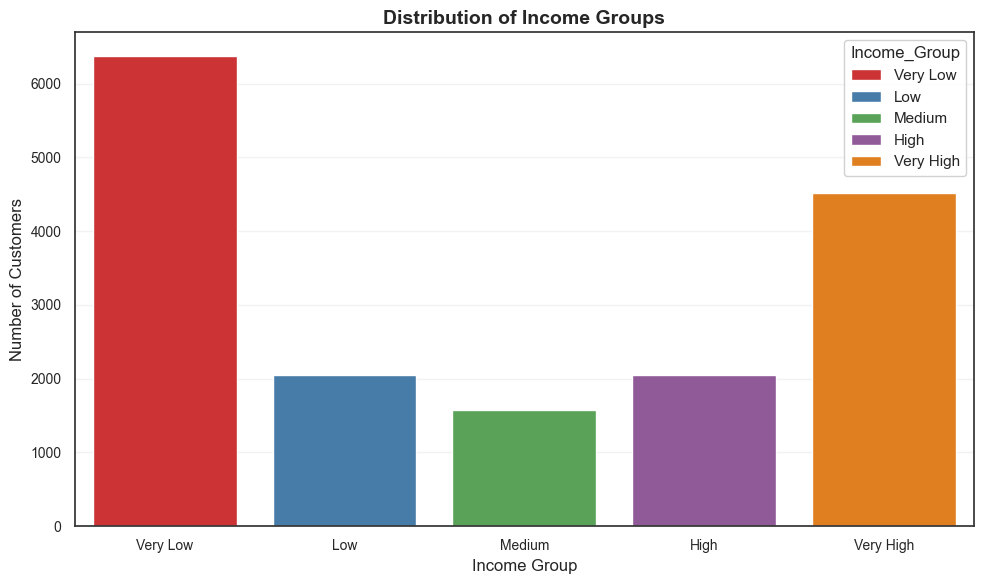

In [118]:
# Create a new column and groupBy Income ranges

ranked = customers['Income'].rank(method='first')  # bricht Ties deterministisch
customers['Income_Group'] = pd.qcut(
    ranked, q=5, labels=['Very Low','Low','Medium','High','Very High']
)

# Get the median Income from Statistca aroung 40k median income
# https://www.statista.com/statistics/464087/median-annual-earnings-in-canada/?srsltid=AfmBOorobKVMkA5XzryvSxoVhMDd2nOgjsvVJ3QwOdzoxHITF-YTxYi1
median_income = 40000

# Define custom bins around the median
bins = [0, 25000, 35000, 45000, 60000, customers['Income'].max()]

labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

# Categorize based on custom bins
customers['Income_Group'] = pd.cut(customers['Income'], bins=bins, labels=labels, include_lowest=True)

# Check the distribution
print(customers['Income_Group'].value_counts().sort_index())

# Optional: check mean/median per group
#print(customers.groupby('Income_Group')['Income'].mean())
#print(customers.groupby('Income_Group')['Income'].median())

# Plot the distribution of Income_Group
plt.figure(figsize=(10, 6))
sns.countplot(data=customers, x='Income_Group', order=labels, palette='Set1', hue='Income_Group', dodge=False)
plt.title('Distribution of Income Groups')
plt.xlabel('Income Group')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


### Observations on Income Group Distribution

The income segmentation reveals a **bimodal pattern**: many customers fall into the **very low** and **high** income groups, while the **middle** income range is comparatively underrepresented. Although one might expect a more bell-shaped distribution, this pattern suggests the airline may be attracting customers at both ends of the income spectrum. The underlying drivers remain unclear and warrant **further analysis** (e.g., pricing, route network, product mix, promotions).

> **Note on interpretation:** Because the income groups are **unevenly distributed**, we anticipate similar imbalance in related feature distributions. We deliberately **do not normalize** group sizes here to preserve the **true empirical distribution** and avoid masking real patterns; results should be interpreted with this imbalance in mind.


### Feature Distributions by Income Group

In the following section, we visualize selected **numerical** and **categorical** features across the defined **income groups**.  
These plots help identify how customer characteristics and behaviors vary by income level, providing early indications of potential value-based differentiation within the customer base.


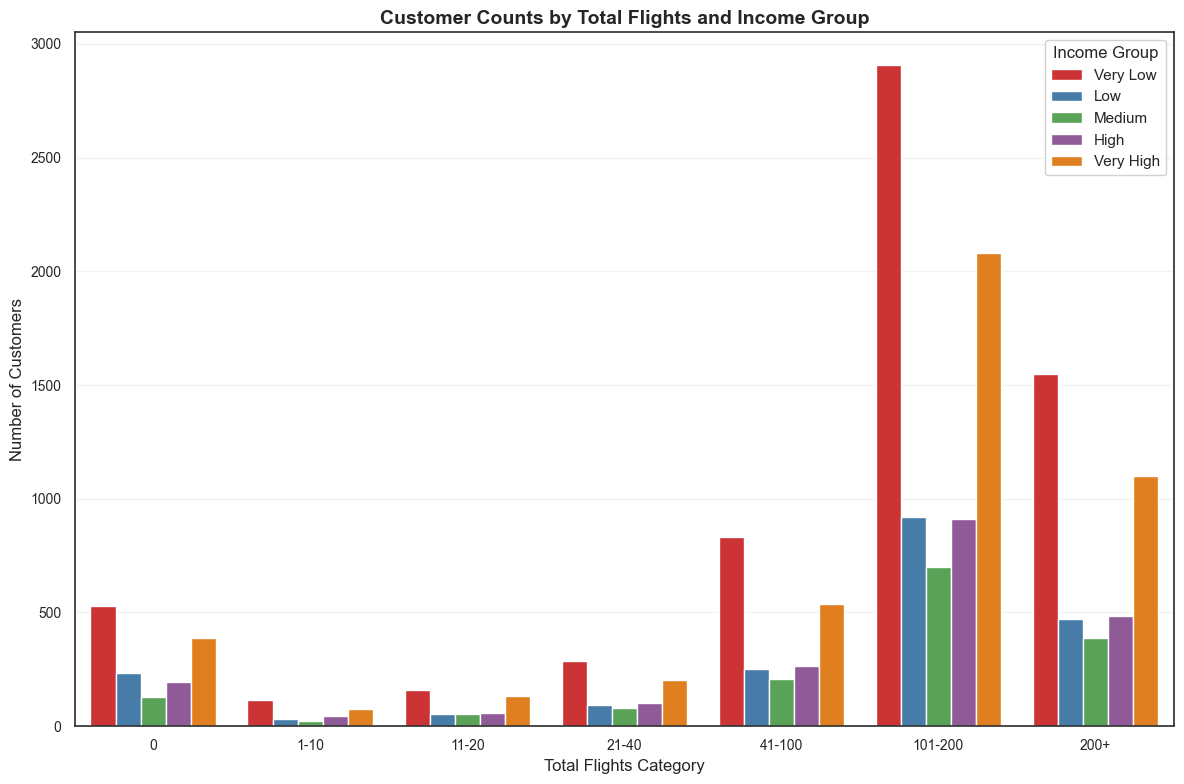

In [119]:
# Plot the following: Bar chart. Y-Axis counts the amount of customers. X-Axis is for the categories of total_flights. 
# The total flights categories are 0, 1-10, 10-20, 20-40, 41-100, 101-200, 200+.
# For every income group, plot a separate bar chart with different colors.
plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    x=pd.cut(
        customers['total_flights'],
        bins=[0, 1, 11, 21, 41, 101, 201, float('inf')],
        labels=['0', '1-10', '11-20', '21-40', '41-100', '101-200', '200+'],
        right=False
    ),
    palette='Set1',
    hue='Income_Group',
    order=['0', '1-10', '11-20', '21-40', '41-100', '101-200', '200+']
)
plt.title('Customer Counts by Total Flights and Income Group')
plt.xlabel('Total Flights Category')
plt.ylabel('Number of Customers')
plt.legend(title='Income Group')
plt.tight_layout()
plt.show()


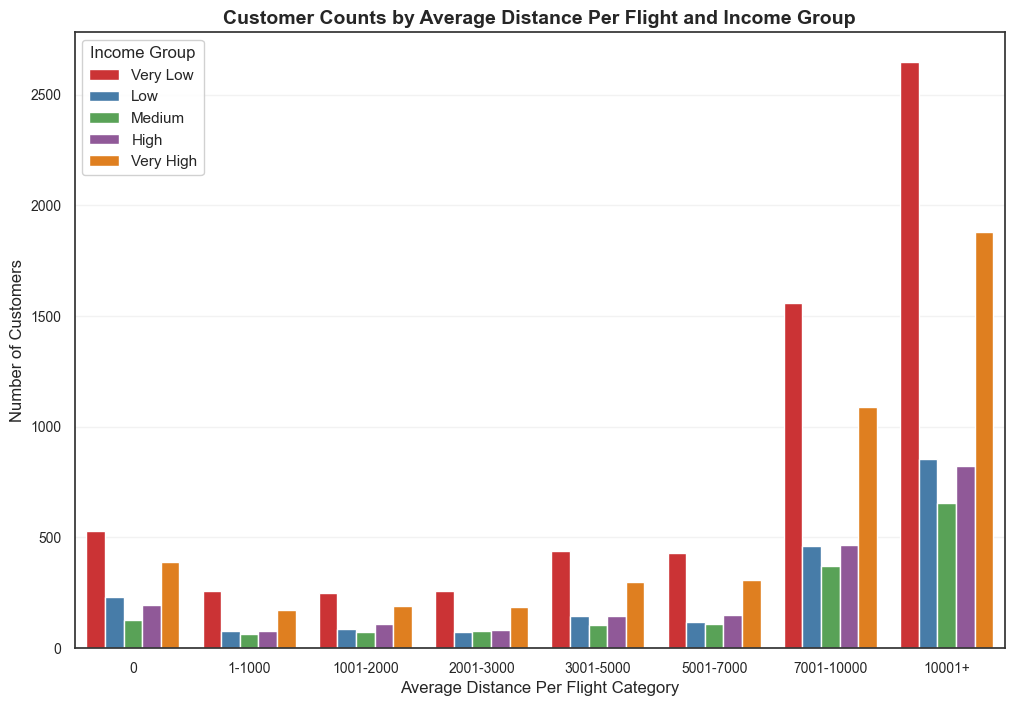

In [120]:
# Plot the following: Bar chart. Y-Axis counts the amount of customers. X-Axis is for the categories of average_distance.
# The average distance categories are 0, 1 - 1000, 1001 - 2000, 2001- 3000, 3001 - 5000, 5001 - 7000, 7001 - 10000, 10001+.
# For every income group, plot a separate bar chart with different colors.
plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    x=pd.cut(
        customers['average_distance_per_flight'],
        bins=[-1, 0, 1000, 2000, 3000, 5000, 7000, 10000, np.inf],
        labels=['0', '1-1000', '1001-2000', '2001-3000', '3001-5000', '5001-7000', '7001-10000', '10001+'],
                        right=True
    ),
    palette='Set1',
    hue='Income_Group',
    order=['0', '1-1000', '1001-2000', '2001-3000', '3001-5000', '5001-7000', '7001-10000', '10001+']
)
plt.title('Customer Counts by Average Distance Per Flight and Income Group')
plt.xlabel('Average Distance Per Flight Category')
plt.ylabel('Number of Customers')
plt.legend(title='Income Group')
plt.tight_layout()
plt.show()


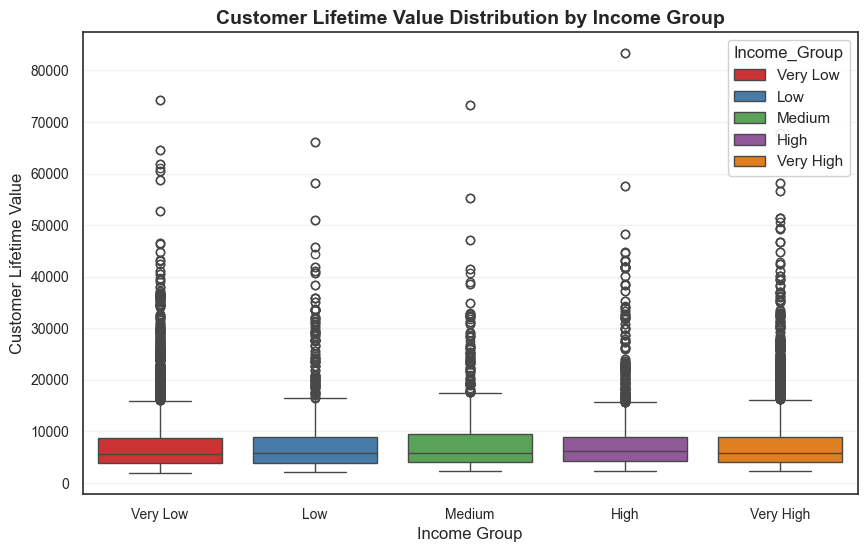

In [61]:
# Boxplot for every income group for Customer Lifetime Value
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=customers,
    x='Income_Group',
    y='Customer Lifetime Value',
    order=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    palette='Set1',
    hue='Income_Group',
    dodge=False
)
plt.title('Customer Lifetime Value Distribution by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Customer Lifetime Value')
plt.tight_layout()
plt.show()

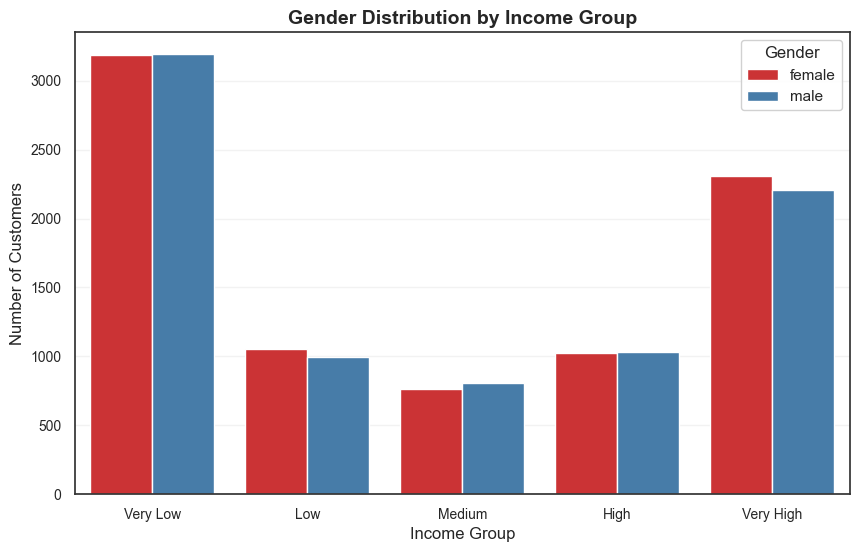

In [62]:
# Gender distribution per income group 
plt.figure(figsize=(10, 6))
sns.countplot(
    data=customers,
    x='Income_Group',
    order=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    palette='Set1',
    hue='Gender',
    dodge=True
)
plt.title('Gender Distribution by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Number of Customers')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

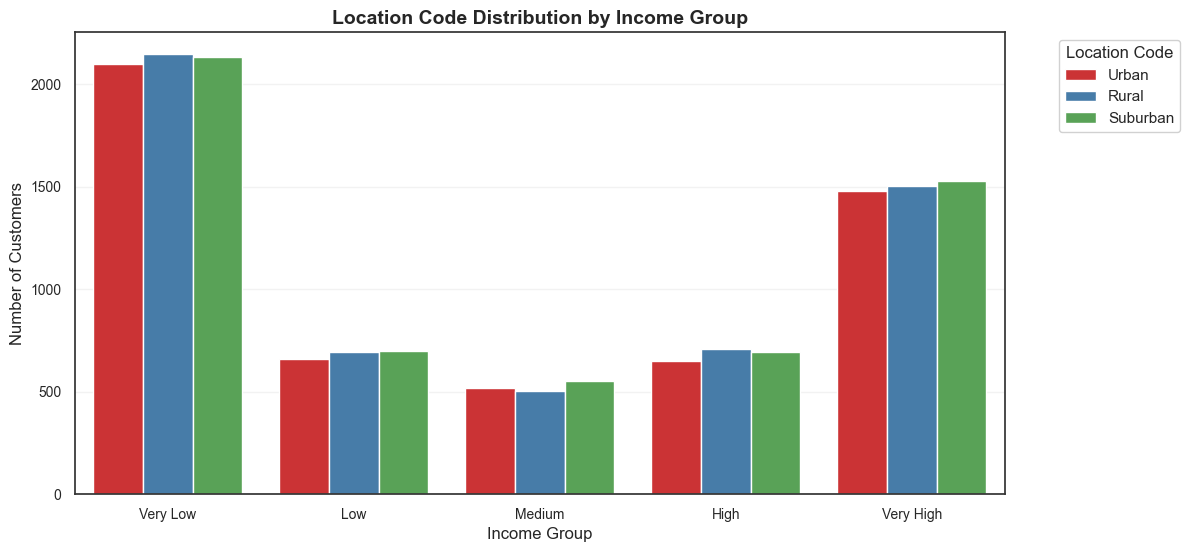

In [63]:
# Location Code distribution per income group
plt.figure(figsize=(12, 6))
sns.countplot(
    data=customers,
    x='Income_Group',
    hue='Location Code',
    order=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    palette='Set1'
)
plt.title('Location Code Distribution by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Number of Customers')
plt.legend(title='Location Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()  

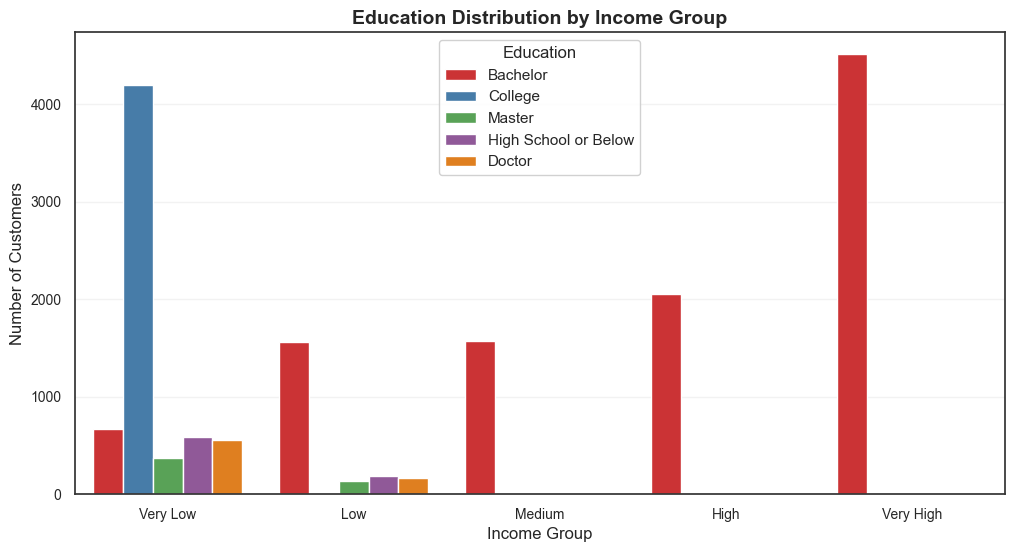

In [64]:
# Education distribution per income group
plt.figure(figsize=(12, 6))
sns.countplot(
    data=customers,
    x='Income_Group',
    hue='Education',
    order=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    palette='Set1',
)
plt.title('Education Distribution by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Number of Customers')
plt.legend(title='Education')
plt.tight_layout()
plt.show()

### Business-Ready Visualization Variant

The next figure reproduces the previous analysis with a **business-oriented design** suitable for stakeholder reports. While the notebook prioritizes a **scientific style** for exploration and reproducibility, this version emphasizes **clarity, polish, and presentation quality** to support inclusion in executive summaries and formal deliverables.


/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_83968/782106939.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  education_data = customers.groupby(['Income_Group', 'Education']).size().unstack(fill_value=0)


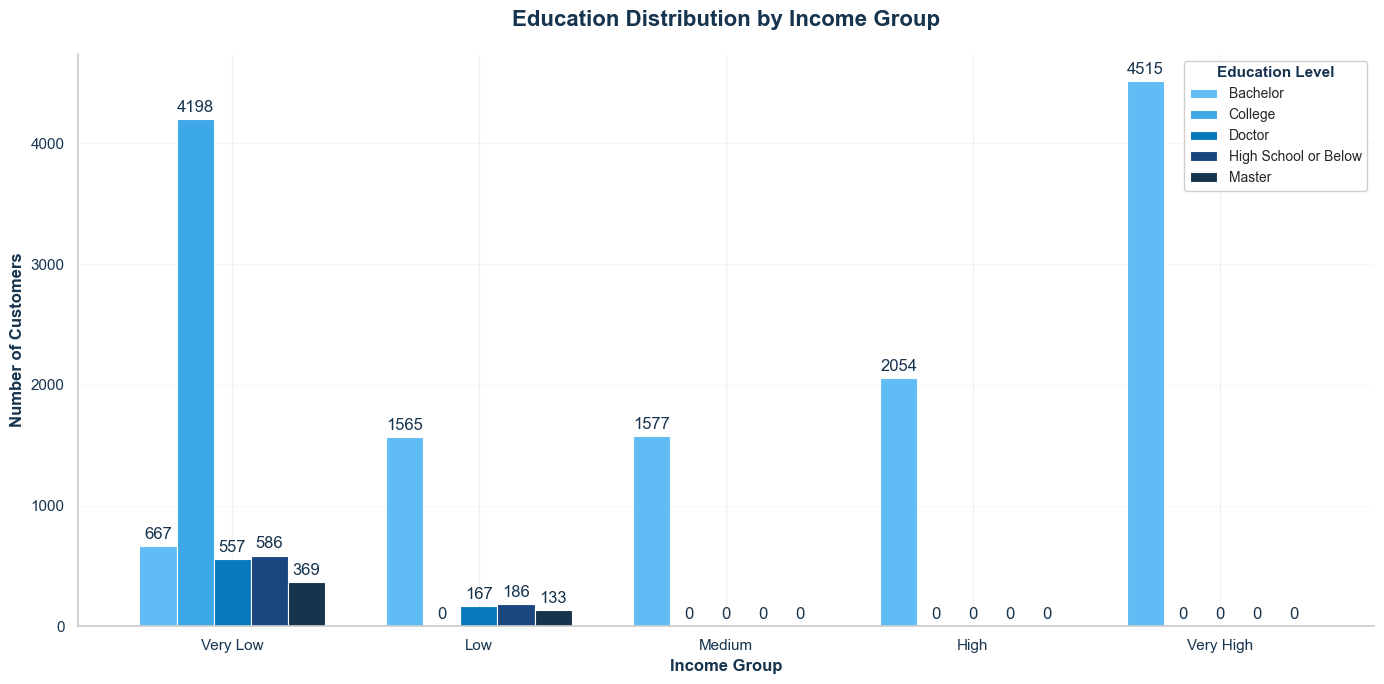

In [65]:
# Professional Business-Style Plot: Education Distribution by Income Group
fig, ax = plt.subplots(figsize=(14, 7))

# Business color palette
business_colors = ['#5fbcf4', '#3da8e8', '#0979bd', '#19467e', '#17344e']

# Create grouped bar chart
income_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
education_data = customers.groupby(['Income_Group', 'Education']).size().unstack(fill_value=0)
education_data = education_data.reindex(income_order)

# Plot bars
education_data.plot(
    kind='bar',
    ax=ax,
    color=business_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.75
)

# Styling
ax.set_title('Education Distribution by Income Group', 
             fontsize=16, fontweight='bold', color='#17344e', pad=20)
ax.set_xlabel('Income Group', fontsize=12, fontweight='semibold', color='#17344e')
ax.set_ylabel('Number of Customers', fontsize=12, fontweight='semibold', color='#17344e')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Grid styling
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5, color='#CCCCCC')
ax.set_axisbelow(True)

# Tick styling
ax.tick_params(colors='#17344e', labelsize=11)
ax.set_xticklabels(income_order, rotation=0, ha='center')

# Legend styling
legend = ax.legend(
    title='Education Level',
    title_fontsize=11,
    fontsize=10,
    loc='upper right',
    frameon=True,
    framealpha=0.95,
    edgecolor='#CCCCCC'
)
legend.get_title().set_color('#17344e')
legend.get_title().set_fontweight('semibold')

# Add value labels on bars (optional - can be removed if too cluttered)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', 
                 fontsize=12, padding=3, color='#17344e')

plt.tight_layout()
plt.show()

In [66]:
# Show some entries of customers with Education Doctor and filter for Income and Customer Lifetime Value

doctorate_customers = customers[customers['Education'] == 'Doctor']
doctorate_customers = doctorate_customers[['Income', 'Customer Lifetime Value', 'Income_Group']]
display(doctorate_customers.head())

,Income,Customer Lifetime Value,Income_Group
54,19245.0,3936.79,Very Low
59,18375.0,3954.34,Very Low
60,18375.0,3954.34,Very Low
61,18375.0,3954.34,Very Low
62,18375.0,3954.34,Very Low


### Education vs. Income: Initial Observation

The cross-tabulation of **education** and **income groups** shows an unexpected pattern: a relatively high share of customers with **higher education** appearing in the **very low** and **low** income segments, while income levels **above low** are predominantly associated with **Bachelor’s degrees**.

This contrasts with the commonly assumed positive association between education and income and suggests one or more of the following may be at play:
- **Sample or selection effects** (e.g., the airline’s customer mix or route network),
- **Measurement issues** (e.g., income reporting, currency, or time of observation),
- **Demographic structure** (e.g., early-career, student, or part-time populations).

Further analysis is required to understand whether this pattern reflects a true customer characteristic or stems from **data limitations** or **sampling bias**.


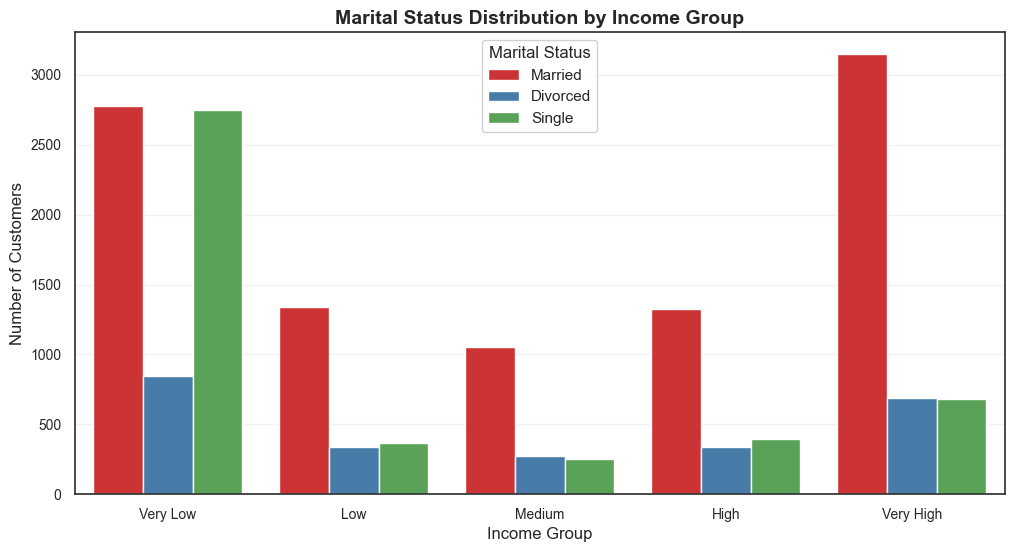

In [67]:
# Marital Status distribution per income group
plt.figure(figsize=(12, 6))
sns.countplot(
    data=customers,
    x='Income_Group',
    hue='Marital Status',
    order=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    palette='Set1',
)
plt.title('Marital Status Distribution by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Number of Customers')
plt.legend(title='Marital Status')
plt.show()

/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_83968/517441902.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clv_loyalty_counts = customers.groupby(['Income_Group', 'LoyaltyStatus']).size().unstack(fill_value=0)


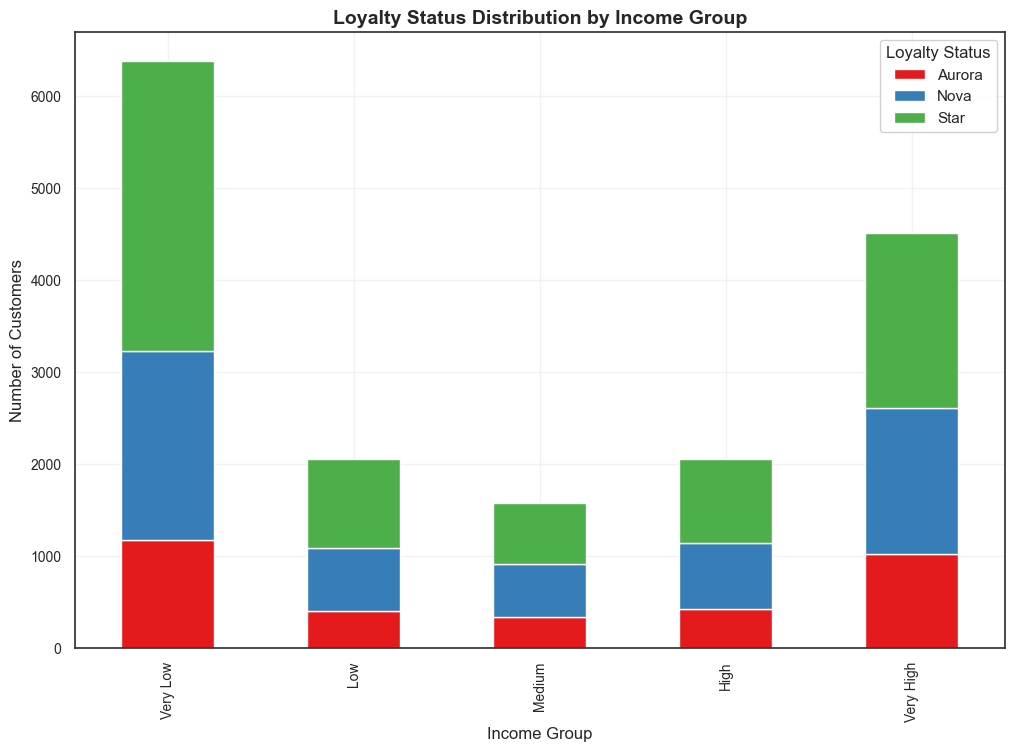

In [68]:
# Loyalty Status distribution per Income Group as a stacked bar chart 

#Color Palette
cat_order = customers["LoyaltyStatus"].value_counts().index.tolist()
palette_map, Set1 = make_palette_map(cat_order, palette_name="Set1", as_hex=False)


plt.figure(figsize=(12, 8))
clv_loyalty_counts = customers.groupby(['Income_Group', 'LoyaltyStatus']).size().unstack(fill_value=0)
clv_loyalty_counts.plot(kind='bar', stacked=True, ax=plt.gca(), color=Set1)
plt.title('Loyalty Status Distribution by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Number of Customers')
plt.legend(title='Loyalty Status')
plt.show()

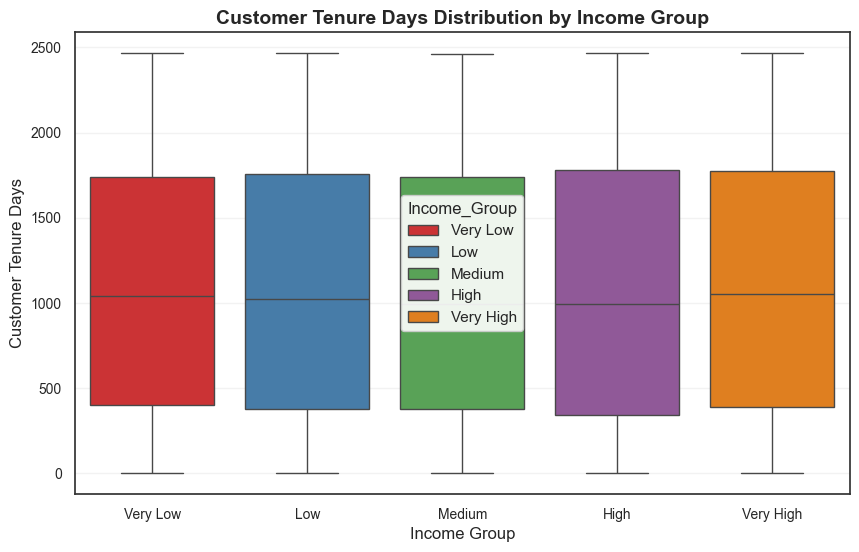

In [69]:
# Customer Tenure Days distribution per income group
# Filter out negative tenure days if any only for this plot
customers_tenure_days = customers[customers['CustomerTenureDays'] >= 0]
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=customers_tenure_days,
    x='Income_Group',
    y='CustomerTenureDays',
    order=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    palette='Set1', 
    hue='Income_Group',
)
plt.title('Customer Tenure Days Distribution by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Customer Tenure Days')
plt.show()

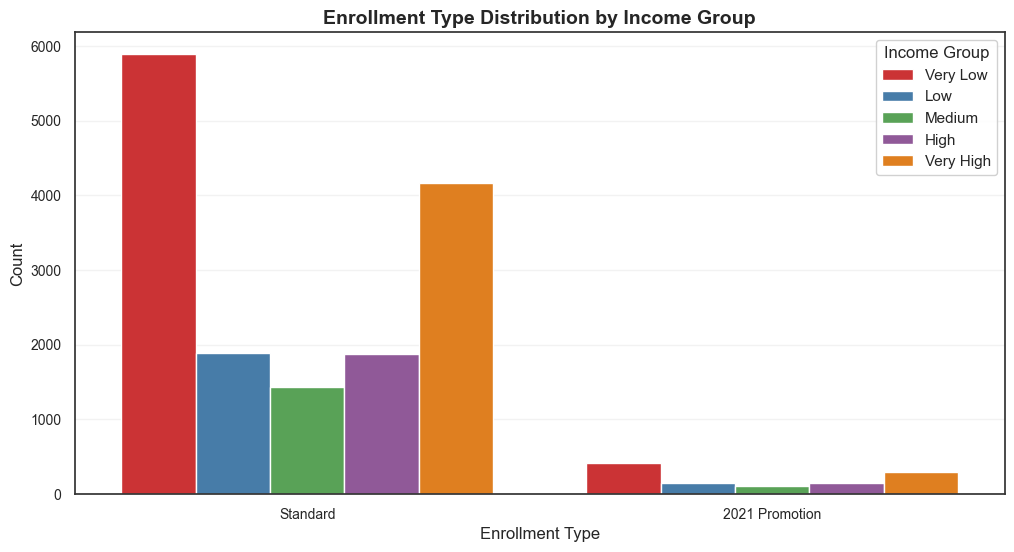

In [70]:
# Enrollment Type distribution per income group
plt.figure(figsize=(12, 6))
sns.countplot(  
    data=customers_tenure_days,
    x='EnrollmentType',
    hue='Income_Group',
    palette='Set1'
)
plt.title('Enrollment Type Distribution by Income Group')
plt.xlabel('Enrollment Type')
plt.ylabel('Count')
plt.legend(title='Income Group')
plt.show()

## 5.1.1 CLV-Based Segmentation  <a class="anchor" id="Customer Lifetime Value"></a>



Following the income analysis, we segment customers by **Customer Lifetime Value (CLV)**.  
We construct **CLV ranges using the distribution’s quartiles**, assigning each customer to a quartile-based band. This approach provides balanced groups and enables like-for-like comparisons across the value spectrum.

We then analyze feature distributions within these CLV segments to identify how customer characteristics and behaviors vary with **economic contribution over time**.


Customer Lifetime Value Quantiles:
0.2     3434.678
0.4     5119.900
0.6     7254.378
0.8    10179.720
Name: Customer Lifetime Value, dtype: float64


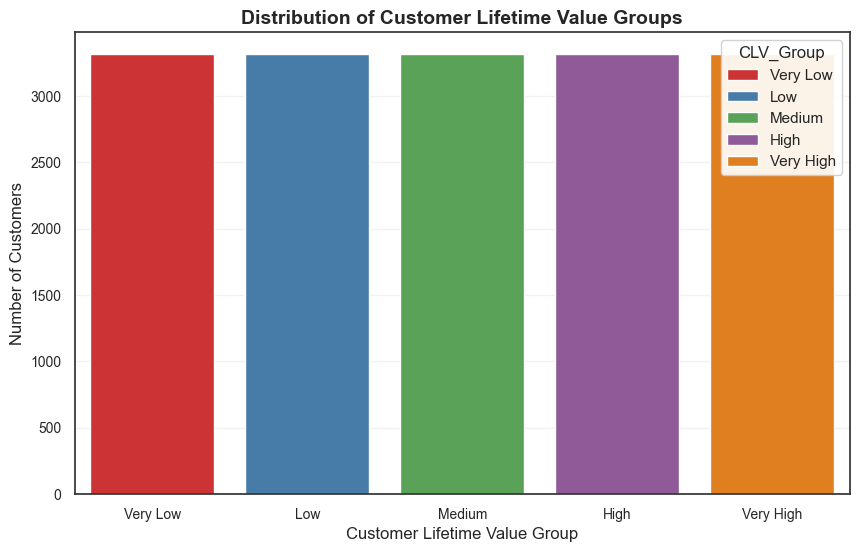

In [71]:
# Create a new column and groupBy CLV ranges
ranked_clv = customers['Customer Lifetime Value'].rank(method='first')  # bricht Ties deterministisch
customers['CLV_Group'] = pd.qcut(
    ranked_clv, q=5, labels=['Very Low','Low','Medium','High','Very High']
)

clv_distribution = customers['CLV_Group'].value_counts().sort_index()

# Print the quantile value of CLV_Group
clv_quantiles = customers['Customer Lifetime Value'].quantile([0.2, 0.4, 0.6, 0.8])
print("Customer Lifetime Value Quantiles:")
print(clv_quantiles)

# Plot the distribution of CLV_Group
plt.figure(figsize=(10, 6))
sns.countplot(data=customers, x='CLV_Group', order=['Very Low','Low','Medium','High','Very High'], palette='Set1', hue='CLV_Group')
plt.title('Distribution of Customer Lifetime Value Groups')
plt.xlabel('Customer Lifetime Value Group')
plt.ylabel('Number of Customers')
plt.show()


### Interpreting CLV-Grouped Distributions

Because **CLV groups** are constructed from **quartiles** (evenly sized bins), we expect more **balanced feature distributions** across segments. This reduces the impact of unequal group sizes and enables clearer, like-for-like comparisons of customer behavior by **lifetime value**.

This contrasts with the **income groups**, where segment sizes are **highly uneven**, and patterns may be driven partly by imbalance. Consequently, we anticipate **different—and more interpretable—patterns** in the CLV-based analysis.


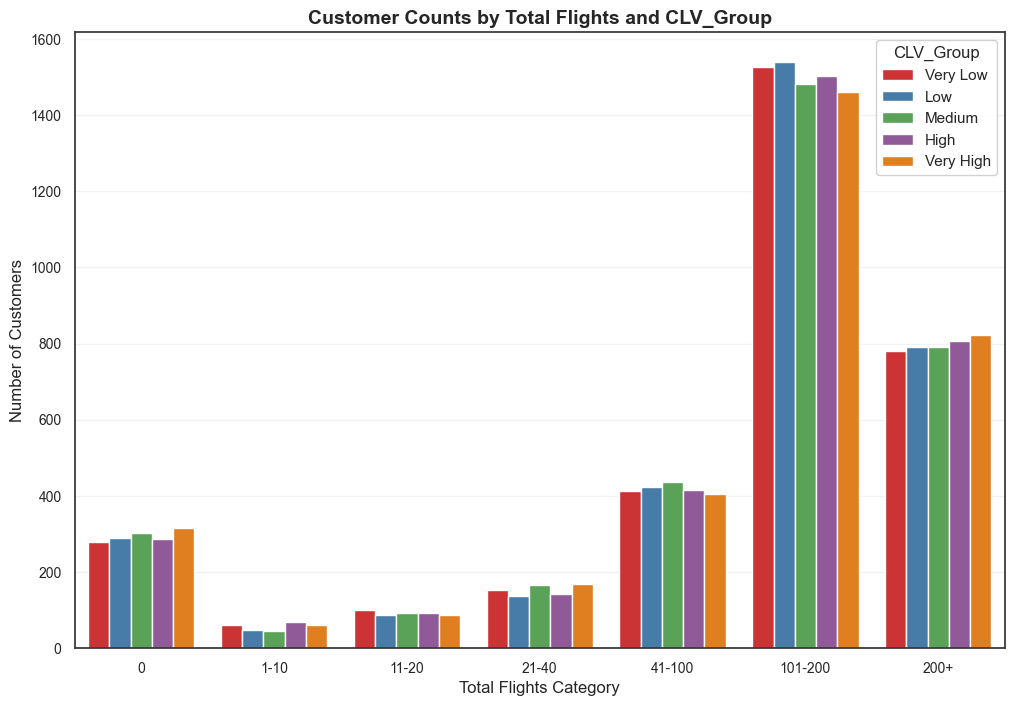

In [72]:
# Plot the following: Bar chart. Y-Axis counts the amount of customers. X-Axis is for the categories of total_flights. 
# The total flights categories are 0, 1-10, 10-20, 20-40, 41-100, 101-200, 200+.
# For every CLV_group, plot a separate bar chart with different colors.
plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    x=pd.cut(
        customers['total_flights'],
        bins=[0, 1, 11, 21, 41, 101, 201, float('inf')],
        labels=['0', '1-10', '11-20', '21-40', '41-100', '101-200', '200+'],
        right=False
    ),
    hue='CLV_Group',
    order=['0', '1-10', '11-20', '21-40', '41-100', '101-200', '200+'],
    palette='Set1',
)
plt.title('Customer Counts by Total Flights and CLV_Group')
plt.xlabel('Total Flights Category')
plt.ylabel('Number of Customers')
plt.legend(title='CLV_Group')
plt.show()


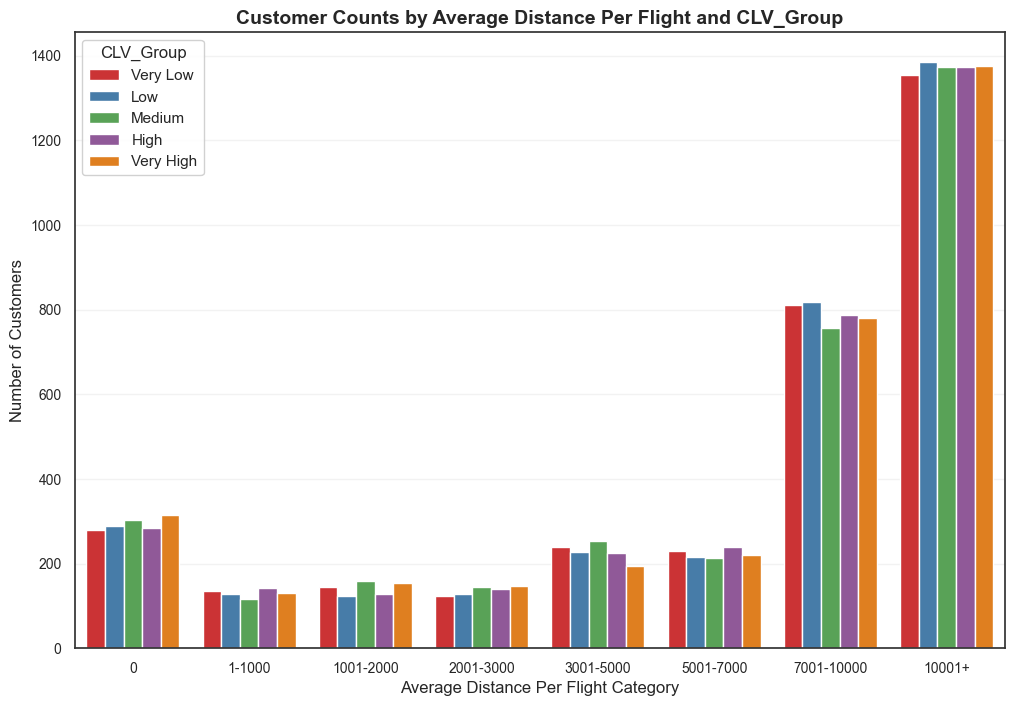

In [73]:
# Plot the following: Bar chart. Y-Axis counts the amount of customers. X-Axis is for the categories of average_distance.
# The average distance categories are 0, 1 - 1000, 1001 - 2000, 2001- 3000, 3001 - 5000, 5001 - 7000, 7001 - 10000, 10001+.
# For every CLV_Group, plot a separate bar chart with different colors.
plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    x=pd.cut(
        customers['average_distance_per_flight'],
        bins=[-1, 0, 1000, 2000, 3000, 5000, 7000, 10000, np.inf],
        labels=['0', '1-1000', '1001-2000', '2001-3000', '3001-5000', '5001-7000', '7001-10000', '10001+'],
                        right=True
    ),
    hue='CLV_Group',
    order=['0', '1-1000', '1001-2000', '2001-3000', '3001-5000', '5001-7000', '7001-10000', '10001+'],
    palette='Set1'
)
plt.title('Customer Counts by Average Distance Per Flight and CLV_Group')
plt.xlabel('Average Distance Per Flight Category')
plt.ylabel('Number of Customers')
plt.legend(title='CLV_Group')
plt.show()


/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_83968/799800730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


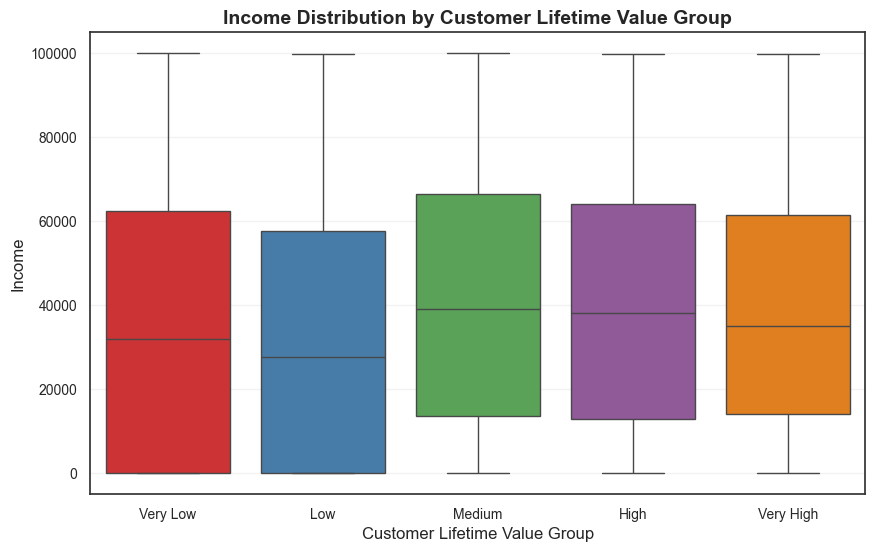

In [74]:
# Boxplot for every CLV_Group for Income
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=customers,
    x='CLV_Group',
    y='Income',
    order=['Very Low','Low','Medium','High','Very High'],
    palette='Set1'
)
plt.title('Income Distribution by Customer Lifetime Value Group')
plt.xlabel('Customer Lifetime Value Group')
plt.ylabel('Income')
plt.show()

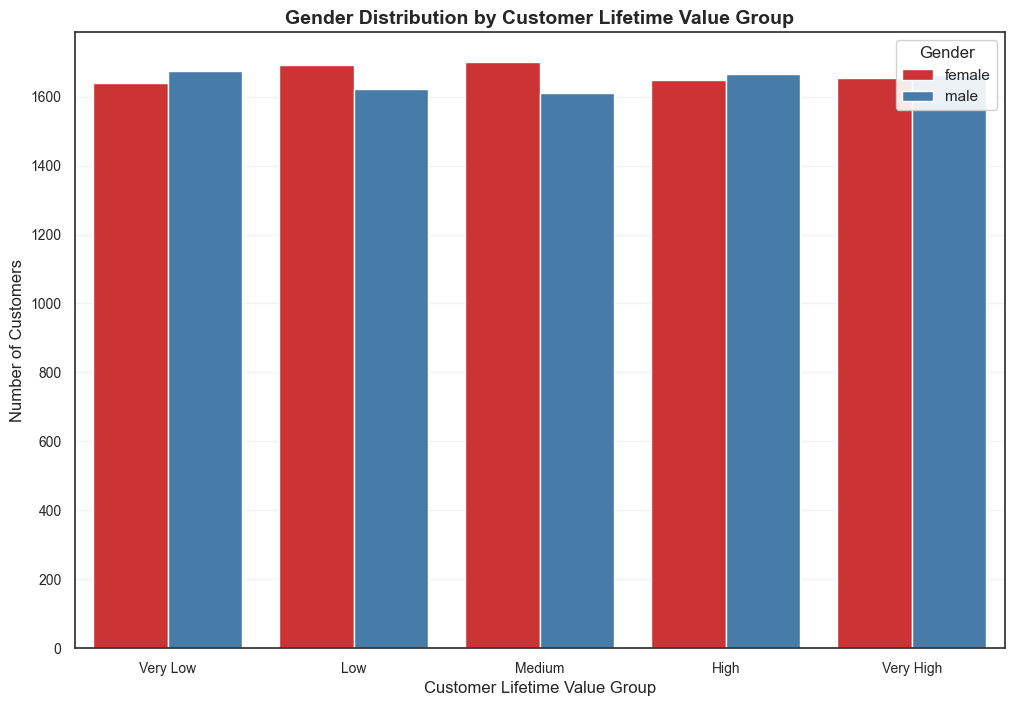

In [75]:
# Gender distribution per CLV_Group
plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    x='CLV_Group',
    hue='Gender',
    palette='Set1'
)
plt.title('Gender Distribution by Customer Lifetime Value Group')
plt.xlabel('Customer Lifetime Value Group')
plt.ylabel('Number of Customers')
plt.legend(title='Gender')
plt.show()


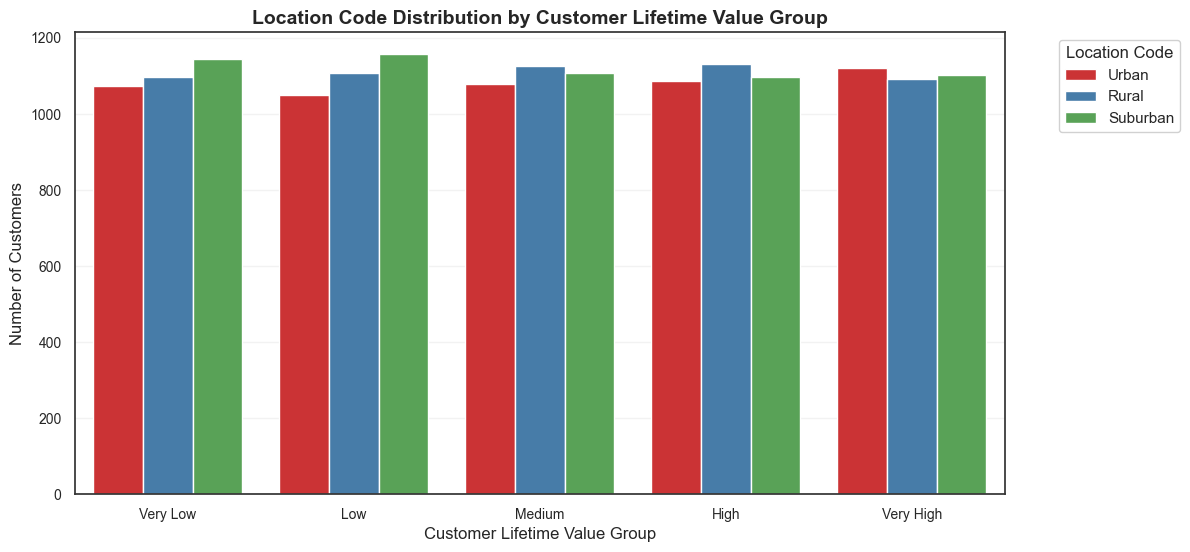

In [76]:
# Location Code distribution per CLV_Group
plt.figure(figsize=(12, 6))
sns.countplot(
    data=customers,
    x='CLV_Group',
    hue='Location Code',
    order=['Very Low','Low','Medium','High','Very High'],
    palette='Set1'
)
plt.title('Location Code Distribution by Customer Lifetime Value Group')
plt.xlabel('Customer Lifetime Value Group')
plt.ylabel('Number of Customers')
plt.legend(title='Location Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

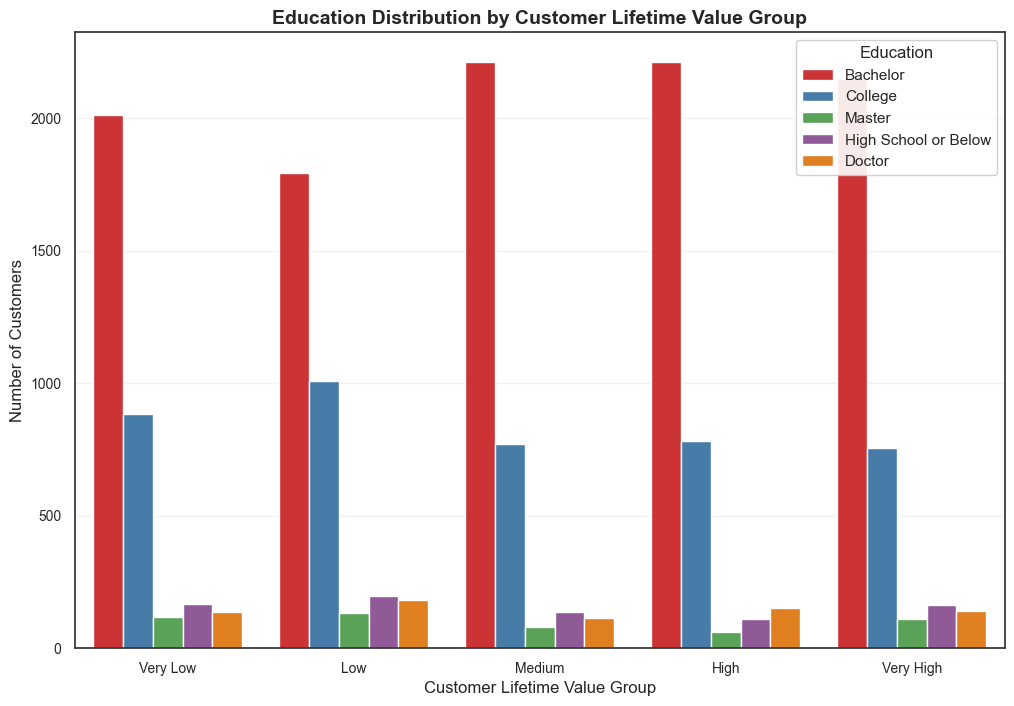

In [77]:
# Education distribution per CLV_Group
plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    x='CLV_Group',
    hue='Education',
    palette='Set1'
)
plt.title('Education Distribution by Customer Lifetime Value Group')
plt.xlabel('Customer Lifetime Value Group')
plt.ylabel('Number of Customers')
plt.legend(title='Education')
plt.show()


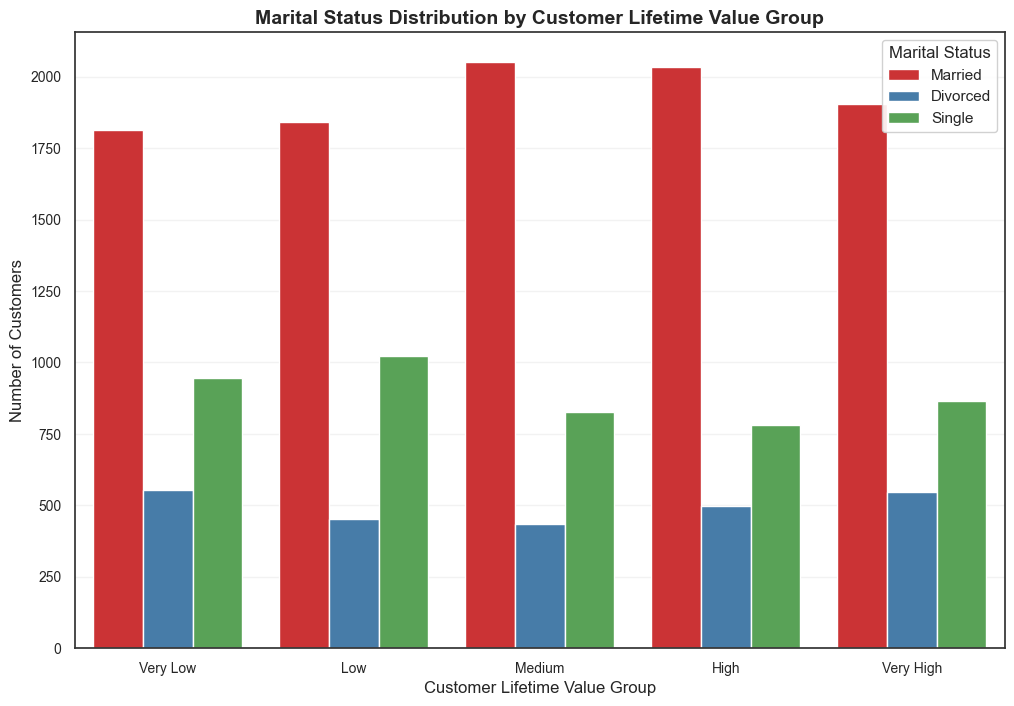

In [78]:
# Marital Status distribution per CLV_Group
plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    x='CLV_Group',
    hue='Marital Status',
    palette='Set1'
)
plt.title('Marital Status Distribution by Customer Lifetime Value Group')
plt.xlabel('Customer Lifetime Value Group')
plt.ylabel('Number of Customers')
plt.legend(title='Marital Status')
plt.show()


/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_83968/194846967.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clv_loyalty_counts = customers.groupby(['CLV_Group', 'LoyaltyStatus']).size().unstack(fill_value=0)


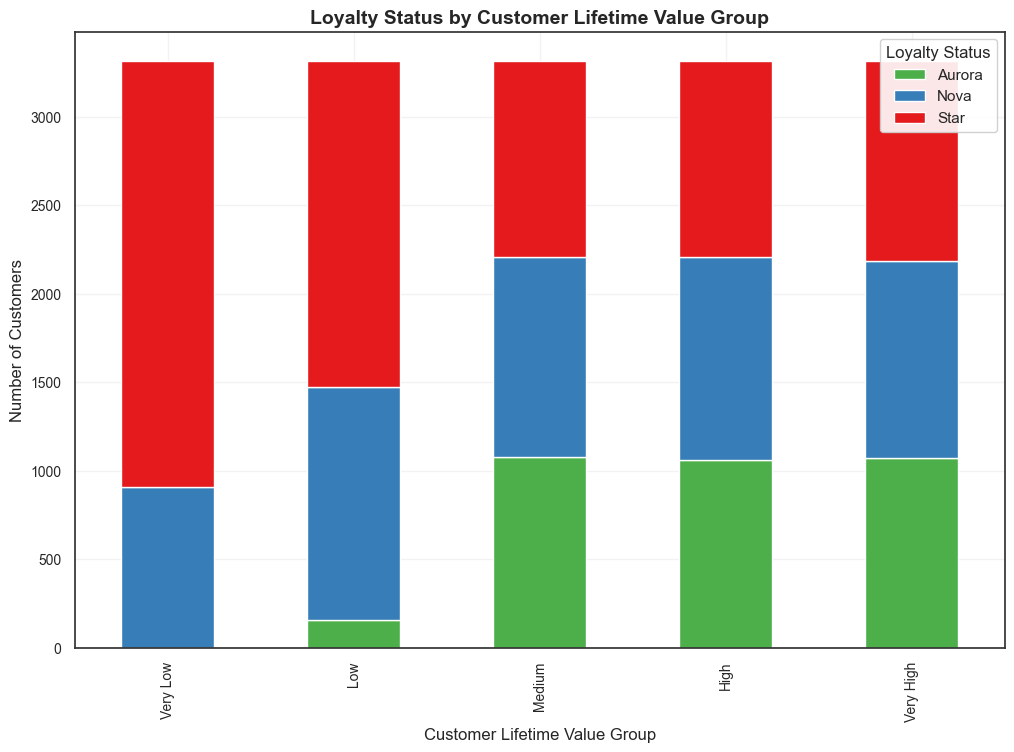

In [79]:
# Loyalty Status distribution per CLV_Group as a stacked bar chart 

#Color Palette
cat_order = customers["LoyaltyStatus"].value_counts().index.tolist()
palette_map, Set1 = make_palette_map(cat_order, palette_name="Set1", as_hex=False)

plt.figure(figsize=(12, 8))
clv_loyalty_counts = customers.groupby(['CLV_Group', 'LoyaltyStatus']).size().unstack(fill_value=0)
clv_loyalty_counts.plot(kind='bar', stacked=True, ax=plt.gca(), color=palette_map)
plt.title('Loyalty Status by Customer Lifetime Value Group')
plt.xlabel('Customer Lifetime Value Group')
plt.ylabel('Number of Customers')
plt.legend(title='Loyalty Status')
plt.show()

### Loyalty Status by CLV Group — Key Observations

- **Expected pattern overall:** Customers with **higher CLV** are more likely to hold the **Aurora** loyalty status. Representation is **minimal** in the **Very Low** and **Low** CLV groups and **concentrated** from **Medium** through **Very High**, consistent with programs that reward sustained value.

- **Notable nuance:** The **relative share** of Aurora status appears **similar across Medium, High, and Very High** CLV groups rather than peaking in the Very High segment.  
  This suggests that factors **beyond CLV**—such as tenure, flight frequency patterns, fare class mix, or program rules—may materially influence status attainment.

**Implication:** While the loyalty program aligns with value creation at a high level, the **plateau in Aurora share** among upper CLV tiers indicates potential **non-linear qualification dynamics** or **additional criteria** affecting status distribution.


/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_83968/3612926883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


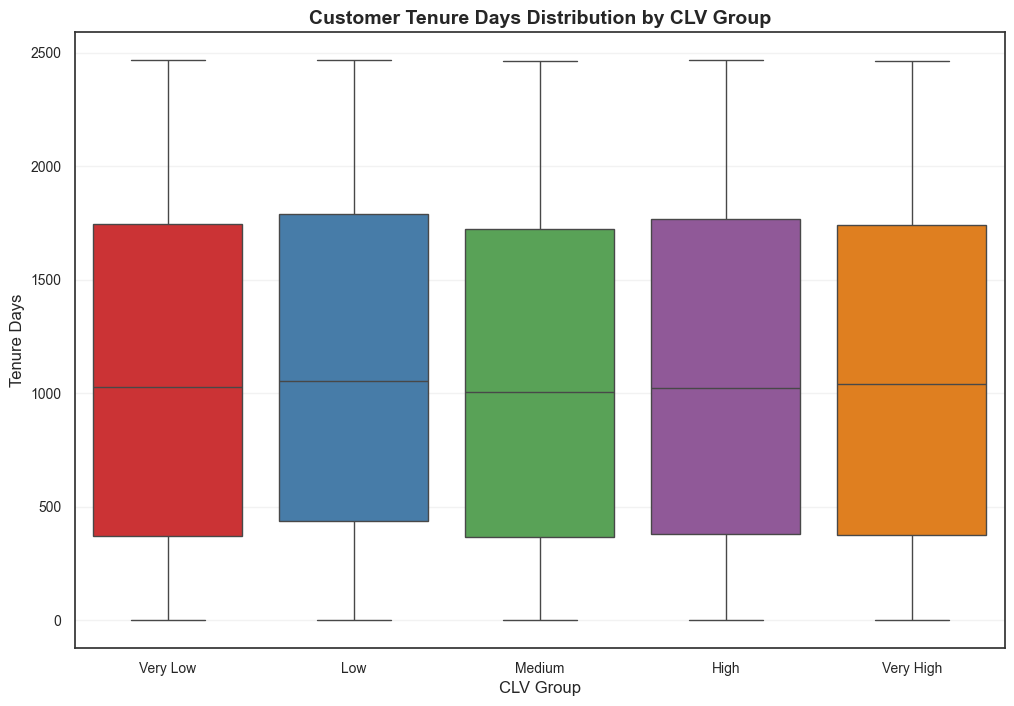

In [80]:
# Customer Tenure Days distribution per CLV_Group
# Filter out negative tenure days if any only for this plot
tenure_customers = customers[customers['CustomerTenureDays'] >= 0]
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=tenure_customers,
    x='CLV_Group',
    y='CustomerTenureDays',
    palette='Set1'
)
plt.title('Customer Tenure Days Distribution by CLV Group')
plt.xlabel('CLV Group')
plt.ylabel('Tenure Days')
plt.show()

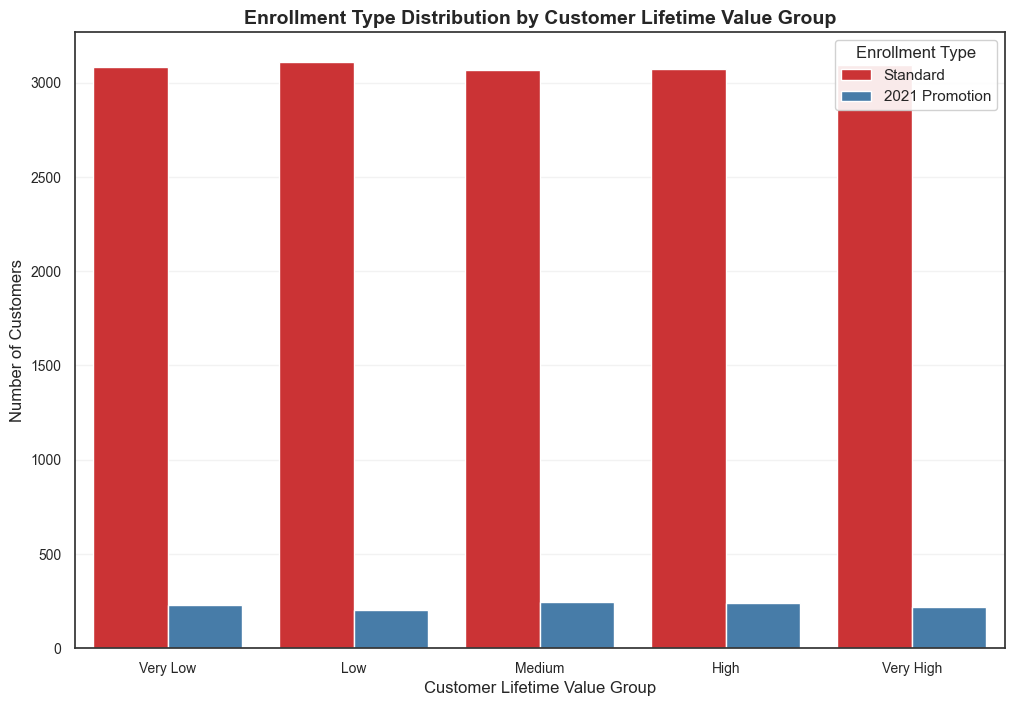

In [81]:
# Enrollment Type distribution per CLV_Group
plt.figure(figsize=(12, 8))
sns.countplot(  
    data=customers,
    x='CLV_Group',
    hue='EnrollmentType',
    palette='Set1'
)
plt.title('Enrollment Type Distribution by Customer Lifetime Value Group')
plt.xlabel('Customer Lifetime Value Group')
plt.ylabel('Number of Customers')
plt.legend(title='Enrollment Type')
plt.show()  

## 5.1.3 Linking Income and CLV <a class="anchor" id="Customer Lifetime Value"></a>



Having examined **Income Groups** and **CLV Groups** separately, we now analyze their **joint relationship**.  
We construct a **cross-tabulation** of Income Group × CLV Group to assess how income levels align with lifetime value, and visualize the results using:

- a **heatmap** to highlight concentration patterns, and  
- **bar charts** to compare segment shares across groups.

This combined view helps reveal whether higher income translates into higher CLV, and where notable deviations from that expectation occur.


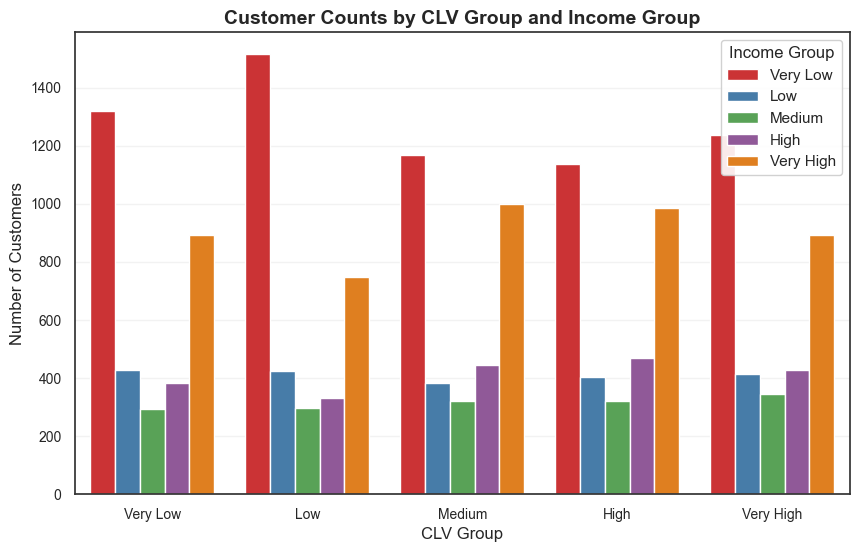

In [82]:
# CLV_Group und Income Group Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(
    data=customers,
    x='CLV_Group',
    hue='Income_Group',
    order=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    palette="Set1"
)
plt.title('Customer Counts by CLV Group and Income Group')
plt.xlabel('CLV Group')
plt.ylabel('Number of Customers')
plt.legend(title='Income Group')
plt.show()

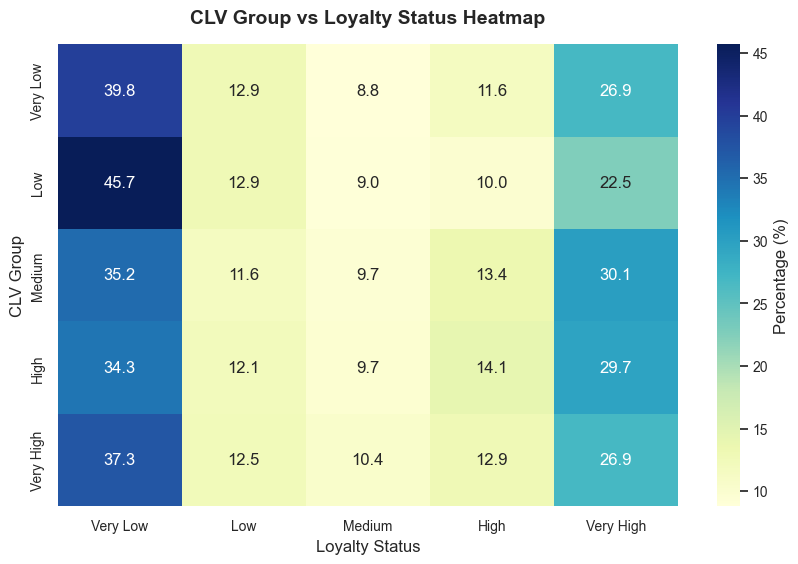

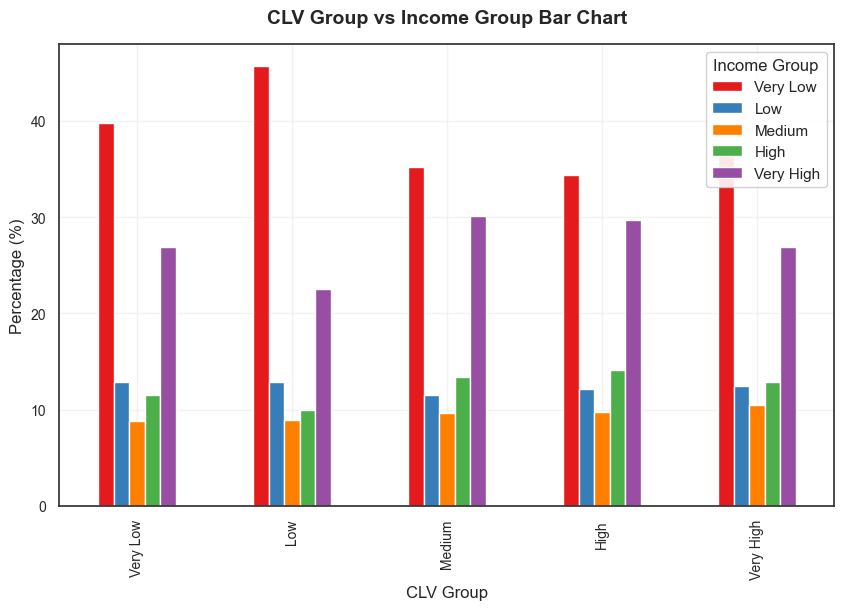

In [83]:
# Crosstable of CLV_Group and Income_Group
clv_income_crosstab = pd.crosstab(customers['CLV_Group'], customers['Income_Group'], normalize='index') * 100

# Visualisation as Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    clv_income_crosstab,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Percentage (%)"}
)
plt.title("CLV Group vs Loyalty Status Heatmap", fontsize=14, pad=15)
plt.xlabel("Loyalty Status")
plt.ylabel("CLV Group")
plt.show()

#Color Palette
cat_order = customers["CLV_Group"].value_counts().index.tolist()
palette_map, Set1 = make_palette_map(cat_order, palette_name="Set1", as_hex=False)

# Visualisation as as Bar Chart
clv_income_crosstab.plot(kind='bar', figsize=(10, 6), color=palette_map)
plt.title("CLV Group vs Income Group Bar Chart", fontsize=14, pad=15)
plt.xlabel("CLV Group")
plt.ylabel("Percentage (%)")
plt.legend(title='Income Group')
plt.show()

## 5.2 Behavioral Segmentation    <a class="anchor" id="Flights-EDA"></a>


In this section, we explore **Behavioral Segmentation**, focusing on customer activity patterns and travel behavior over time.  
This includes examining **monthly flight behavior** and other activity-based indicators to uncover trends, seasonality, or engagement differences that may characterize distinct behavioral profiles within the customer base.


### Seasonal Analysis: Flights by Year and Month

We begin with a **seasonality** check by plotting the **monthly number of flights** with separate lines for each **calendar year**.  
This allows us to compare **intra-annual patterns** (seasonal peaks and troughs) and identify **year-over-year differences**, such as shifts in demand, anomalous months, or changes in trend magnitude across years.


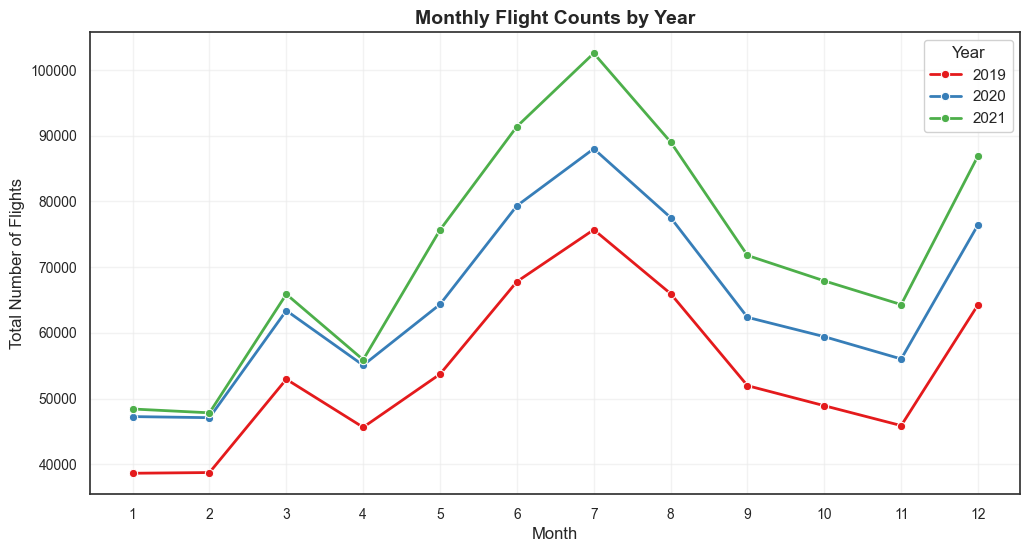

In [84]:
# Count the NumFlights per Month for each year 
monthly_flight_counts = flights.groupby(['Year', 'Month'])['NumFlights'].sum().reset_index()

# Plot the monthly flight counts for each year
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_flight_counts,
    x='Month',
    y='NumFlights',
    hue='Year',
    marker='o',
    palette='Set1'
)
plt.title('Monthly Flight Counts by Year')
plt.xlabel('Month')
plt.ylabel('Total Number of Flights')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.show()


### Business-Ready Visualization Variant

As with previous sections, we create a **business-oriented version** of the seasonal analysis plot.  
This version focuses on **visual clarity and presentation quality**, ensuring it can be directly used in reports or stakeholder presentations. While the analytical plot emphasizes detail and exploration, this refined design enhances **readability and executive communication**.


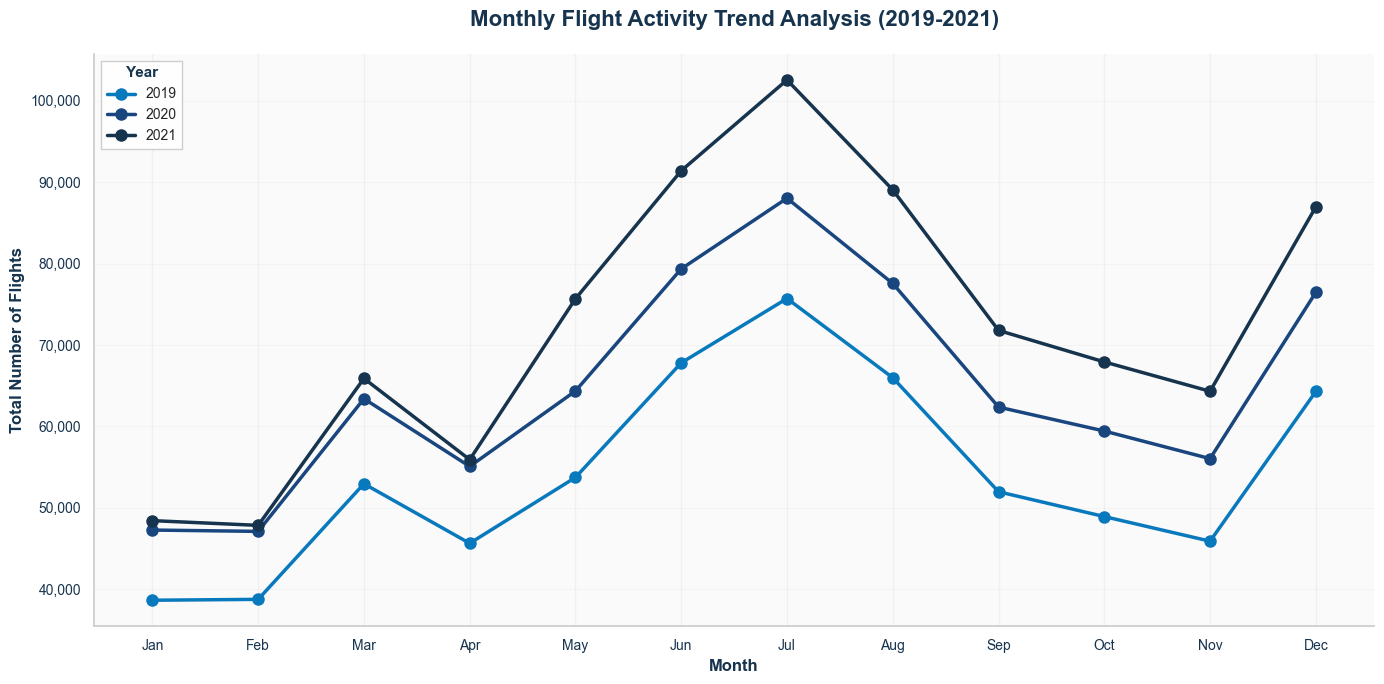

In [85]:
# Count the NumFlights per Month for each year 
monthly_flight_counts = flights.groupby(['Year', 'Month'])['NumFlights'].sum().reset_index()

# Professional Business-Style Plot: Monthly Flight Counts by Year
fig, ax = plt.subplots(figsize=(14, 7))

# Business color palette (matching your corporate design)
business_colors = ['#0979bd', '#19467e', '#17344e']
year_colors = {2019: business_colors[0], 2020: business_colors[1], 2021: business_colors[2]}

# Plot line for each year with markers
for year in sorted(monthly_flight_counts['Year'].unique()):
    year_data = monthly_flight_counts[monthly_flight_counts['Year'] == year]
    ax.plot(
        year_data['Month'],
        year_data['NumFlights'],
        marker='o',
        linewidth=2.5,
        markersize=8,
        color=year_colors[year],
        label=str(year),
        zorder=3
    )

# Styling
ax.set_title('Monthly Flight Activity Trend Analysis (2019-2021)', 
             fontsize=16, fontweight='bold', color='#17344e', pad=20)
ax.set_xlabel('Month', fontsize=12, fontweight='semibold', color='#17344e')
ax.set_ylabel('Total Number of Flights', fontsize=12, fontweight='semibold', color='#17344e')

# X-axis: Month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=10, color='#17344e')

# Y-axis styling with thousand separators
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.tick_params(axis='y', labelsize=10, colors='#17344e')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Subtle grid
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)

# Legend styling
legend = ax.legend(
    title='Year',
    title_fontsize=11,
    fontsize=10,
    loc='upper left',
    frameon=True,
    framealpha=0.95,
    edgecolor='#CCCCCC',
    fancybox=False
)
legend.get_title().set_color('#17344e')
legend.get_title().set_fontweight('semibold')

# Add subtle background color
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.show()

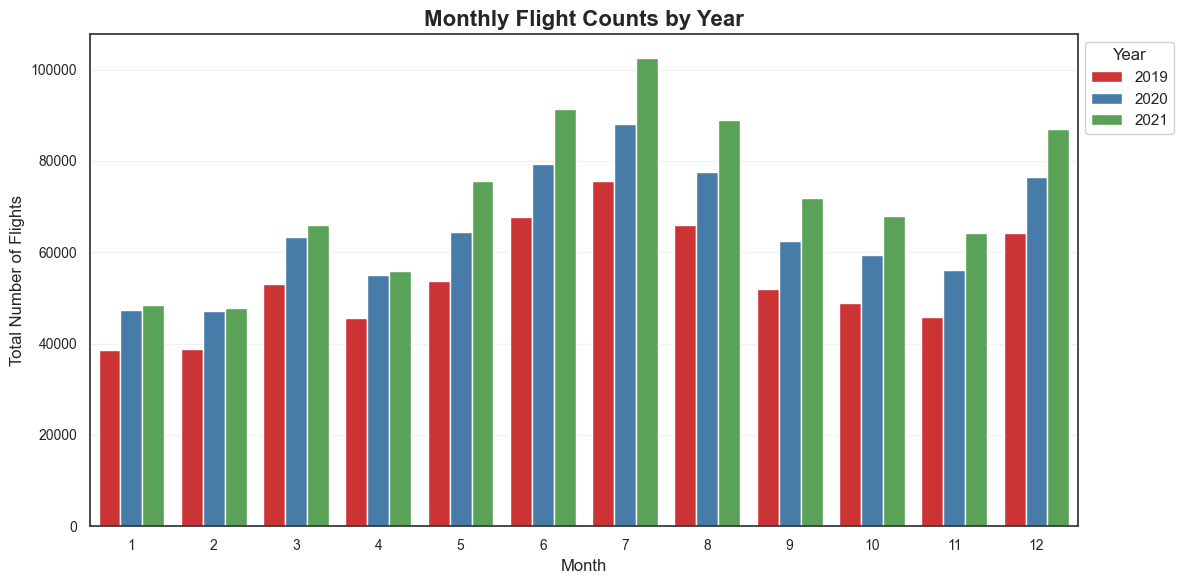

In [86]:
# Count the NumFlights per Month for each year 
monthly_flight_counts = (
    flights.groupby(['Year', 'Month'])['NumFlights']
    .sum()
    .reset_index()
    .sort_values(['Year', 'Month'])
)

# --- Plot: Grouped Bar Chart ---
plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_flight_counts,
    x='Month',
    y='NumFlights',
    hue='Year',
    palette='Set1'
)


plt.title('Monthly Flight Counts by Year', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Number of Flights')
plt.xticks(range(0, 12), [str(i+1) for i in range(12)])  # months 1–12
plt.legend(title='Year', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


### Seasonal Aggregation

To gain a clearer overview of travel patterns, we aggregate **monthly flight data** into **four seasonal categories** — *Winter, Spring, Summer,* and *Autumn*.  
This aggregation smooths short-term fluctuations and highlights broader **seasonal trends** in customer flight activity throughout the year.


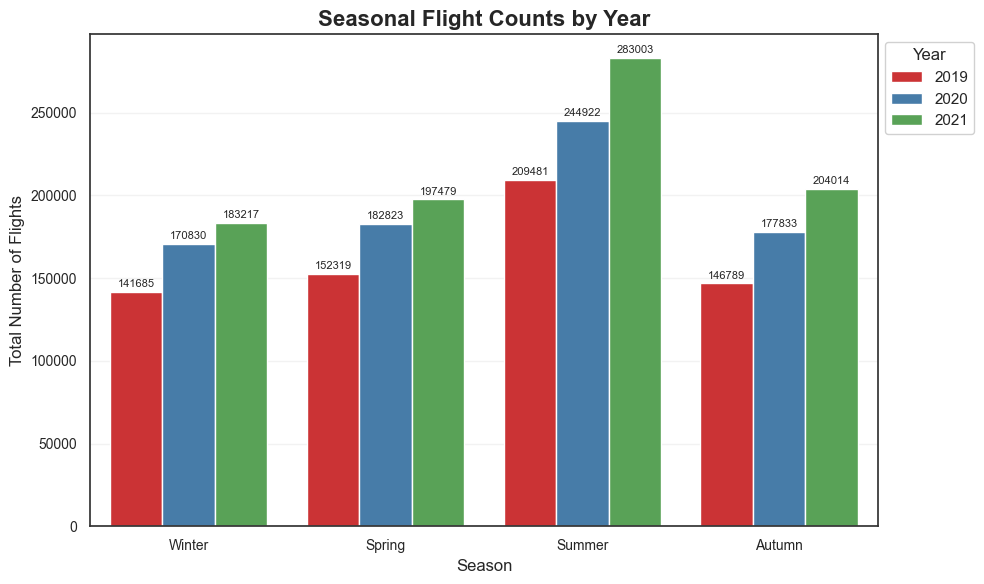

In [87]:
# Count the NumFlights per Season for each year
seasonal_flight_counts = (
    flights.groupby(['Year', 'Season'])['NumFlights']
    .sum()
    .reset_index()
    .sort_values(['Year', 'Season'])
)

# Define season order (optional, to keep logical order)
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

# --- Plot: Grouped Bar Chart by Season ---
plt.figure(figsize=(10, 6))

sns.barplot(
    data=seasonal_flight_counts,
    x='Season',
    y='NumFlights',
    hue='Year',
    palette='Set1',
    order=season_order
)

# Add small value labels on top of bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', label_type='edge', fontsize=8, padding=2)

plt.title('Seasonal Flight Counts by Year', fontsize=16, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Total Number of Flights')
plt.legend(title='Year', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


### Companion Type by Season

To further understand customer travel behavior, we analyze the **distribution of solo and companion flights across seasons**.  
This comparison reveals how travel companionship patterns vary throughout the year and whether customers tend to travel more alone or with others during specific periods.

We visualize this relationship using two complementary views:

- **Grouped Bar Chart:** shows the total number of solo and companion flights per season, enabling direct volume comparison.  
- **100% Stacked Bar Chart:** presents the relative share of each travel type per season, offering a normalized perspective that highlights proportional differences.

Together, these visualizations provide a balanced view of both **absolute flight activity** and **relative behavioral trends** across seasons.


/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_83968/3665504928.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Season')[['SoloFlights', comp_col]]


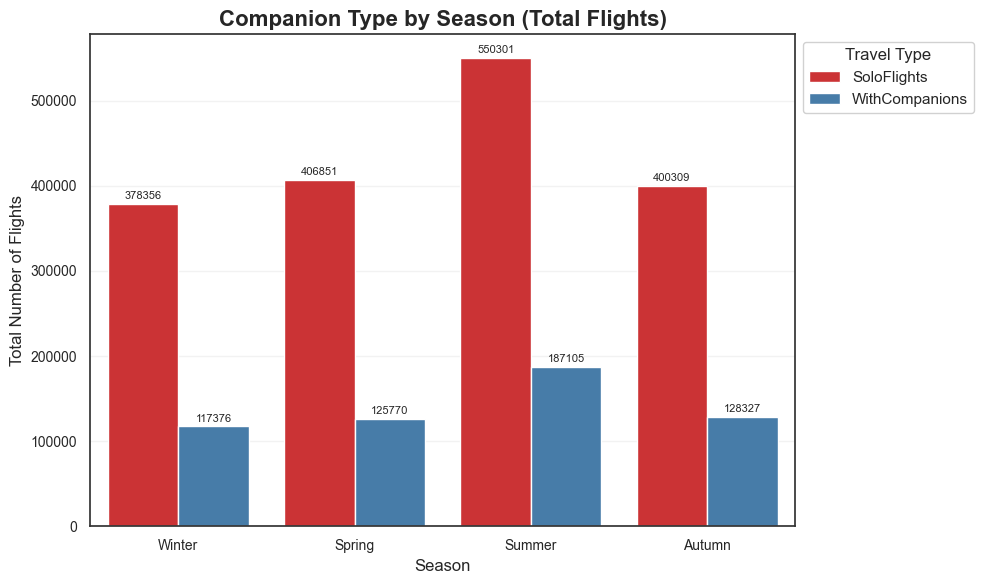

In [88]:
# --- Companion Type per Season (Grouped Bars) ---

# 1) Identify the companion-flights column in `flights`
companion_candidates = [
    'NumFlightsWithCompanions',
    'FlightsWithCompanions',
    'NumCompanionFlights',
    'Flights_Companion',
    'total_flights_with_companions'  # if flights already has a pre-aggregated field
]
comp_col = None
for c in companion_candidates:
    if c in flights.columns:
        comp_col = c
        break

if comp_col is None:
    raise ValueError(
        "No 'companion flights' column found. "
        "Add one of the expected columns to `flights` (e.g., 'NumFlightsWithCompanions')."
    )

# 2) Prepare data
df_season = flights.copy()
if 'NumFlights' not in df_season.columns:
    raise ValueError("Expected 'NumFlights' column not found in `flights`.")

df_season['SoloFlights'] = df_season['NumFlights'] - df_season[comp_col]
df_season['SoloFlights'] = df_season['SoloFlights'].clip(lower=0)  # guard against negatives

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
df_season['Season'] = pd.Categorical(df_season['Season'], season_order, ordered=True)

season_totals = (
    df_season
    .groupby('Season')[['SoloFlights', comp_col]]
    .sum()
    .reset_index()
    .rename(columns={comp_col: 'WithCompanions'})
)

melted = season_totals.melt(
    id_vars='Season',
    value_vars=['SoloFlights', 'WithCompanions'],
    var_name='Travel Type',
    value_name='Flights'
)

# 3) Plot grouped bars
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=melted,
    x='Season',
    y='Flights',
    hue='Travel Type',
    palette=sns.color_palette("Set1", 2),
    order=season_order
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8, padding=2)

plt.title('Companion Type by Season (Total Flights)', fontsize=16, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Total Number of Flights')
plt.legend(title='Travel Type', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


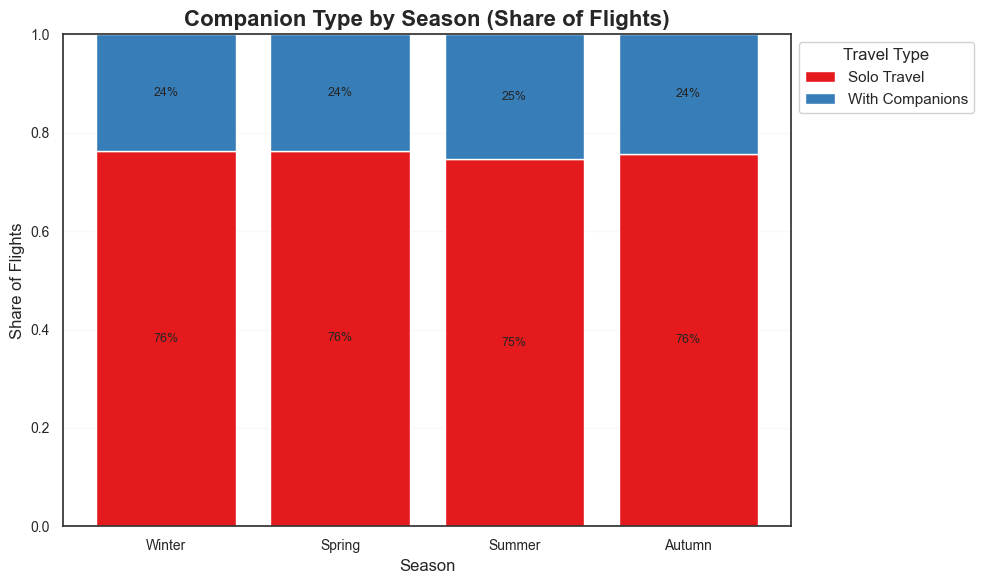

In [89]:
# --- Companion Type per Season (100% Stacked Shares) ---

share = season_totals.copy()
share['Total'] = share['SoloFlights'] + share['WithCompanions']
# Avoid division by zero
share['SoloShare'] = np.where(share['Total'] > 0, share['SoloFlights'] / share['Total'], 0.0)
share['CompShare'] = np.where(share['Total'] > 0, share['WithCompanions'] / share['Total'], 0.0)

# Plot 100% stacked bars with matplotlib
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(season_order))
solo = share.set_index('Season').loc[season_order, 'SoloShare'].values
comp = share.set_index('Season').loc[season_order, 'CompShare'].values

bars1 = ax.bar(x, solo, label='Solo Travel', color=sns.color_palette("Set1", 2)[0])
bars2 = ax.bar(x, comp, bottom=solo, label='With Companions', color=sns.color_palette("Set1", 2)[1])

ax.set_xticks(x)
ax.set_xticklabels(season_order)
ax.set_ylim(0, 1)
ax.set_ylabel('Share of Flights')
ax.set_xlabel('Season')
ax.set_title('Companion Type by Season (Share of Flights)', fontsize=16, fontweight='bold')

# Optional: percentage labels
for b in bars1:
    height = b.get_height()
    if height > 0.03:
        ax.text(b.get_x() + b.get_width()/2, height/2, f"{height*100:.0f}%", ha='center', va='center', fontsize=9)

for b1, b2 in zip(bars1, bars2):
    bottom = b1.get_height()
    height = b2.get_height()
    if height > 0.03:
        ax.text(b2.get_x() + b2.get_width()/2, bottom + height/2, f"{height*100:.0f}%", ha='center', va='center', fontsize=9)

ax.legend(title='Travel Type', loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Companion Type by Loyalty Status — Grouped View

This visualization compares the **total number of flights** by **Companion Type** (Solo vs. With Companions) across different **Loyalty Status** levels.  
By displaying grouped bars, it allows for a **direct comparison within each loyalty tier**, helping identify whether higher-status customers tend to travel more independently or accompanied.  
This view emphasizes **absolute differences** in flight activity and highlights variations in travel behavior among loyalty segments.


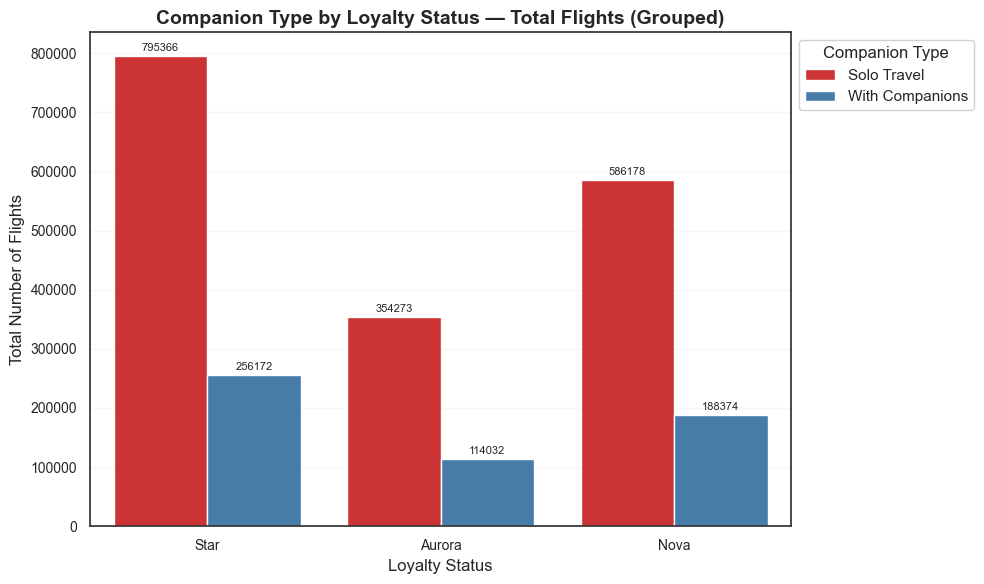

In [90]:
# --- Companion Type by Loyalty Status: Grouped & Stacked (Total Flights) ---


# -----------------------------
# 1) Prepare data
# -----------------------------
# Guard: required columns
required_cols = {'LoyaltyStatus', 'total_flights', 'total_flights_with_companions'}
missing = required_cols - set(customers.columns)
if missing:
    raise KeyError(f"Missing required columns in `customers`: {missing}")

# Compute SoloFlights (no negatives)
customers = customers.copy()
customers['SoloFlights'] = (customers['total_flights'] - customers['total_flights_with_companions']).clip(lower=0)

# Aggregate to loyalty status
df_solo_companion = (
    customers
    .groupby('LoyaltyStatus', as_index=False)[['SoloFlights', 'total_flights_with_companions']]
    .sum()
    .rename(columns={'total_flights_with_companions': 'WithCompanions'})
)

# Order loyalty levels
loyalty_order = ['Star', 'Aurora', 'Nova']
df_solo_companion['LoyaltyStatus'] = pd.Categorical(df_solo_companion['LoyaltyStatus'],
                                                    categories=loyalty_order, ordered=True)
df_solo_companion = df_solo_companion.sort_values('LoyaltyStatus')

# Long form for grouped chart
melted = df_solo_companion.melt(
    id_vars='LoyaltyStatus',
    value_vars=['SoloFlights', 'WithCompanions'],
    var_name='Companion Type',
    value_name='Total Flights'
)

# Label map for legend
label_map = {'SoloFlights': 'Solo Travel', 'WithCompanions': 'With Companions'}
melted['Companion Type'] = melted['Companion Type'].map(label_map)

# Palette (Set1)
palette = sns.color_palette("Set1", 2)
palette_map = {'Solo Travel': palette[0], 'With Companions': palette[1]}


# -----------------------------
# 2) Grouped (Unstacked) Bar Chart
# -----------------------------
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=melted,
    x='LoyaltyStatus',
    y='Total Flights',
    hue='Companion Type',
    hue_order=['Solo Travel', 'With Companions'],
    palette=[palette_map['Solo Travel'], palette_map['With Companions']]
)

# Value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8, padding=2)

ax.set_title('Companion Type by Loyalty Status — Total Flights (Grouped)', fontsize=14, fontweight='bold')
ax.set_xlabel('Loyalty Status')
ax.set_ylabel('Total Number of Flights')
ax.grid(axis='y', alpha=0.4)
ax.legend(title='Companion Type', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


### Companion Type by Loyalty Status — Stacked View

The stacked bar chart presents the same relationship as the grouped view but focuses on the **composition of total flights** within each **Loyalty Status**.  
By stacking Solo and Companion flights, this visualization highlights the **proportion of each travel type** within the total volume, offering a clearer picture of how customer travel patterns differ structurally between loyalty tiers.  
Together with the grouped view, it provides a **complementary perspective**—combining both absolute and relative insights into customer travel behavior.


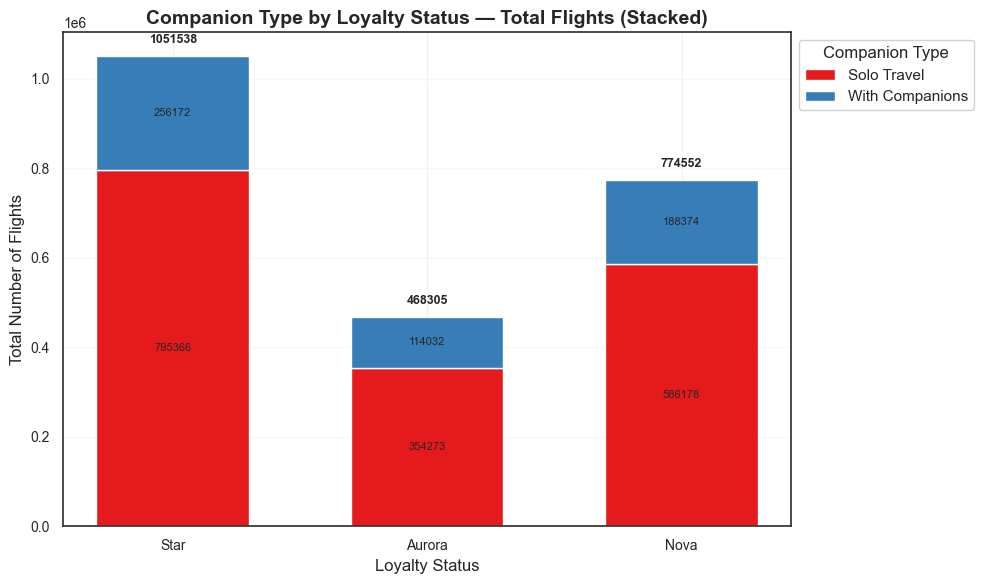

In [91]:

# -----------------------------
# 3) Stacked Bar Chart (Totals)
# -----------------------------
# Pivot to wide for stacking
wide = (
    df_solo_companion
    .set_index('LoyaltyStatus')[['SoloFlights', 'WithCompanions']]
    .rename(columns={'SoloFlights': 'Solo Travel', 'WithCompanions': 'With Companions'})
)

x = np.arange(len(wide.index))
width = 0.6

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x, wide['Solo Travel'].values, width, label='Solo Travel', color=palette_map['Solo Travel'])
bars2 = ax.bar(x, wide['With Companions'].values, width, bottom=wide['Solo Travel'].values,
               label='With Companions', color=palette_map['With Companions'])

# X ticks / labels
ax.set_xticks(x)
ax.set_xticklabels(wide.index)

# Value labels per segment
def add_bar_labels(bars):
    for b in bars:
        h = b.get_height()
        if h > 0:
            ax.text(b.get_x() + b.get_width()/2, b.get_y() + h/2, f"{int(h):d}",
                    ha='center', va='center', fontsize=8)

add_bar_labels(bars1)
add_bar_labels(bars2)

# Optional: show total on top
totals = wide.sum(axis=1).values
for xi, total in zip(x, totals):
    ax.text(xi, total + max(totals)*0.02, f"{int(total):d}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Companion Type by Loyalty Status — Total Flights (Stacked)', fontsize=14, fontweight='bold')
ax.set_xlabel('Loyalty Status')
ax.set_ylabel('Total Number of Flights')
ax.grid(axis='y', alpha=0.4)
ax.legend(title='Companion Type', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



## 5.3 Demographic Segmentation    <a class="anchor" id="Flights-EDA"></a>

In this section, we analyze customer profiles across key demographic attributes—**gender**, **education**, **marital status**, and **location code**.  
Our goal is to examine how these factors relate to observed behaviors and value metrics, providing insight into distinct segments that may warrant differentiated strategies.


### 5.3.1 Province Analysis <a class="anchor" id="Customer Lifetime Value"></a>


We begin by identifying the **top 20 provinces** based on the number of customers. This helps us focus our analysis on the most significant geographic segments within the dataset.

#### Customer Counts by Province

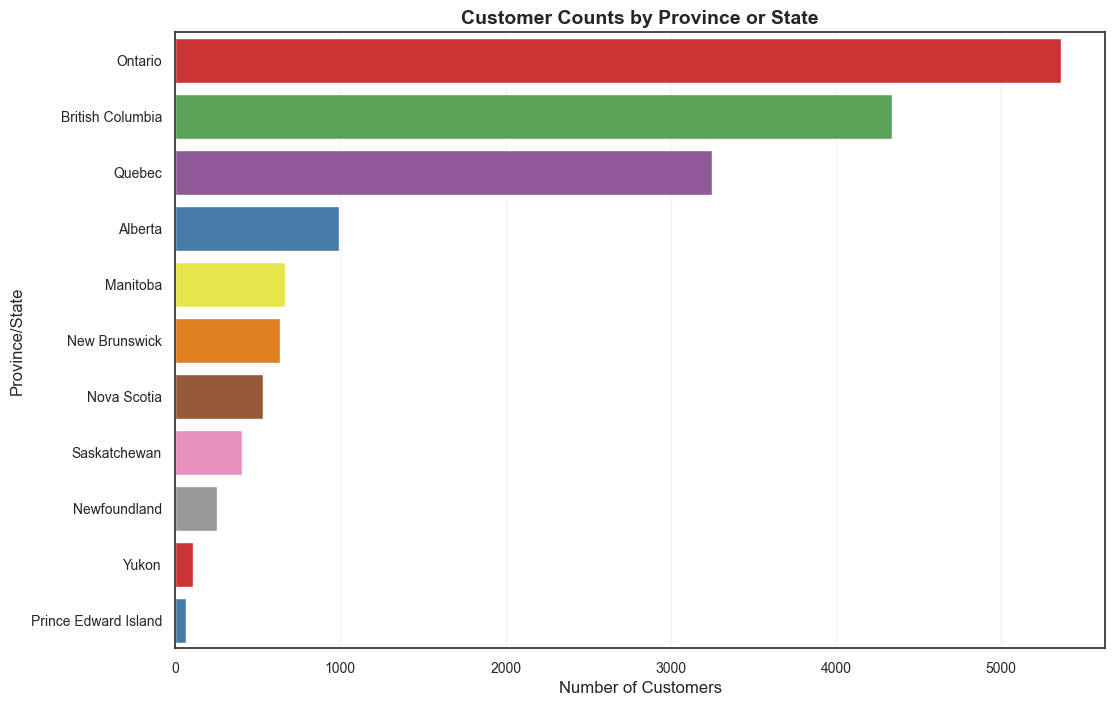

In [92]:
# Province or State by Customer Counts

plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    y='Province or State',
    order=customers['Province or State'].value_counts().index,
    palette='Set1',
    hue='Province or State',
)
plt.title('Customer Counts by Province or State')
plt.xlabel('Number of Customers')
plt.ylabel('Province/State')
plt.show()

#### Gender Distribution by Province

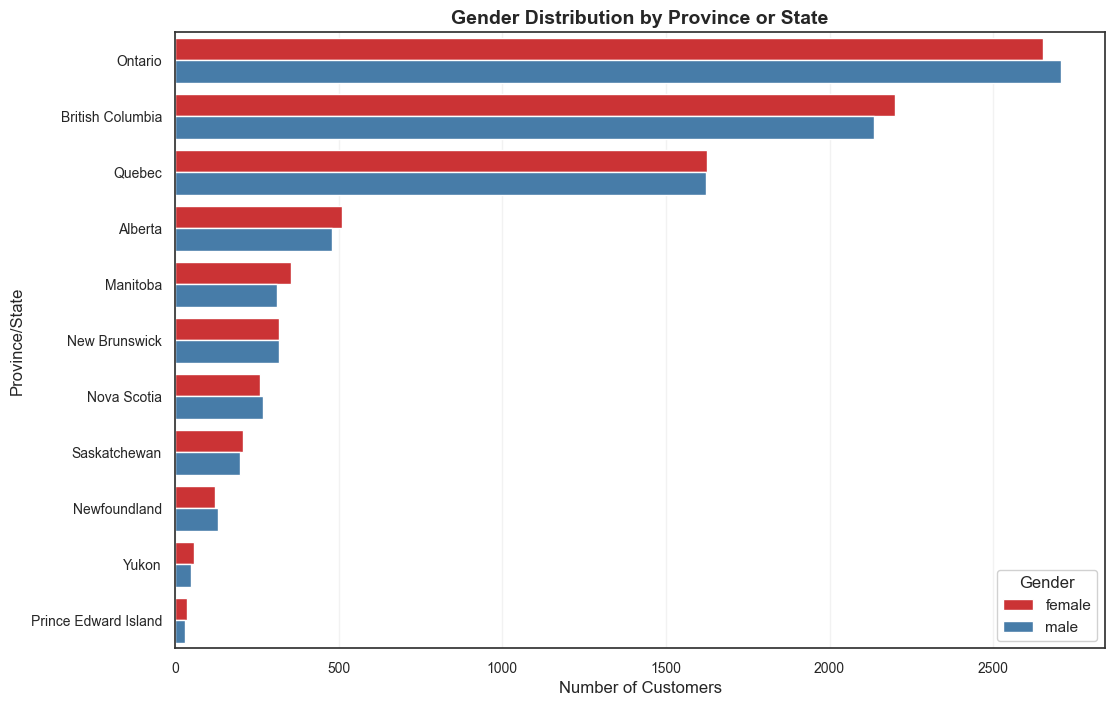

In [93]:
# Gender Distribution by Province or State

plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    y='Province or State',
    order=customers['Province or State'].value_counts().index,
    palette='Set1',
    hue='Gender',
)
plt.title('Gender Distribution by Province or State')
plt.xlabel('Number of Customers')
plt.ylabel('Province/State')
plt.legend(title='Gender')
plt.show()

#### Education by Province

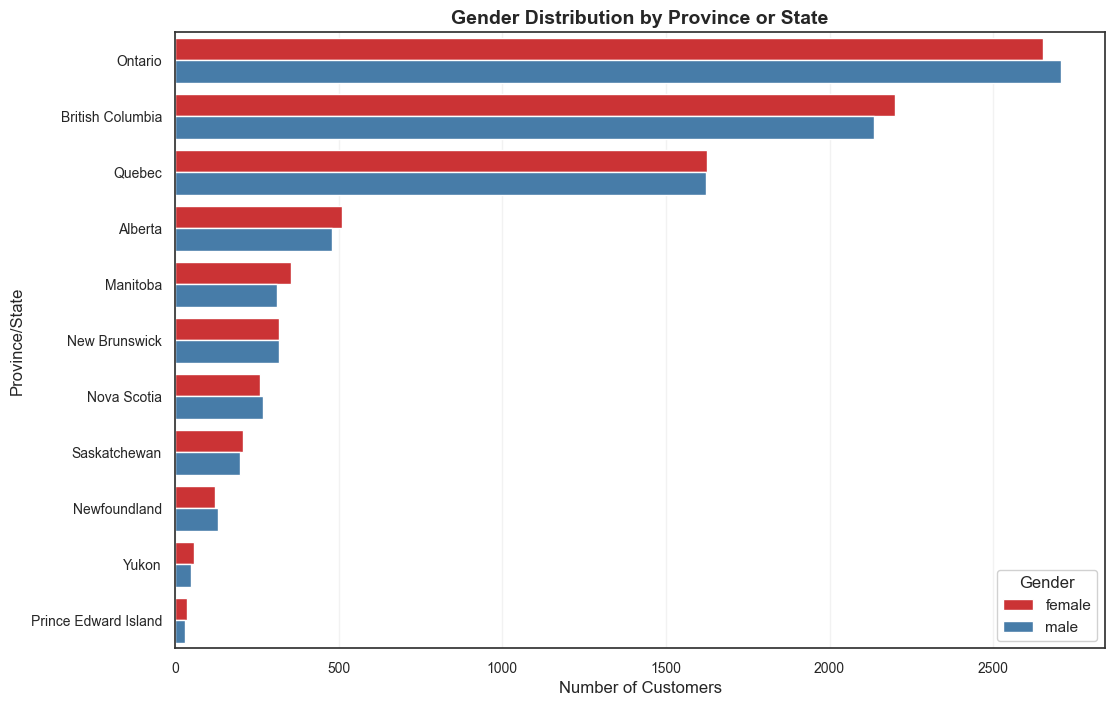

In [94]:
# Education Distribution by Province or State 

plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    y='Province or State',
    order=customers['Province or State'].value_counts().index,
    palette='Set1',
    hue='Gender',
)
plt.title('Gender Distribution by Province or State')
plt.xlabel('Number of Customers')
plt.ylabel('Province/State')
plt.legend(title='Gender')
plt.show()

#### Income (sum) by Province

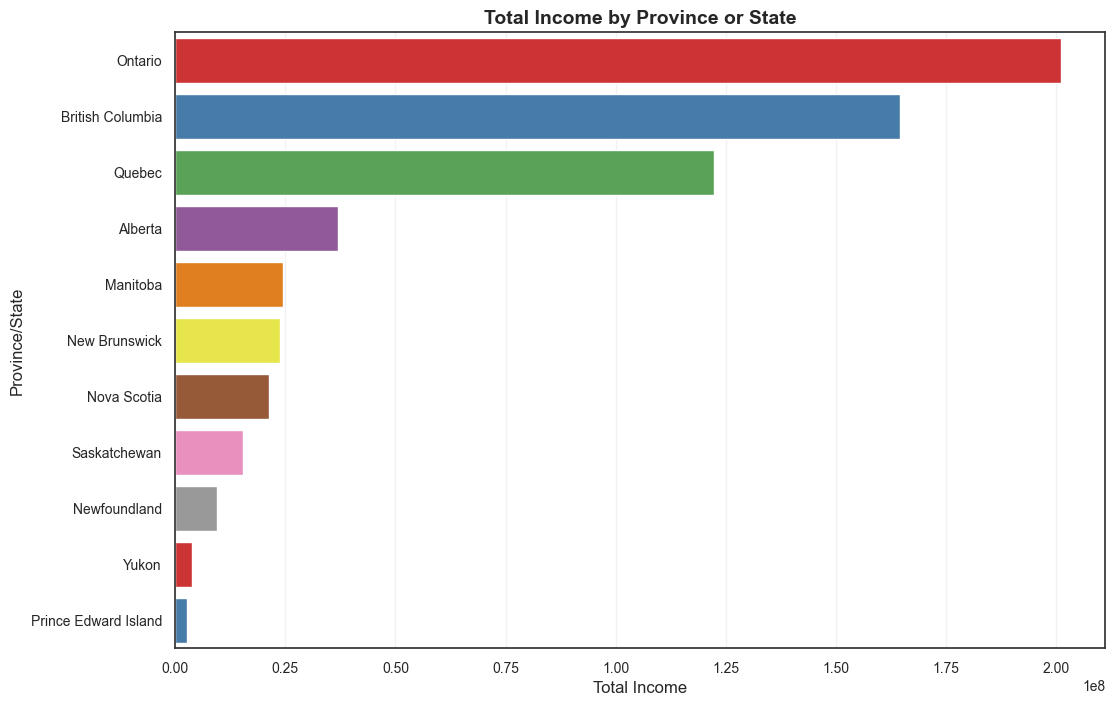

In [95]:
# Income (sum) by Province

income_by_province = customers.groupby('Province or State')['Income'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    x=income_by_province.values,
    y=income_by_province.index,
    palette='Set1',
    hue=income_by_province.index
)
plt.title('Total Income by Province or State')
plt.xlabel('Total Income')
plt.ylabel('Province/State')
plt.show()

#### Income (average) by Province

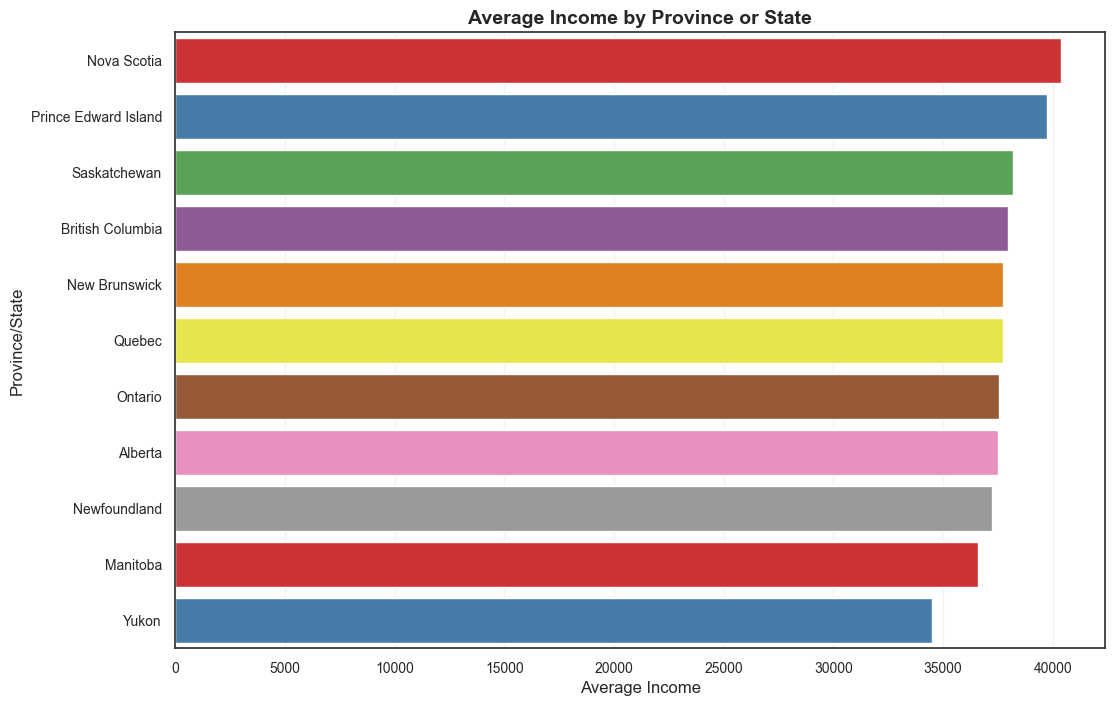

In [96]:
# Income (average) by Province

income_by_province_avg = customers.groupby('Province or State')['Income'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    x=income_by_province_avg.values,
    y=income_by_province_avg.index,
    palette='Set1',
    hue=income_by_province_avg.index
)
plt.title('Average Income by Province or State')
plt.xlabel('Average Income')
plt.ylabel('Province/State')
plt.show()  

#### Marital Status by Province

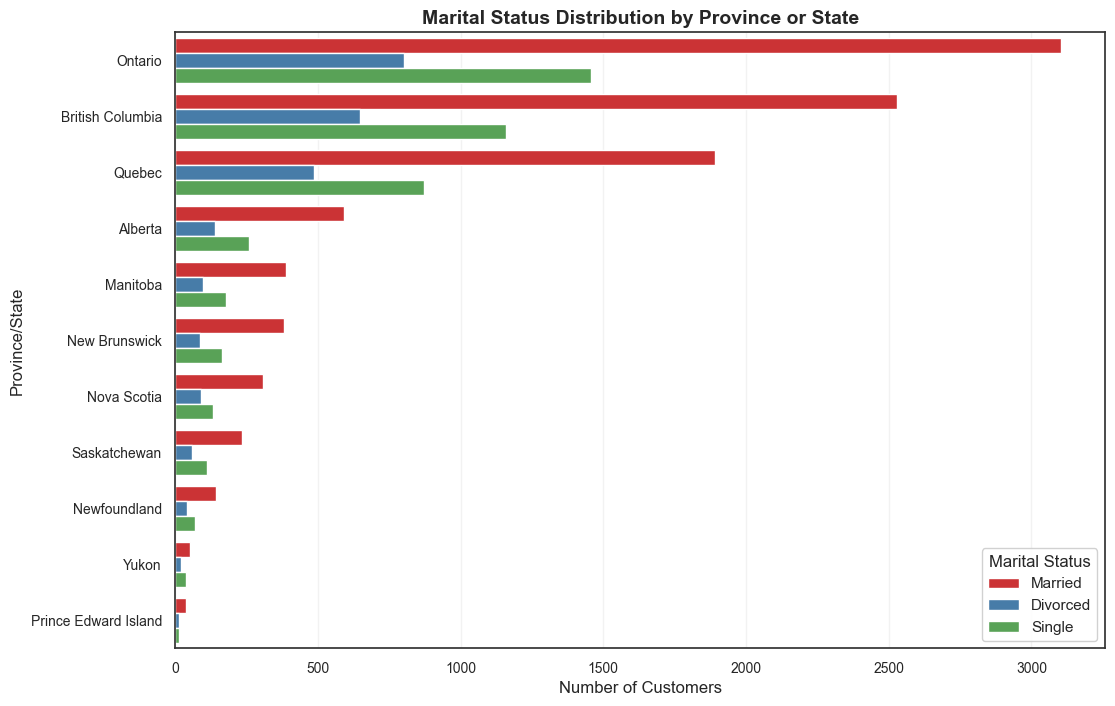

In [97]:
# Maritial Status by Province

plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    y='Province or State',
    order=customers['Province or State'].value_counts().index,
    palette='Set1',
    hue='Marital Status',
)
plt.title('Marital Status Distribution by Province or State')
plt.xlabel('Number of Customers')
plt.ylabel('Province/State')
plt.legend(title='Marital Status')
plt.show()

#### Loyalty Status by Province

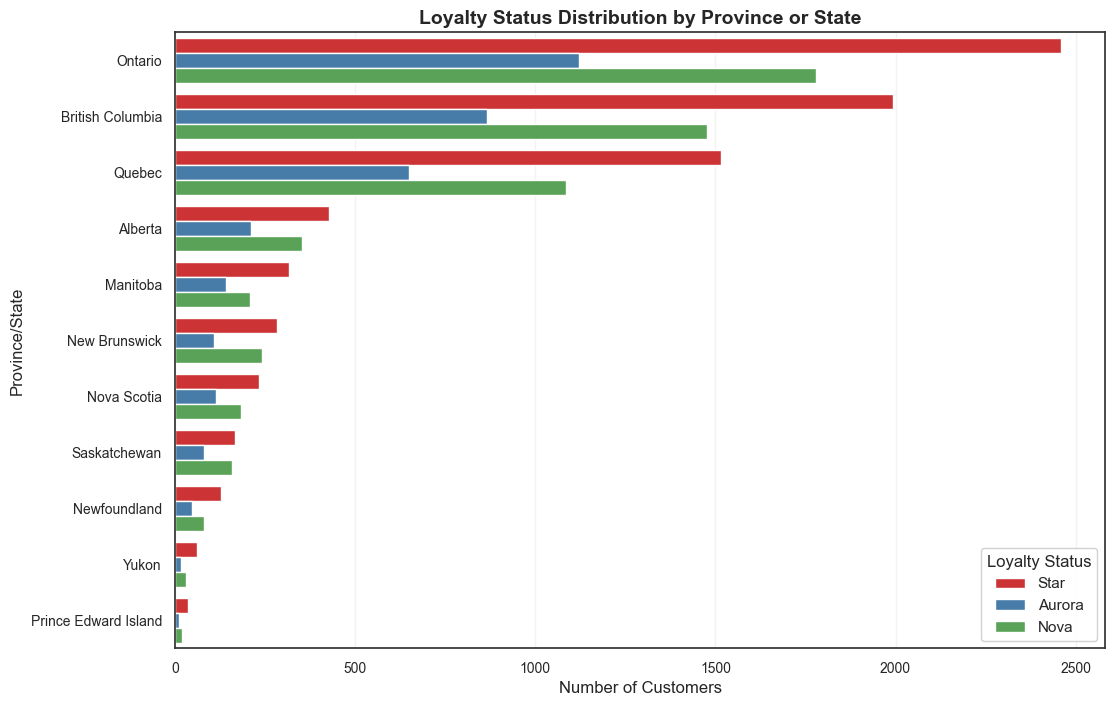

In [98]:
# Loyalty Status by Province Bar Chart

plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    y='Province or State',
    order=customers['Province or State'].value_counts().index,
    palette='Set1',
    hue='LoyaltyStatus',
)
plt.title('Loyalty Status Distribution by Province or State')
plt.xlabel('Number of Customers')
plt.ylabel('Province/State')
plt.legend(title='Loyalty Status')
plt.show()

#### Customer Lifetime Value (sum) by Province

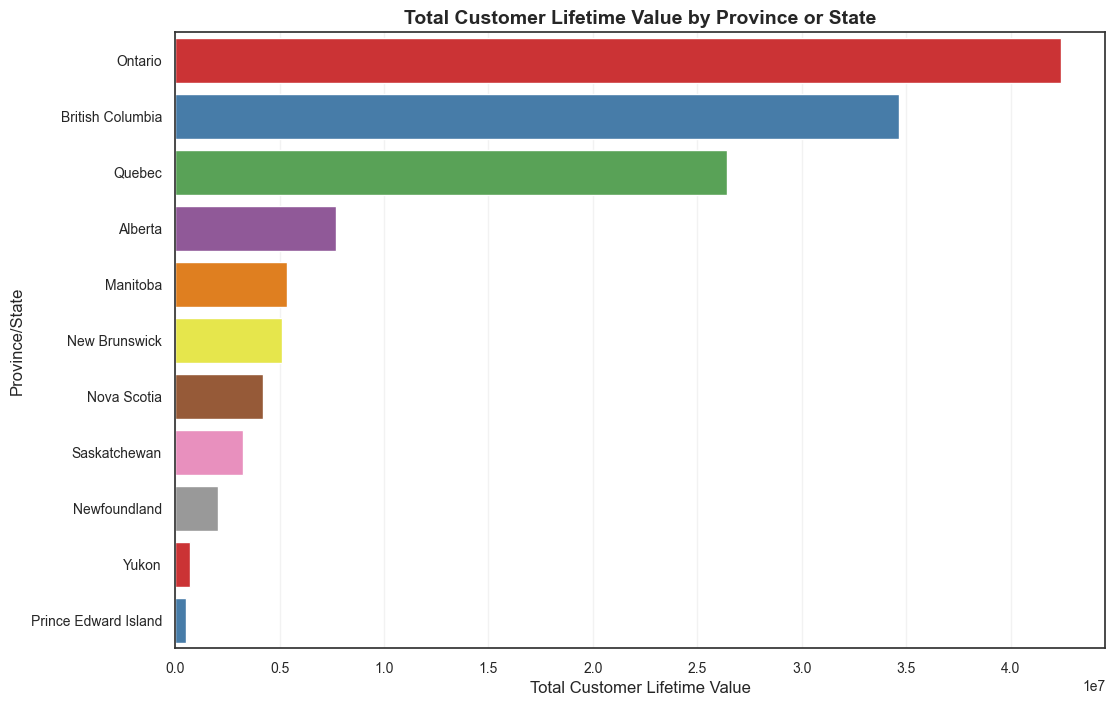

In [99]:
# Customer Lifetime Value (sum) by Province
clv_by_province = customers.groupby('Province or State')['Customer Lifetime Value'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    x=clv_by_province.values,
    y=clv_by_province.index,
    palette='Set1',
    hue=clv_by_province.index
)
plt.title('Total Customer Lifetime Value by Province or State')
plt.xlabel('Total Customer Lifetime Value')
plt.ylabel('Province/State')
plt.show()

#### Business-Ready Visualization Variant

As with previous sections, we create a **business-oriented version** of total customer lifetime value by province.


In [100]:
clv_sum = (
    customers.groupby('Province or State')['Customer Lifetime Value']
    .sum()
    .reset_index(name='TotalCLV')
    .sort_values('TotalCLV', ascending=False)
)

# Professional Business-Style Plotly Bar Chart
fig = px.bar(
    clv_sum,
    x='Province or State',
    y='TotalCLV',
    title='<b>Total Customer Lifetime Value by Province</b>',
    text_auto='.2s',
    color='TotalCLV',
    color_continuous_scale=[
        [0.0, '#e6f2ff'],   
        [0.3, '#5fbcf4'],    
        [0.5, '#3da8e8'],    
        [0.7, '#0979bd'],    
        [1.0, '#17344e']     
    ]
)

# Professional Layout Updates
fig.update_layout(
    # Title styling
    title={
        'font': {'size': 18, 'color': '#17344e', 'family': 'Arial, sans-serif'},
        'x': 0.5,
        'xanchor': 'center',
        'y': 0.95,
        'yanchor': 'top'
    },
    
    # Axis styling
    xaxis_title='<b>Province</b>',
    yaxis_title='<b>Total CLV</b>',
    xaxis={
        'title_font': {'size': 14, 'color': '#17344e', 'family': 'Arial, sans-serif'},
        'tickfont': {'size': 11, 'color': '#17344e'},
        'showgrid': False,
        'showline': True,
        'linecolor': '#CCCCCC',
        'tickangle': -45
    },
    yaxis={
        'title_font': {'size': 14, 'color': '#17344e', 'family': 'Arial, sans-serif'},
        'tickfont': {'size': 11, 'color': '#17344e'},
        'gridcolor': '#EAEAEA',
        'gridwidth': 0.5,
        'showline': True,
        'linecolor': '#CCCCCC',
        'tickformat': ',',  # Thousand separators
    },
    
    # Background and paper
    plot_bgcolor='#FAFAFA',
    paper_bgcolor='white',
    
    # Size
    height=550,
    width=950,
    
    # Margins
    margin=dict(l=80, r=80, t=100, b=80),
    
    # Colorbar styling
    coloraxis_colorbar={
        'title': '<b>CLV</b>',
        'title_font': {'size': 12, 'color': '#17344e'},
        'tickfont': {'size': 10, 'color': '#17344e'},
        'len': 0.7,
        'thickness': 15,
        'tickformat': ',',
    }
)

# Update trace for better text display
fig.update_traces(
    textfont={'size': 11, 'color': '#17344e', 'family': 'Arial, sans-serif'},
    textposition='outside',
    marker_line_color='white',
    marker_line_width=1,
    hovertemplate='<b>%{x}</b><br>Total CLV: %{y:,.0f}<extra></extra>'
)

fig.show()

#### Customer Lifetime Value (average) by Province

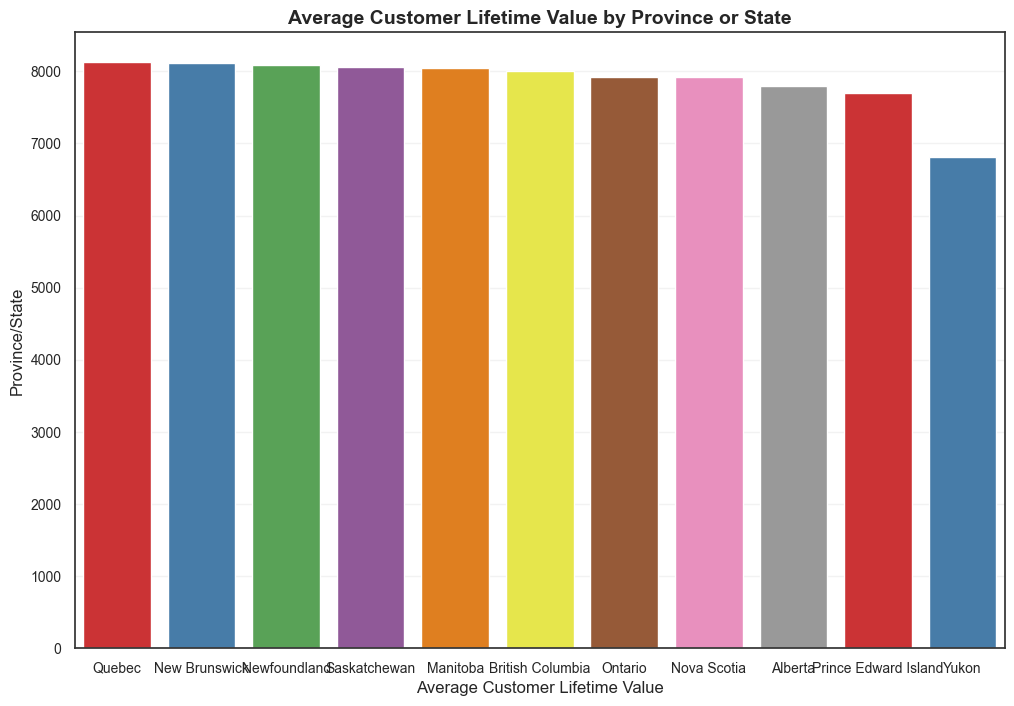

In [101]:
# Customer Lifetime Value (average) by Province (Bar Chart)

clv_by_province_avg = customers.groupby('Province or State')['Customer Lifetime Value'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    y=clv_by_province_avg.values,
    x=clv_by_province_avg.index,
    palette='Set1',
    hue=clv_by_province_avg.index
)
plt.title('Average Customer Lifetime Value by Province or State')
plt.xlabel('Average Customer Lifetime Value')
plt.ylabel('Province/State')
plt.show()


#### Customer Lifetime Value (average) by Province (Scaled Horizontal Chart)

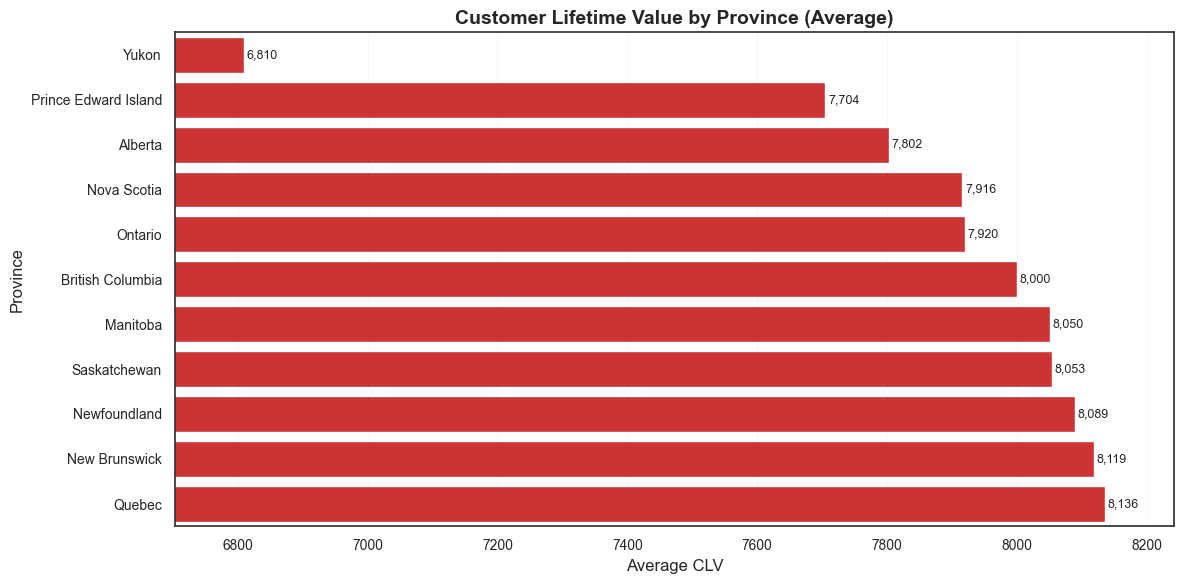

In [102]:
# --- 1) Aggregate: average CLV by province ---
prov_clv_mean = (
    customers.groupby('Province or State', dropna=False)['Customer Lifetime Value']
    .mean()
    .reset_index(name='AvgCLV')
    .dropna(subset=['AvgCLV'])
)

# Sort for horizontal plotting (small -> large, bottom to top)
prov_clv_plot = prov_clv_mean.sort_values('AvgCLV', ascending=True)

# --- 2) Axis range: don't start at 0 (zoom in) ---
min_val = prov_clv_plot['AvgCLV'].min()
max_val = prov_clv_plot['AvgCLV'].max()
pad = 0.08 * (max_val - min_val) if max_val > min_val else 0.05 * max_val
lower = max(0, min_val - pad)    # keep >= 0 for CLV (usually non-negative)
upper = max_val + pad

# --- 3) Plot ---
plt.figure(figsize=(12, max(6, 0.45 * len(prov_clv_plot))))  # auto-height if many provinces

ax = sns.barplot(
    data=prov_clv_plot,
    x='AvgCLV',
    y='Province or State',
    color=sns.color_palette("Set1")[0]  # single color for focus
)

# Value labels at bar ends (formatted with thousands separator)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}'.format, label_type='edge', padding=2, fontsize=9)

ax.set_xlim(lower, upper)
ax.set_title('Customer Lifetime Value by Province (Average)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average CLV')
ax.set_ylabel('Province')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


#### IsActive by Province

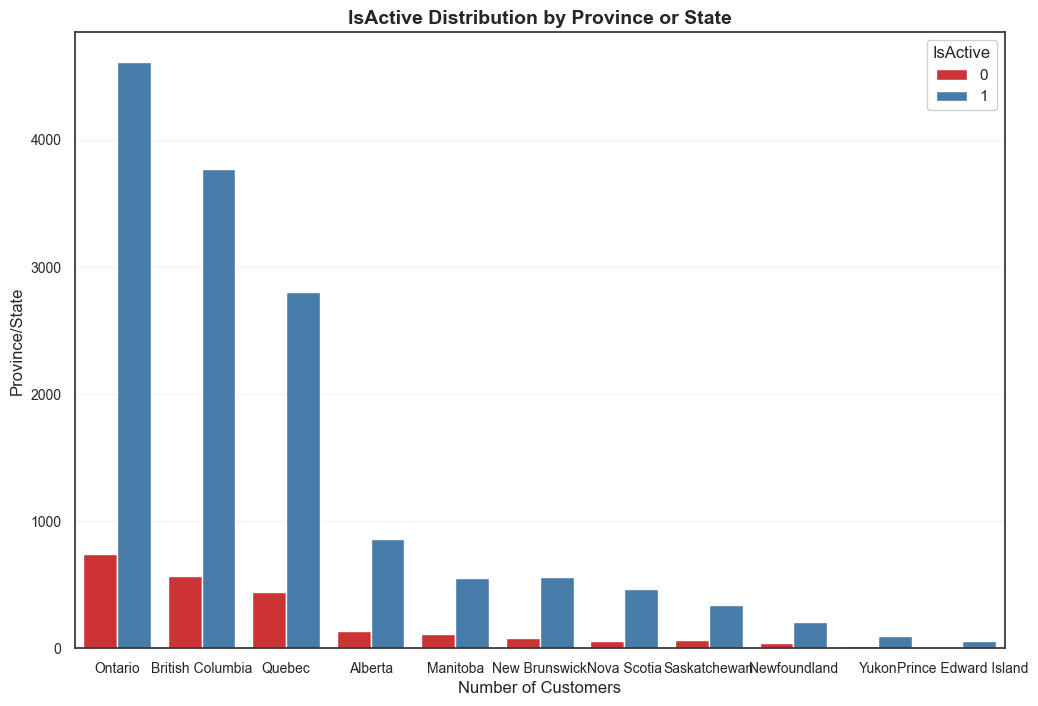

In [103]:
# IsActive distribution by Province or State

plt.figure(figsize=(12, 8))
sns.countplot(
    data=customers,
    x='Province or State',
    order=customers['Province or State'].value_counts().index,
    palette='Set1',
    hue='IsActive',
)
plt.title('IsActive Distribution by Province or State')
plt.xlabel('Number of Customers')
plt.ylabel('Province/State')
plt.legend(title='IsActive')
plt.show()

#### Total Flights by Province

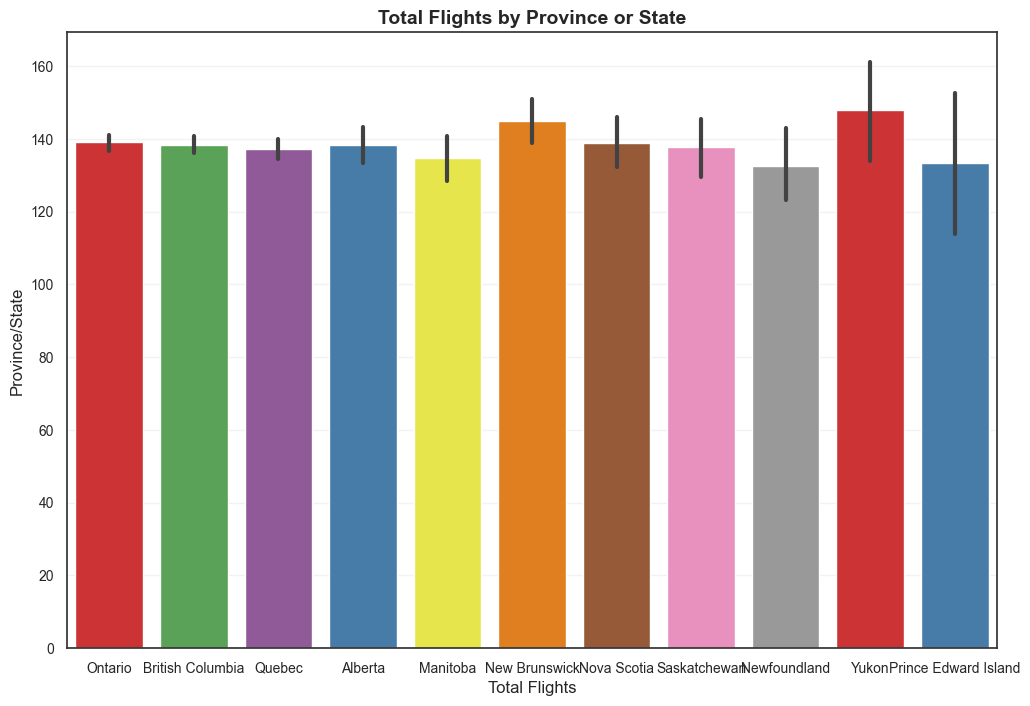

In [104]:
#Total Flights by Province

plt.figure(figsize=(12, 8))
sns.barplot(
    data=customers,
    x='Province or State',
    y='total_flights',
    order=customers['Province or State'].value_counts().index,
    palette='Set1',
    hue='Province or State',
)
plt.title('Total Flights by Province or State')
plt.xlabel('Total Flights')
plt.ylabel('Province/State')
plt.show()

#### Total Distance by Province

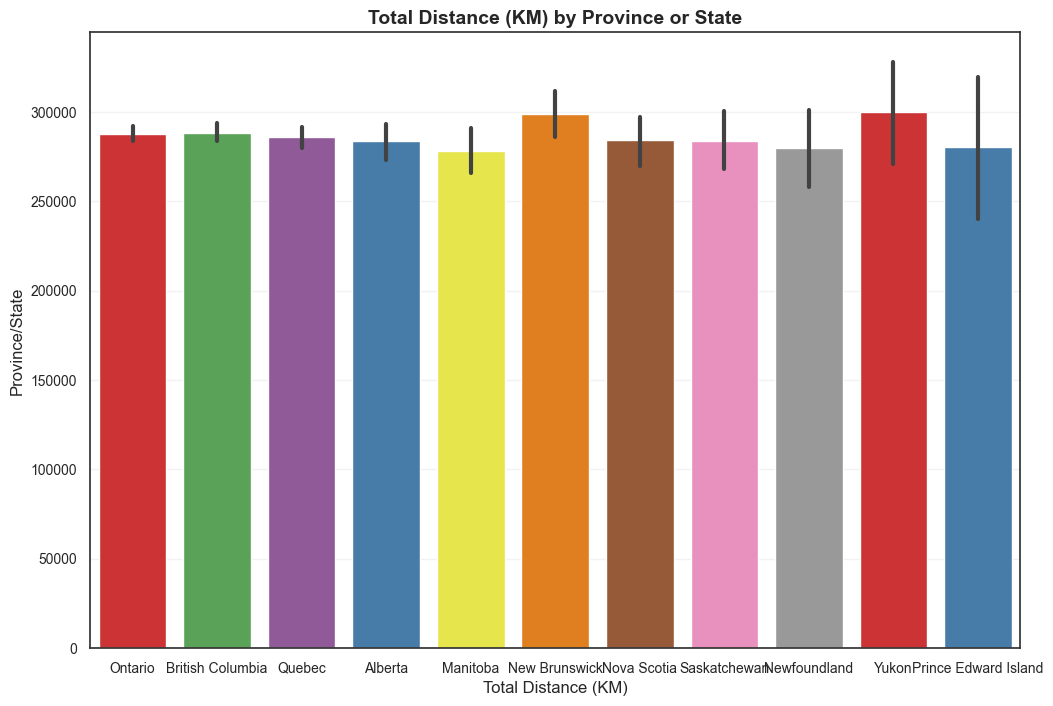

In [105]:
# TotalDistanc by Province

plt.figure(figsize=(12, 8))
sns.barplot(
    data=customers,
    x='Province or State',
    y='total_distance',
    order=customers['Province or State'].value_counts().index,
    palette='Set1',
    hue='Province or State',
)
plt.title('Total Distance (KM) by Province or State')
plt.xlabel('Total Distance (KM)')
plt.ylabel('Province/State')
plt.show()

### 5.3.2 City Analysis <a class="anchor" id="Customer Lifetime Value"></a>


#### City and Province distribution

In [106]:
# --- Build df directly from `customers` ---
df = (
    customers
    .groupby(["Province or State", "City"])
    .size()
    .rename("CustomerCount")
    .reset_index()
)

# Clean labels (optional)
df["Province or State"] = df["Province or State"].fillna("Unknown Province")
df["City"] = df["City"].fillna("Unknown City")

# --- Treemap: Province -> City ---
fig = px.treemap(
    df,
    path=["Province or State", "City"],     # hierarchy
    values="CustomerCount",
    color="CustomerCount",
    color_continuous_scale=[
        [0.0, '#e6f2ff'], [0.3, '#5fbcf4'], [0.5, '#3da8e8'], [0.7, '#0979bd'], [1.0, '#17344e']
    ],
    title="<b>Customer Distribution by Province and City</b>"
)

fig.update_traces(
    hovertemplate="<b>%{label}</b><br>Customers: %{value:,}<extra></extra>",
    marker=dict(line=dict(width=1, color="white"))
)

fig.update_layout(
    height=650, width=950,
    plot_bgcolor="#FAFAFA", paper_bgcolor="white",
    margin=dict(l=40, r=40, t=80, b=40),
    coloraxis_colorbar=dict(
        title="<b>Customer Count</b>",
        len=0.6, thickness=14,
        tickfont=dict(size=10, color="#17344e"),
        title_font=dict(size=12, color="#17344e")
    ),
    title=dict(x=0.5, xanchor="center", font=dict(size=18, color="#17344e"))
)

fig.show()


#### Income (sum) by City Top20

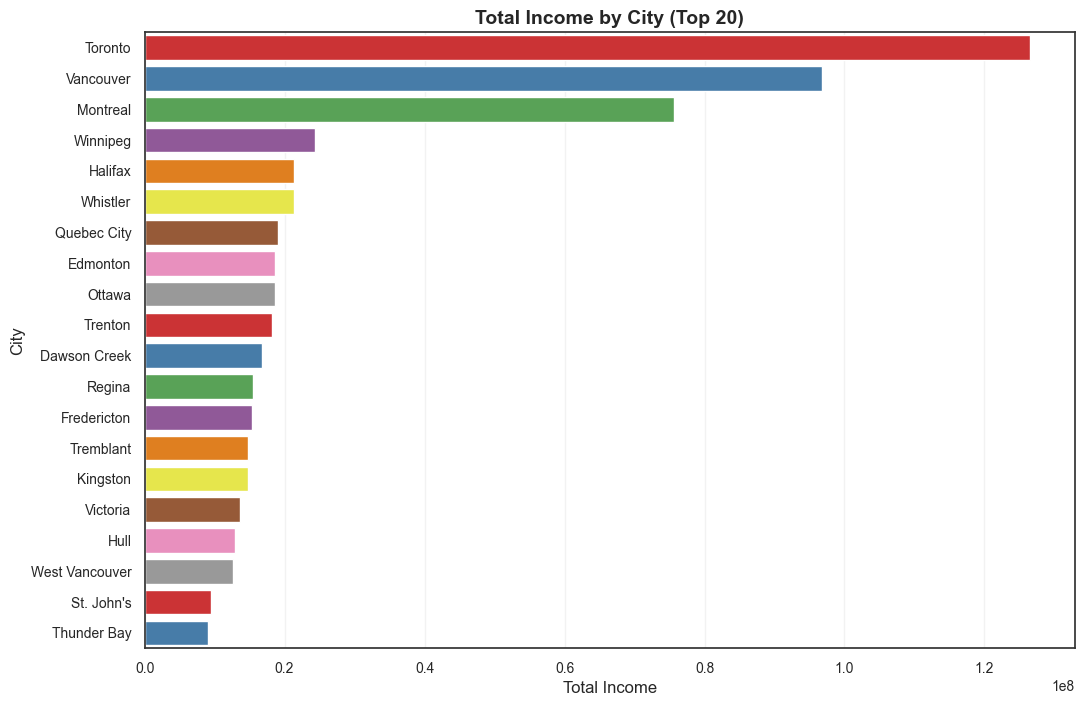

In [107]:
# Income (sum) by City Top20

income_by_city = customers.groupby('City')['Income'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    x=income_by_city.values[:20],
    y=income_by_city.index[:20],
    palette='Set1',
    hue=income_by_city.index[:20]
)
plt.title('Total Income by City (Top 20)')
plt.xlabel('Total Income')
plt.ylabel('City')
plt.show()

### Top 20 Cities by Average Income

We rank cities by their **mean income** and visualize the **top 20** using both a vertical bar chart and a horizontal bar chart.  
The **horizontal layout** is preferred here: it improves label readability for long city names and allows a **tighter (zoomed) axis range**, making smaller differences between cities more discernible.

> **Note:** Because the axis is zoomed (does not start at zero), interpret relative differences with care; the chart is intended to highlight fine-grained contrasts among the top cities.


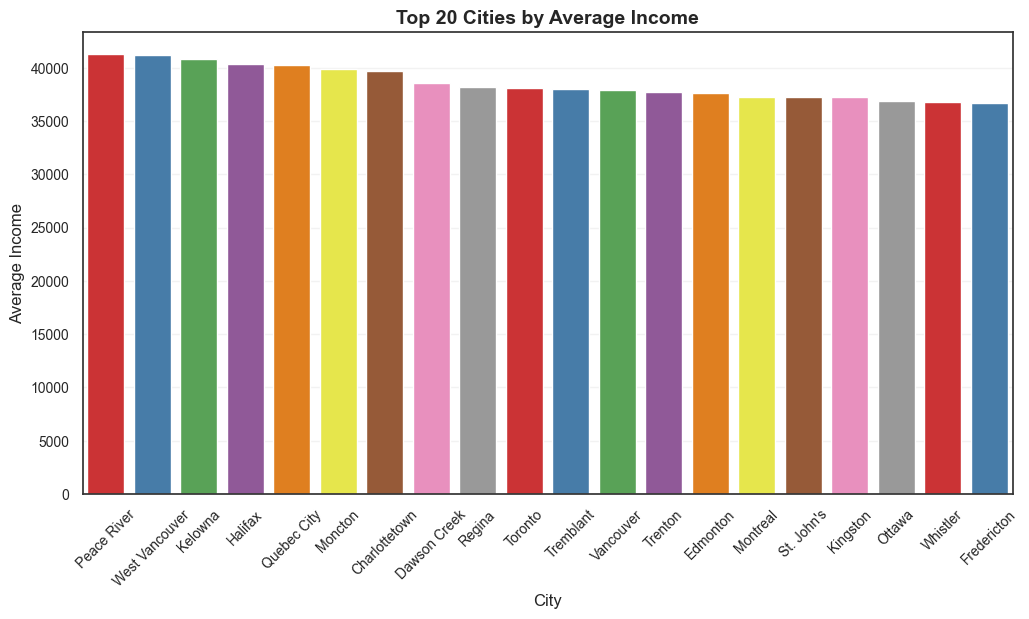

In [108]:
# Top20 Cities by Income (Average)

city_income_mean = customers.groupby('City')['Income'].mean().reset_index().sort_values(by='Income', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=city_income_mean.head(20),
    x='City', y='Income',
    order=city_income_mean['City'].head(20),
    palette='Set1', hue='City',
)
plt.title('Top 20 Cities by Average Income')
plt.xlabel('City')
plt.ylabel('Average Income')
plt.xticks(rotation=45)
plt.show()

/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_83968/2241469864.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




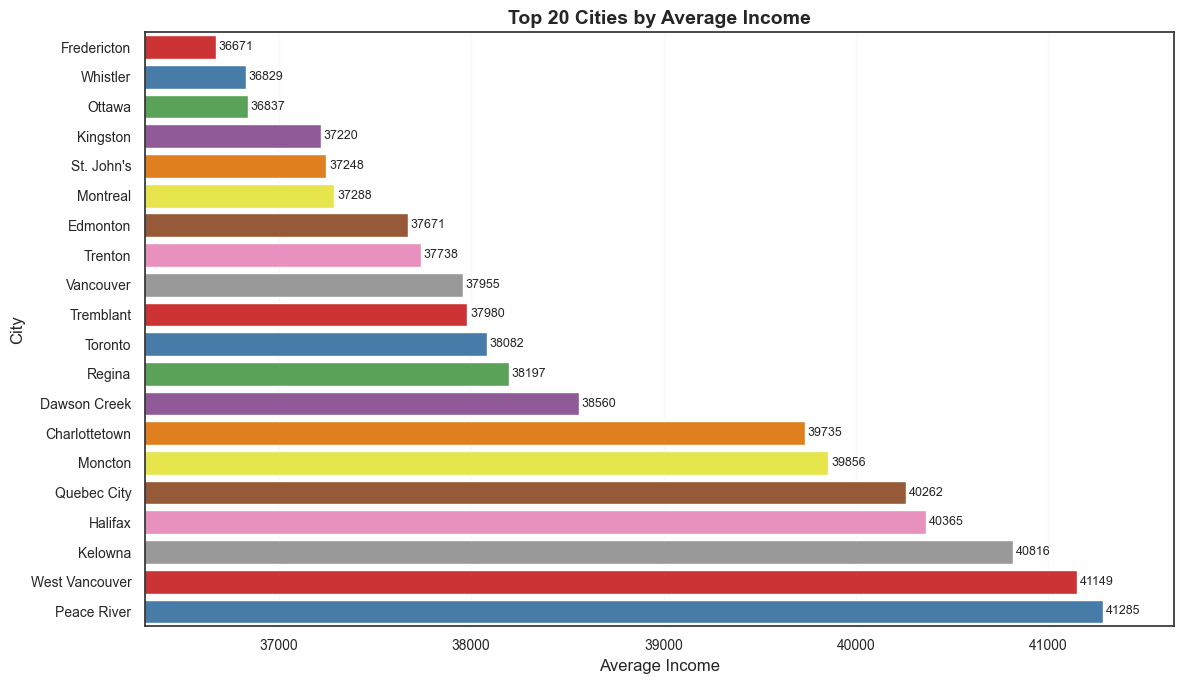

In [109]:
# --- Top 20 by average income ---
top20 = (
    customers.groupby('City', dropna=False)['Income']
    .mean()
    .reset_index()
    .dropna(subset=['Income'])
    .sort_values('Income', ascending=False)
    .head(20)
)

# Sort for horizontal display (small → large top-to-bottom)
top20_plot = top20.sort_values('Income', ascending=True)

# Axis range (don’t start at 0)
min_val = top20_plot['Income'].min()
max_val = top20_plot['Income'].max()
pad = 0.08 * (max_val - min_val) if max_val > min_val else 0.05 * max_val
lower = max(0, min_val - pad)  # keep ≥ 0 if you prefer
upper = max_val + pad

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=top20_plot,
    x='Income', y='City',
    palette='Set1'
)

# Value labels
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', label_type='edge', padding=2, fontsize=9)

ax.set_xlim(lower, upper)
ax.set_title('Top 20 Cities by Average Income', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Income')
ax.set_ylabel('City')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


#### Gender by City (Top20)

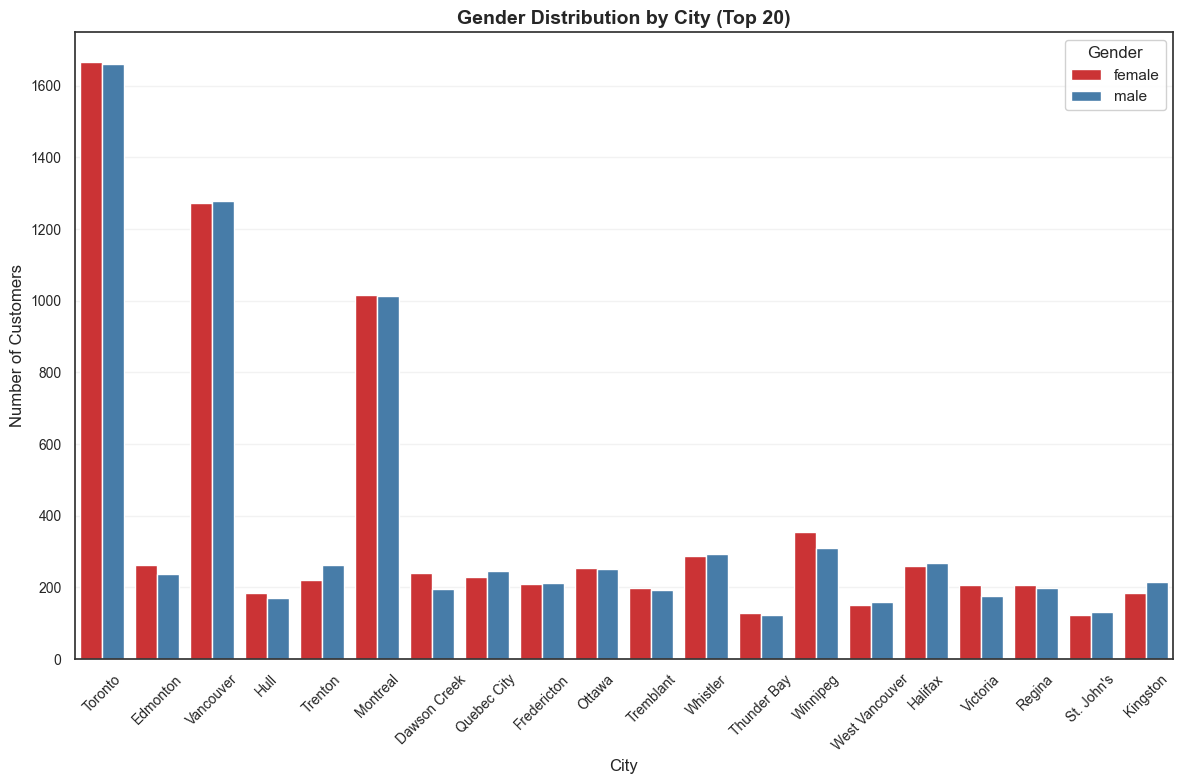

In [110]:
# Gender by City (Top 20)
plt.figure(figsize=(12, 8))
top_cities = customers['City'].value_counts().index[:20]
sns.countplot(data=customers[customers['City'].isin(top_cities)], x='City', hue='Gender', palette='Set1')
plt.title('Gender Distribution by City (Top 20)')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Customer Lifetime Value by City (Top20)

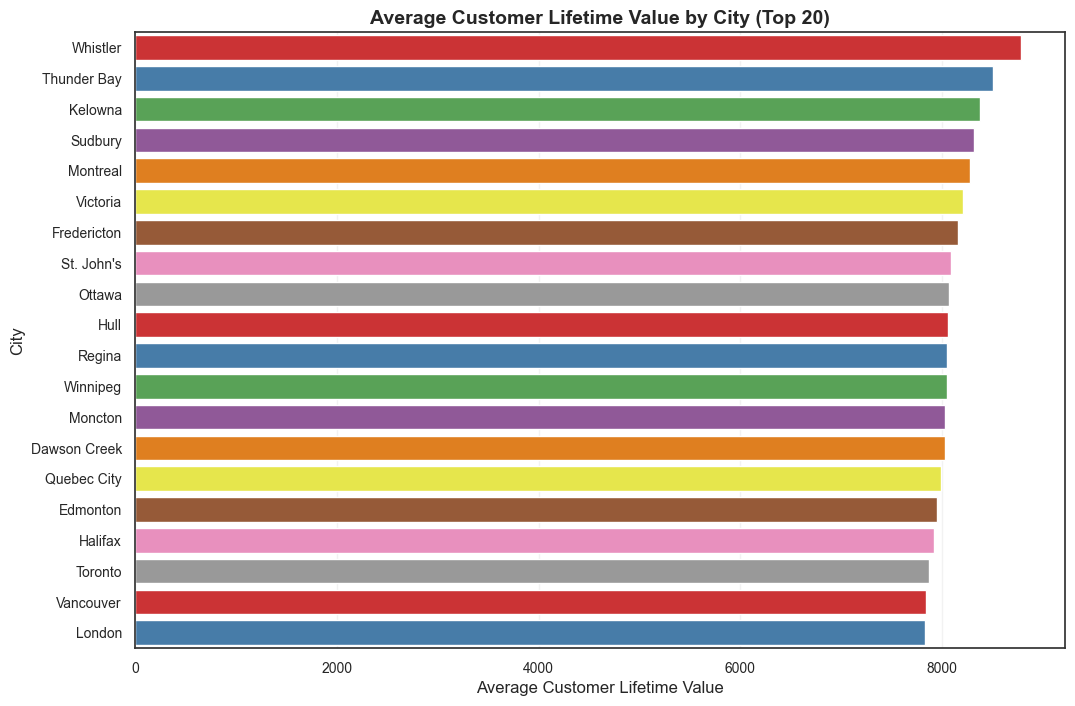

In [111]:
# Customer Lifetime Value by City (Top 20)

clv_by_city = customers.groupby('City')['Customer Lifetime Value'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    x=clv_by_city.values[:20],
    y=clv_by_city.index[:20],
    palette='Set1',
    hue=clv_by_city.index[:20]
)
plt.title('Average Customer Lifetime Value by City (Top 20)')
plt.xlabel('Average Customer Lifetime Value')
plt.ylabel('City')
plt.show()

/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_83968/338115578.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




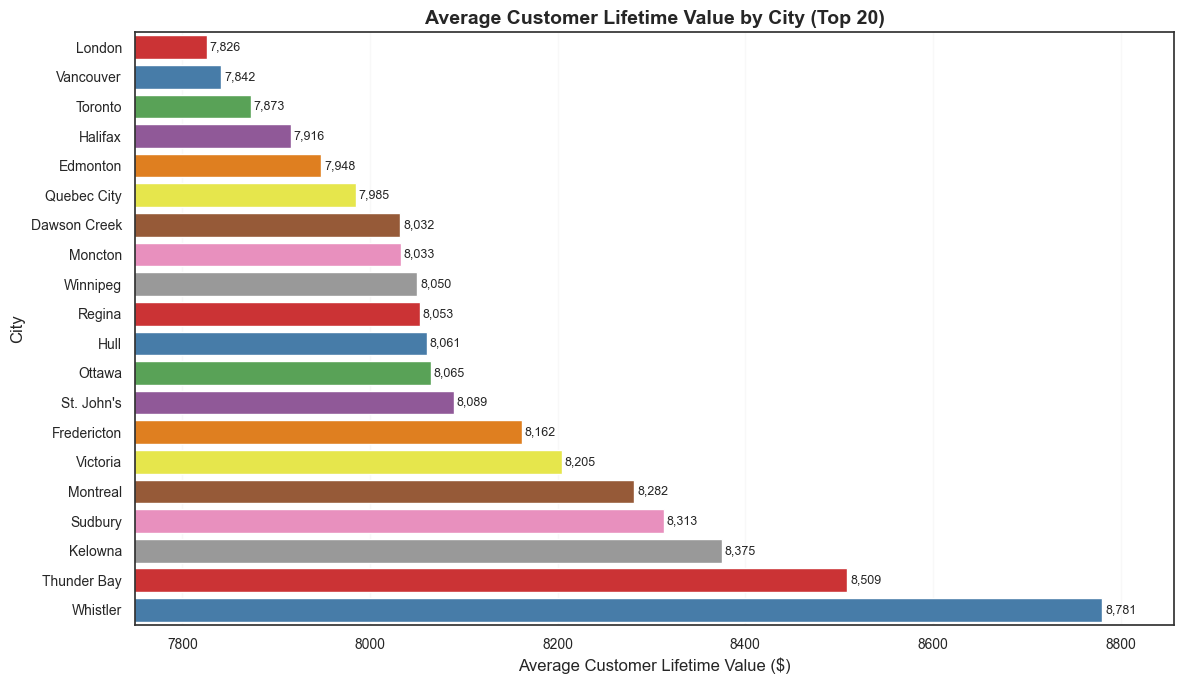

In [112]:
# Customer Lifetime Value by City (Top 20) - Scaled Y-Axis
 
# Top 20 cities by average lifetime value
top20 = (
    customers.groupby('City', dropna=False)['Customer Lifetime Value']
    .mean()
    .reset_index(name='AvgCLV')
    .dropna(subset=['AvgCLV'])
    .sort_values('AvgCLV', ascending=False)
    .head(20)
    .sort_values('AvgCLV')  # small -> large for horizontal bar order
)

# Axis range (zoom: don't start at 0)
min_val = top20['AvgCLV'].min()
max_val = top20['AvgCLV'].max()
pad = 0.08 * (max_val - min_val) if max_val > min_val else 0.05 * max_val
x_lower = max(0, min_val - pad)  # keep >= 0 for tenure
x_upper = max_val + pad

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top20,
    x='AvgCLV',
    y='City',
    palette='Set1'
)

# Optional value labels
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}'.format, label_type='edge', padding=2, fontsize=9)

ax.set_xlim(x_lower, x_upper)  # <- scaled (zoomed) X-axis
ax.set_title('Average Customer Lifetime Value by City (Top 20)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Customer Lifetime Value ($)')
ax.set_ylabel('City')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


#### Customer Tenure Days by City (Top20)

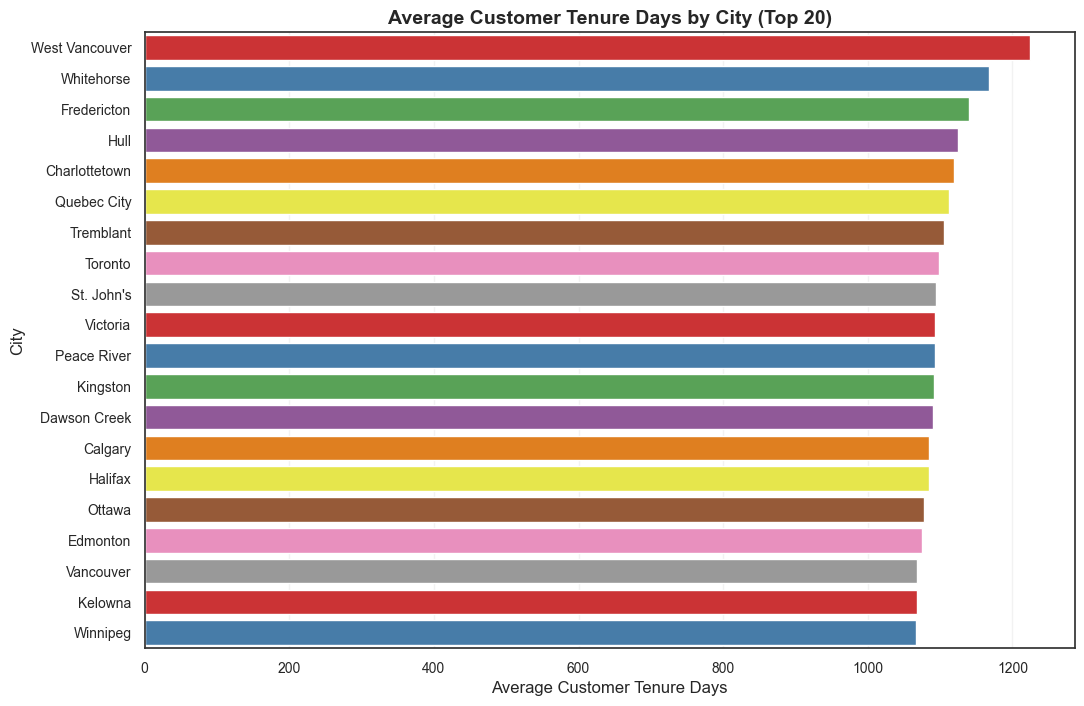

In [113]:
# Customer Tenure Days by City (Top 20)

clv_by_city = customers.groupby('City')['CustomerTenureDays'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    x=clv_by_city.values[:20],
    y=clv_by_city.index[:20], 
    palette='Set1',
    hue=clv_by_city.index[:20]
)
plt.title('Average Customer Tenure Days by City (Top 20)')
plt.xlabel('Average Customer Tenure Days')
plt.ylabel('City')
plt.show()

/var/folders/rm/jy9wcsjs6b96ktzhjj94zw5w0000gn/T/ipykernel_83968/4151511919.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




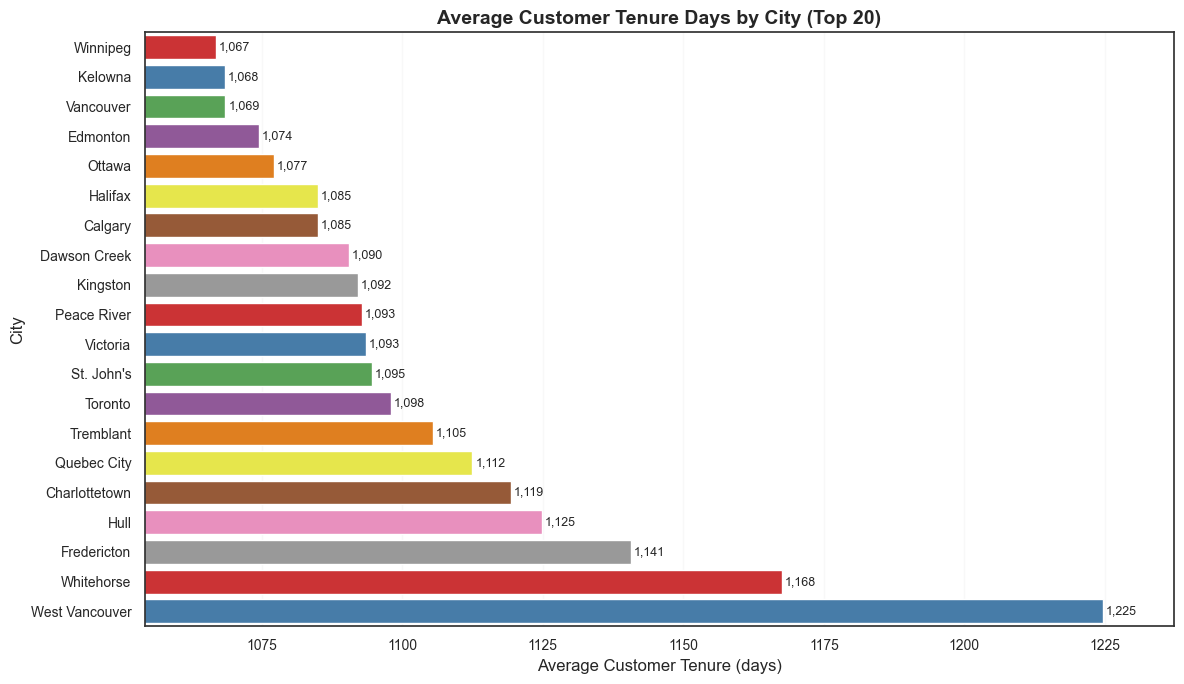

In [114]:
# Customer Tenure Days by City (Top 20) - Scaled Y-Axis

# Top 20 cities by average tenure
top20 = (
    customers.groupby('City', dropna=False)['CustomerTenureDays']
    .mean()
    .reset_index(name='AvgTenure')
    .dropna(subset=['AvgTenure'])
    .sort_values('AvgTenure', ascending=False)
    .head(20)
    .sort_values('AvgTenure')  # small -> large for horizontal bar order
)

# Axis range (zoom: don't start at 0)
min_val = top20['AvgTenure'].min()
max_val = top20['AvgTenure'].max()
pad = 0.08 * (max_val - min_val) if max_val > min_val else 0.05 * max_val
x_lower = max(0, min_val - pad)  # keep >= 0 for tenure
x_upper = max_val + pad

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top20,
    x='AvgTenure',
    y='City',
    palette='Set1'
)

# Optional value labels
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}'.format, label_type='edge', padding=2, fontsize=9)

ax.set_xlim(x_lower, x_upper)  # <- scaled (zoomed) X-axis
ax.set_title('Average Customer Tenure Days by City (Top 20)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Customer Tenure (days)')
ax.set_ylabel('City')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


#### Total Flights by city (Top20)

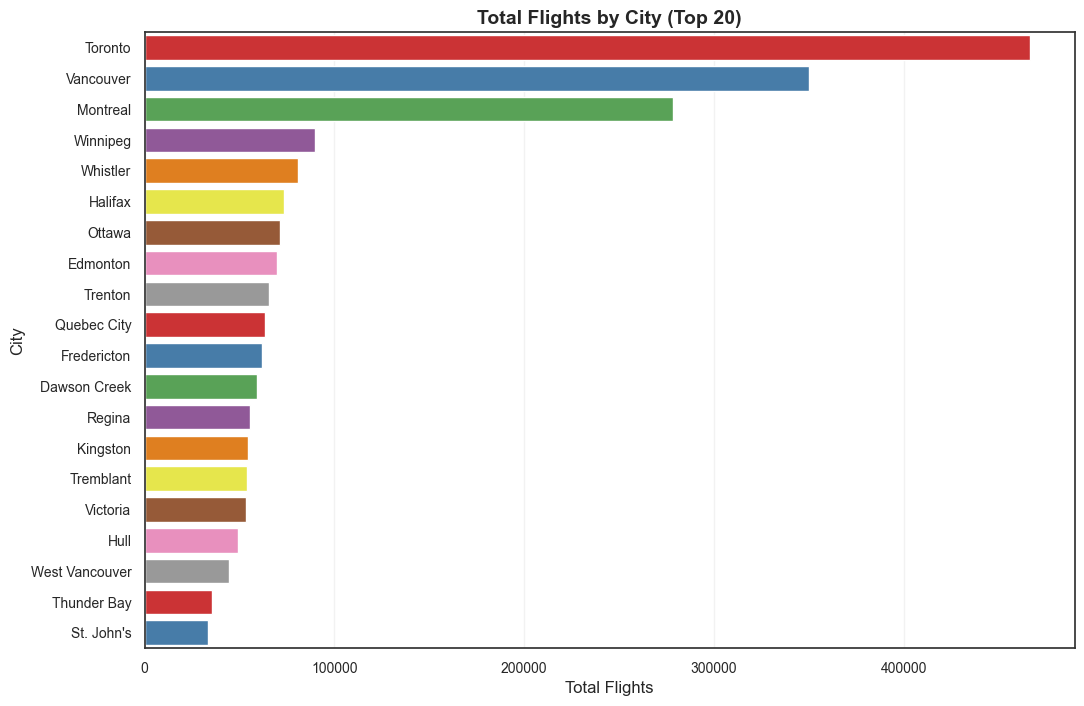

In [115]:
# Total Flights by City (Top 20)

total_flights_by_city = customers.groupby('City')['total_flights'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    x=total_flights_by_city.values[:20],
    y=total_flights_by_city.index[:20],
    palette='Set1',
    hue=total_flights_by_city.index[:20]
)
plt.title('Total Flights by City (Top 20)')
plt.xlabel('Total Flights')
plt.ylabel('City')
plt.show()

#### Total Distance by City (Top20)

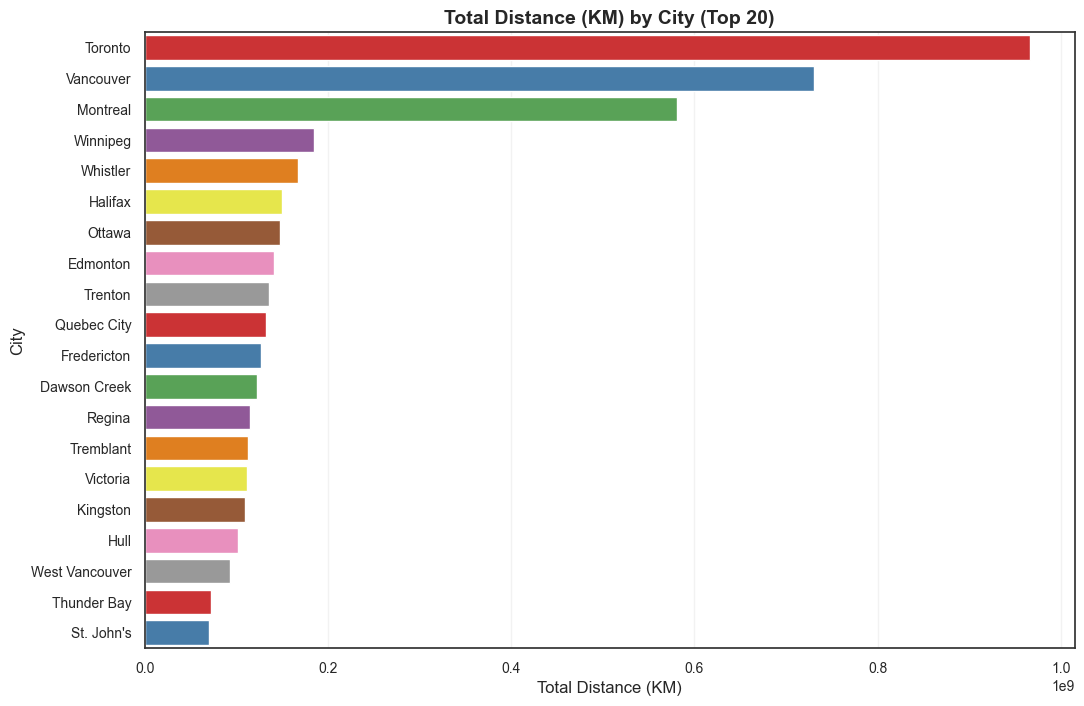

In [116]:
# Total Distance by City (Top 20)

total_distance_by_city = customers.groupby('City')['total_distance'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    x=total_distance_by_city.values[:20],
    y=total_distance_by_city.index[:20],
    palette='Set1',
    hue=total_distance_by_city.index[:20]
)
plt.title('Total Distance (KM) by City (Top 20)')
plt.xlabel('Total Distance (KM)')
plt.ylabel('City')
plt.show()

### Geographic Distribution of Customers

To understand the **spatial distribution** of our customer base across Canada, we plot customer locations using their **latitude** and **longitude**. Each marker represents one or more customers, enabling us to visualize **concentrations** and **regional patterns**.

Marker **size** reflects the number of customers at (or aggregated near) a given location, highlighting areas of **higher density** and potential **market opportunities**.


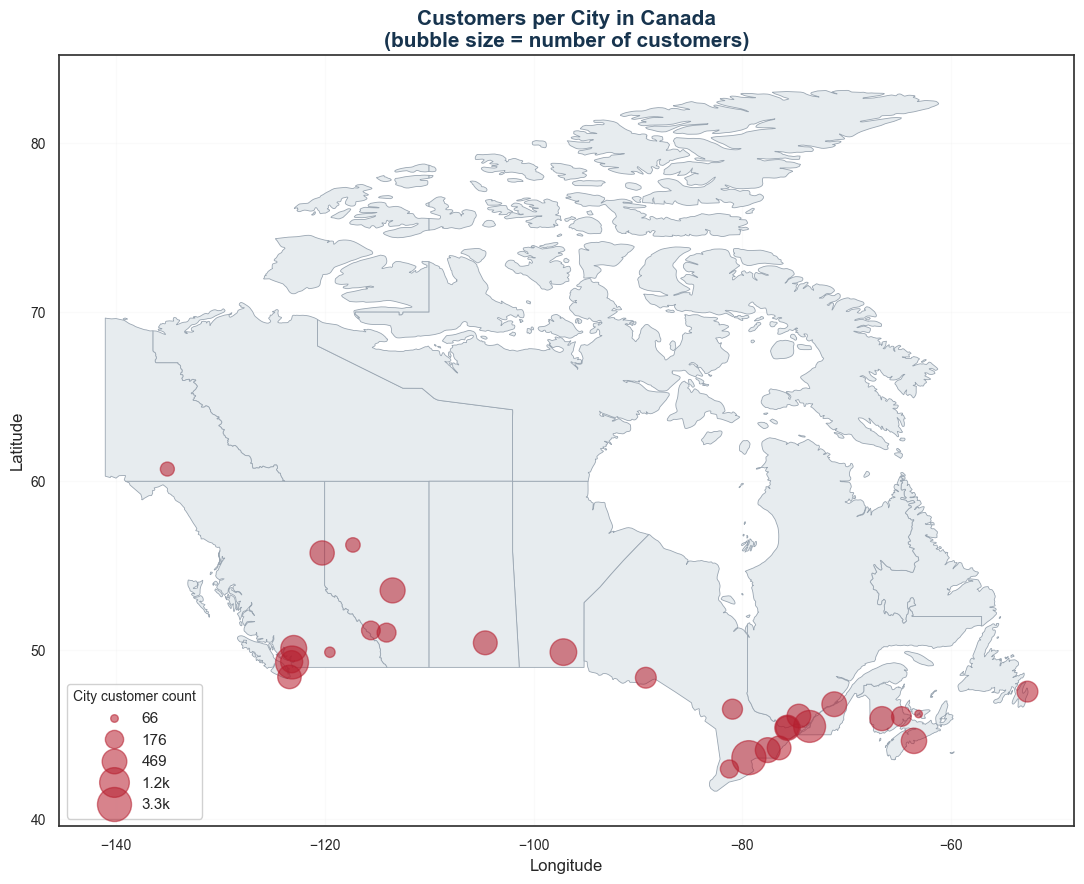

In [117]:
# =========================
# Config
# =========================
AREA_MIN, AREA_MAX = 30, 600      # bubble areas in points^2
N_LEGEND_TICKS     = 5            # how many bubbles to show in legend
LOG_THRESHOLD      = 50           # if max/min > 50 -> use log-spaced legend ticks
PALETTE_COLOR      = "#B61E2E"

def compact_fmt(x: float) -> str:
    """Format numbers like 1.2k, 4.0k, 2.3M."""
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    if x >= 1_000:
        return f"{x/1_000:.1f}k"
    return f"{int(x)}"

def scale_sizes(values, vmin, vmax, area_min=AREA_MIN, area_max=AREA_MAX, mode="linear"):
    """Map values -> bubble area (pt^2). If mode='log', scale on log10 domain."""
    values = np.asarray(values, dtype=float)
    if vmin == vmax:  # constant data
        return np.full_like(values, (area_min + area_max)/2.0, dtype=float)

    if mode == "log":
        # guard against zeros: shift by smallest positive
        shift = max(min(values[values > 0]) * 0.5, 1e-9) if np.any(values > 0) else 1.0
        vals = np.log10(np.clip(values, shift, None))
        vmin, vmax = np.log10(max(shift, vmin)), np.log10(max(shift, vmax))
        return np.interp(vals, (vmin, vmax), (area_min, area_max))

    # linear
    return np.interp(values, (vmin, vmax), (area_min, area_max))

def legend_ticks(values, n=N_LEGEND_TICKS, use_log=False):
    """Choose n representative tick values across the data range."""
    values = np.asarray(values, dtype=float)
    vmin, vmax = float(np.min(values)), float(np.max(values))
    if vmin <= 0:  # avoid zero for log spacing
        vmin = max(vmin, 1.0)

    if use_log:
        ticks = np.geomspace(vmin, vmax, n)
    else:
        qs = np.linspace(0, 1, n)
        ticks = np.quantile(values, qs)
    # ensure uniqueness & monotonic
    ticks = np.unique(np.round(ticks, 0))
    # if too few (e.g., tiny dataset), pad linearly
    if ticks.size < n:
        ticks = np.linspace(vmin, vmax, n)
    return ticks

# -----------------------------
# 1) Prepare data
# -----------------------------
df = customers.copy()
df["Latitude"]  = pd.to_numeric(df["Latitude"],  errors="coerce")
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
df = df.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)

city_agg = (
    df.groupby(["Province or State", "City"], dropna=False)
      .agg(CustomerCount=("City", "size"),
           Latitude=("Latitude", "mean"),
           Longitude=("Longitude", "mean"))
      .reset_index()
)

# -----------------------------
# 2) Base map (Canada provinces)
# -----------------------------
admin1_url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
admin1 = gpd.read_file(admin1_url).to_crs("EPSG:4326")
canada_admin1 = admin1.loc[admin1["admin"] == "Canada", ["name", "geometry"]].copy()

# -----------------------------
# 3) GeoDataFrame for bubbles
# -----------------------------
cities_gdf = gpd.GeoDataFrame(
    city_agg,
    geometry=gpd.points_from_xy(city_agg["Longitude"], city_agg["Latitude"]),
    crs="EPSG:4326"
)

counts = cities_gdf["CustomerCount"].astype(float).values
if counts.size == 0:
    fig, ax = plt.subplots(figsize=(12, 9))
    canada_admin1.plot(ax=ax, color="#E7ECEF", edgecolor="#9AA6B2", linewidth=0.6)
    ax.text(0.5, 0.5, "No location data available", transform=ax.transAxes,
            ha="center", va="center", fontsize=12, color="#555")
    plt.show()
else:
    cmin, cmax = np.min(counts), np.max(counts)
    # Decide legend scaling mode automatically
    use_log = (cmax / max(cmin, 1)) > LOG_THRESHOLD

    # Map counts -> bubble areas
    areas = scale_sizes(counts, cmin, cmax, AREA_MIN, AREA_MAX, mode="log" if use_log else "linear")

    # -----------------------------
    # 4) Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(12, 9))
    fig.patch.set_facecolor("white")

    canada_admin1.plot(ax=ax, color="#E7ECEF", edgecolor="#9AA6B2", linewidth=0.6)

    cities_gdf.plot(
        ax=ax,
        markersize=areas,          # area in pt^2
        color=PALETTE_COLOR,
        alpha=0.55
    )

    ax.set_title(
        "Customers per City in Canada\n(bubble size = number of customers)",
        fontsize=15, fontweight="bold", color="#17344e"
    )
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.grid(alpha=0.2)

    # -----------------------------
    # 5) Adaptive legend (N_LEGEND_TICKS bubbles)
    # -----------------------------
    ticks = legend_ticks(counts, n=N_LEGEND_TICKS, use_log=use_log)
    tick_areas = scale_sizes(ticks, cmin, cmax, AREA_MIN, AREA_MAX, mode="log" if use_log else "linear")

    handles = [
        Line2D([0], [0],
               marker='o', linestyle='',
               markersize=np.sqrt(a),         # convert area -> marker size (pt)
               markerfacecolor=PALETTE_COLOR, markeredgecolor=PALETTE_COLOR, alpha=0.55)
        for a in tick_areas
    ]
    labels = [compact_fmt(float(t)) for t in ticks]

    lgd = ax.legend(handles, labels, title="City customer count", frameon=True, loc="lower left")
    plt.setp(lgd.get_title(), fontsize=10)

    plt.tight_layout()
    plt.show()
